In [1]:
# ============================================================
# START TOTAL NOTEBOOK TIMER
# ============================================================

import time

NOTEBOOK_START_TIME = time.perf_counter()

print("Notebook execution timer started.")

# ============================================================
# CELL 1 — RUNTIME CHECK
# ============================================================

import sys

print("Python version:")
print(sys.version)

if sys.version_info[:2] != (3, 12):
    raise RuntimeError(
        "\nThis notebook requires Python 3.12.\n\n"
        "In Google Colab, change to a Python 3.12 runtime "
        "BEFORE continuing.\n\n"
        "Do NOT run this notebook with Python 3.13."
    )

print("\n✓ Correct Python runtime detected: Python 3.12")

Notebook execution timer started.
Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

✓ Correct Python runtime detected: Python 3.12


In [2]:
# ============================================================
# CELL 2 — LOAD S4 SLICER REPOSITORY
# ============================================================

from pathlib import Path

if not Path("input_models").exists():

    if not Path("S4_Slicer").exists():
        print("Cloning S4_Slicer...")
        !git clone https://github.com/Joshua-Nti/S4_Slicer
    else:
        print("S4_Slicer repository already cloned.")

    print("Copying S4_Slicer files into working directory...")
    !cp -r S4_Slicer/* ./

else:
    print("✓ S4_Slicer files already available.")

print("✓ Repository setup complete.")

Cloning S4_Slicer...
Cloning into 'S4_Slicer'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 290 (delta 99), reused 72 (delta 72), pack-reused 153 (from 2)
Receiving objects: 100% (290/290), 52.40 MiB | 10.42 MiB/s, done.
Resolving deltas: 100% (136/136), done.
Copying S4_Slicer files into working directory...
✓ Repository setup complete.


In [3]:
# ============================================================
# CELL 3 — INSTALL PINNED DEPENDENCIES
# Tested with Google Colab Python 3.12
# ============================================================

# Core numerical / graph packages
%pip install -q "numpy==2.0.2"
%pip install -q "scipy==1.16.3"
%pip install -q "networkx==3.6.1"

# Geometry packages
%pip install -q "tetgen==0.8.4"
%pip install -q "pyvista==0.48.4"

# G-code dependencies
%pip install -q euclid3 six

# pygcode declares an obsolete standalone argparse dependency.
# Python already includes argparse, so install without dependencies.
%pip install -q "pygcode==0.2.1" --no-deps

# Linux / headless-rendering dependencies
!apt-get update -qq
!apt-get install -y -qq xvfb libgl1 libglib2.0-0

print()
print("✓ All required dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 23.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 2.4 MB/s eta 0:00:00
W: An error occurred during the signature verification. The repository is not updated and the previous index files will be used. GPG error: https://cli.github.com/packages stable InRelease: The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 5612B36462313325
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry 

In [4]:
# # ============================================================
# # CELL 4 — ENVIRONMENT VERIFICATION
# # ============================================================

# import sys
# import IPython
# import numpy as np
# import scipy
# import networkx as nx
# import tetgen
# import pyvista as pv
# import pygcode


# print("=" * 65)
# print("S4 SLICER ENVIRONMENT")
# print("=" * 65)

# print("Python   :", sys.version.split()[0])
# print("IPython  :", IPython.__version__)
# print("NumPy    :", np.__version__)
# print("SciPy    :", scipy.__version__)
# print("NetworkX :", nx.__version__)
# print("TetGen   :", tetgen.__version__)
# print("PyVista  :", pv.__version__)
# print("pygcode  : imported successfully")


# # ============================================================
# # CRITICAL VERSION CHECKS
# # ============================================================

# assert sys.version_info[:2] == (3, 12), (
#     f"Python must be 3.12, but current version is "
#     f"{sys.version.split()[0]}"
# )

# assert pv.__version__ == "0.48.4", (
#     f"Expected PyVista 0.48.4, got {pv.__version__}"
# )


# # ============================================================
# # OPTIONAL INFORMATION
# # ============================================================

# # Open3D is intentionally NOT required.
# #
# # The revised pipeline uses PyVista to load and preprocess
# # the STL directly:
# #
# #     surface_mesh = pv.read(model_path)
# #
# # Therefore the S4 pipeline can run without Open3D.


# print()
# print("=" * 65)
# print("✓ ENVIRONMENT VERIFIED — SAFE TO RUN S4")
# print("=" * 65)

# ============================================================
# CELL 4 — ENVIRONMENT VERIFICATION
# ============================================================

import sys
import IPython
import numpy as np
import scipy
import networkx as nx
import tetgen
import pyvista as pv
import pygcode


print("=" * 65)
print("S4 SLICER ENVIRONMENT")
print("=" * 65)

print("Python   :", sys.version.split()[0])
print("IPython  :", IPython.__version__)
print("NumPy    :", np.__version__)
print("SciPy    :", scipy.__version__)
print("NetworkX :", nx.__version__)
print("TetGen   :", tetgen.__version__)
print("PyVista  :", pv.__version__)
print("pygcode  : imported successfully")


# ============================================================
# CRITICAL CHECKS
# ============================================================

assert sys.version_info[:2] == (3, 12), (
    f"Python must be 3.12; current version is "
    f"{sys.version.split()[0]}"
)

assert np.__version__ == "2.0.2", (
    f"Expected NumPy 2.0.2, got {np.__version__}"
)

assert scipy.__version__ == "1.16.3", (
    f"Expected SciPy 1.16.3, got {scipy.__version__}"
)

assert nx.__version__ == "3.6.1", (
    f"Expected NetworkX 3.6.1, got {nx.__version__}"
)

assert tetgen.__version__ == "0.8.4", (
    f"Expected TetGen 0.8.4, got {tetgen.__version__}"
)

assert pv.__version__ == "0.48.4", (
    f"Expected PyVista 0.48.4, got {pv.__version__}"
)


print()
print("=" * 65)
print("✓ ENVIRONMENT VERIFIED — SAFE TO RUN S4")
print("=" * 65)

S4 SLICER ENVIRONMENT
Python   : 3.12.13
IPython  : 7.34.0
NumPy    : 2.0.2
SciPy    : 1.16.3
NetworkX : 3.6.1
TetGen   : 0.8.4
PyVista  : 0.48.4
pygcode  : imported successfully

✓ ENVIRONMENT VERIFIED — SAFE TO RUN S4


In [5]:
# ============================================================
# COMPLETE DROP-IN:
# MESH LOADING + TETRAHEDRALIZATION + S4 PREPROCESSING
#
# Expected environment:
#   Python   3.12
#   PyVista  0.48.4
#   TetGen   0.8.4
#   Open3D   0.19.0
#
# This cell creates:
#   input_tet
#   cell_neighbour_dict
#   cell_neighbour_graph
#   bottom_cells_mask
#   bottom_cells
#   bottom_cell_groups
#   undeformed_tet
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

import networkx as nx
import numpy as np
import pyvista as pv
import tetgen

from scipy.optimize import minimize, least_squares
from scipy.spatial.transform import Rotation as R

import time
import pickle
import base64


# ============================================================
# PYVISTA NOTEBOOK SETTINGS
# ============================================================

# Static backend is appropriate for Google Colab.
# Do NOT use pv.start_xvfb() here.
pv.set_jupyter_backend("static")
pv.global_theme.notebook = True


# ============================================================
# SERIALIZATION HELPERS
# ============================================================

def encode_object(obj):
    """
    Serialize a Python object and encode it as a UTF-8 string.
    """

    return base64.b64encode(
        pickle.dumps(obj)
    ).decode("utf-8")


def decode_object(encoded_str):
    """
    Decode objects stored in PyVista field_data.

    PyVista may return a scalar string, bytes object,
    or a one-element NumPy array depending on version.
    """

    if isinstance(encoded_str, np.ndarray):
        encoded_str = encoded_str.flat[0]

    if isinstance(encoded_str, bytes):
        encoded_str = encoded_str.decode("utf-8")

    return pickle.loads(
        base64.b64decode(encoded_str)
    )


# Global build direction
up_vector = np.array(
    [0.0, 0.0, 1.0],
    dtype=float
)


# ============================================================
# 1. LOAD STL MODEL
# ============================================================

model_name = "pi 3mm"

model_path = f"input_models/{model_name}.stl"

print("=" * 65)
print("LOADING INPUT MODEL")
print("=" * 65)

print("Model :", model_name)
print("Path  :", model_path)


# ------------------------------------------------------------
# Read directly using PyVista
# ------------------------------------------------------------

surface_mesh = pv.read(model_path)


# Ensure surface representation
if not isinstance(surface_mesh, pv.PolyData):
    surface_mesh = surface_mesh.extract_surface()


# Make sure all faces are triangular
surface_mesh = surface_mesh.triangulate()


# Merge coincident / duplicated vertices
surface_mesh = surface_mesh.clean()


print()
print("✓ STL loaded successfully")
print("Surface points    :", surface_mesh.number_of_points)
print("Surface triangles :", surface_mesh.number_of_cells)
print("Surface bounds    :", surface_mesh.bounds)


# ============================================================
# 2. EXTRACT VERTICES AND TRIANGLES
# ============================================================

vertices = np.asarray(
    surface_mesh.points,
    dtype=np.float64
)


# Because the mesh has already been triangulated,
# each face is stored as:
#
# [3, v0, v1, v2]
#
triangles = (
    surface_mesh.faces
    .reshape(-1, 4)[:, 1:]
    .astype(np.int32)
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

if vertices.shape[0] == 0:
    raise RuntimeError(
        "The STL contains no vertices."
    )

if triangles.shape[0] == 0:
    raise RuntimeError(
        "The STL contains no triangular faces."
    )

if not np.all(np.isfinite(vertices)):
    raise RuntimeError(
        "The STL contains NaN or infinite vertex coordinates."
    )


print()
print("Vertices extracted :", vertices.shape)
print("Triangles extracted:", triangles.shape)


# ============================================================
# 3. TETRAHEDRALIZE
# ============================================================

print()
print("=" * 65)
print("TETRAHEDRALIZATION")
print("=" * 65)


input_tet_generator = tetgen.TetGen(
    vertices,
    triangles
)


# Only enable if your particular STL actually requires
# manifold repair.
#
# input_tet_generator.make_manifold()


input_tet_generator.tetrahedralize()


input_tet = input_tet_generator.grid


if input_tet.number_of_cells == 0:
    raise RuntimeError(
        "TetGen produced zero tetrahedral cells."
    )


print("✓ Tetrahedralization successful")

print(
    "Tetrahedral points:",
    input_tet.number_of_points
)

print(
    "Tetrahedral cells :",
    input_tet.number_of_cells
)

print(
    "Tet bounds        :",
    input_tet.bounds
)


# ============================================================
# 4. OPTIONAL PART ROTATION
# ============================================================

# Examples:
#
# input_tet = input_tet.rotate_x(-90)
#
# NOTE:
# Leave commented unless this particular geometry requires it.


# ============================================================
# 5. OPTIONAL SCALING
# ============================================================

# Example:
#
# input_tet = input_tet.scale(1.5)


# ============================================================
# 6. MOVE PART TO BUILD-PLATE ORIGIN
# ============================================================

# Previous examples:
#
# PART_OFFSET = np.array([0., 10., 0.])      # z mount
# PART_OFFSET = np.array([-13., -10., 0.])   # bunny
# PART_OFFSET = np.array([60., 0., 0.])      # benchy
# PART_OFFSET = np.array([0., 10., 0.])      # benchy tilted
# PART_OFFSET = np.array([-44., 0., 0.])     # b-axis mount
# PART_OFFSET = np.array([50., 20., 0.])     # mew

PART_OFFSET = np.array(
    [0.0, 0.0, 0.0],
    dtype=float
)


x_min, x_max, y_min, y_max, z_min, z_max = (
    input_tet.bounds
)


origin_shift = np.array(
    [
        (x_min + x_max) / 2.0,
        (y_min + y_max) / 2.0,
        z_min
    ],
    dtype=float
)


input_tet.points -= (
    origin_shift
    +
    PART_OFFSET
)


print()
print("=" * 65)
print("PART POSITION")
print("=" * 65)

print(
    "✓ Bottom-centre shifted toward origin"
)

print(
    "New bounds:",
    input_tet.bounds
)


# ============================================================
# 7. FIND CELL NEIGHBOURS
# ============================================================

print()
print("=" * 65)
print("CELL NEIGHBOUR CALCULATION")
print("=" * 65)


cell_neighbour_dict = {

    neighbour_type: {

        cell_index: []

        for cell_index
        in range(
            input_tet.number_of_cells
        )

    }

    for neighbour_type
    in [
        "point",
        "edge",
        "face"
    ]
}


for neighbour_type in [
    "point",
    "edge",
    "face"
]:

    cell_neighbours = []


    for cell_index in range(
        input_tet.number_of_cells
    ):

        neighbours = (
            input_tet.cell_neighbors(
                cell_index,
                f"{neighbour_type}s"
            )
        )


        for neighbour in neighbours:

            neighbour = int(neighbour)

            # Store each relation only once
            if neighbour > cell_index:

                cell_neighbours.append(
                    (
                        cell_index,
                        neighbour
                    )
                )


    # --------------------------------------------------------
    # Ensure shape is always (N,2)
    # --------------------------------------------------------

    if len(cell_neighbours) > 0:

        cell_neighbours_array = np.asarray(
            cell_neighbours,
            dtype=np.int64
        ).reshape(-1, 2)

    else:

        cell_neighbours_array = np.empty(
            (0, 2),
            dtype=np.int64
        )


    # --------------------------------------------------------
    # Populate neighbour lookup dictionary
    # --------------------------------------------------------

    for cell_1, cell_2 in (
        cell_neighbours_array
    ):

        cell_1 = int(cell_1)
        cell_2 = int(cell_2)

        cell_neighbour_dict[
            neighbour_type
        ][
            cell_1
        ].append(
            cell_2
        )

        cell_neighbour_dict[
            neighbour_type
        ][
            cell_2
        ].append(
            cell_1
        )


    # --------------------------------------------------------
    # Store in PyVista field_data
    # --------------------------------------------------------

    input_tet.field_data[
        f"cell_{neighbour_type}_neighbours"
    ] = cell_neighbours_array


    print(
        f"{neighbour_type.capitalize():5s} neighbour pairs:",
        len(cell_neighbours_array)
    )


# ============================================================
# 8. BUILD POINT-NEIGHBOUR GRAPH
# ============================================================

cell_neighbour_graph = nx.Graph()


# Explicitly add every tetrahedral cell.
#
# This avoids losing cells that happen to have no graph edge.
cell_neighbour_graph.add_nodes_from(
    range(
        input_tet.number_of_cells
    )
)


cell_centers = (
    input_tet
    .cell_centers()
    .points
)


for edge in (
    input_tet.field_data[
        "cell_point_neighbours"
    ]
):

    cell_1 = int(edge[0])
    cell_2 = int(edge[1])


    distance = np.linalg.norm(

        cell_centers[cell_1]

        -

        cell_centers[cell_2]

    )


    cell_neighbour_graph.add_edge(
        cell_1,
        cell_2,
        weight=float(distance)
    )


print()
print(
    "Graph nodes:",
    cell_neighbour_graph.number_of_nodes()
)

print(
    "Graph edges:",
    cell_neighbour_graph.number_of_edges()
)


# ============================================================
# 9. UPDATE TETRAHEDRAL ATTRIBUTES
# ============================================================

def update_tet_attributes(tet):

    """
    Calculate:

        face normals
        face centers
        cell centers
        bottom cells
        overhang angles
        overhang directions
        paths to build plate
        cells potentially printing in air
    """


    # --------------------------------------------------------
    # Extract tetrahedral external surface
    # --------------------------------------------------------

    # Do not specify algorithm='dataset_surface'.
    #
    # This keeps the function compatible with the pinned
    # PyVista version.
    surface_mesh = tet.extract_surface()


    cell_to_face = decode_object(
        tet.field_data[
            "cell_to_face"
        ]
    )


    # --------------------------------------------------------
    # General geometry information
    # --------------------------------------------------------

    cells = (
        tet.cells
        .reshape(-1, 5)[:, 1:]
        .astype(np.int64)
    )


    tet.field_data[
        "cells"
    ] = cells


    cell_vertices = np.asarray(
        tet.points
    )


    tet.field_data[
        "cell_vertices"
    ] = cell_vertices


    # Surface should consist of triangles
    surface_mesh = (
        surface_mesh
        .triangulate()
    )


    faces = (
        surface_mesh.faces
        .reshape(-1, 4)[:, 1:]
        .astype(np.int64)
    )


    tet.field_data[
        "faces"
    ] = faces


    face_vertices = np.asarray(
        surface_mesh.points
    )


    tet.field_data[
        "face_vertices"
    ] = face_vertices


    # ========================================================
    # FACE NORMAL
    # ========================================================

    face_normal = np.full(
        (
            tet.number_of_cells,
            3
        ),
        np.nan,
        dtype=float
    )


    surface_face_normals = np.asarray(
        surface_mesh.face_normals
    )


    for cell_index, face_indices in (
        cell_to_face.items()
    ):

        cell_index = int(
            cell_index
        )


        face_indices = np.asarray(
            face_indices,
            dtype=int
        )


        if len(face_indices) == 0:
            continue


        face_normals_this_cell = (
            surface_face_normals[
                face_indices
            ]
        )


        # Select the external face whose normal
        # points most strongly downward.
        most_down_normal_index = (
            np.argmin(
                face_normals_this_cell[
                    :, 2
                ]
            )
        )


        face_normal[
            cell_index
        ] = (
            face_normals_this_cell[
                most_down_normal_index
            ]
        )


    # --------------------------------------------------------
    # Normalize only valid normals
    # --------------------------------------------------------

    normal_magnitudes = np.linalg.norm(
        face_normal,
        axis=1
    )


    valid_normals = (

        np.isfinite(
            normal_magnitudes
        )

        &

        (
            normal_magnitudes > 0
        )

    )


    face_normal[
        valid_normals
    ] /= normal_magnitudes[
        valid_normals,
        None
    ]


    tet.cell_data[
        "face_normal"
    ] = face_normal


    # ========================================================
    # FACE CENTRE
    # ========================================================

    face_center = np.full(
        (
            tet.number_of_cells,
            3
        ),
        np.nan,
        dtype=float
    )


    surface_face_centers = (
        surface_mesh
        .cell_centers()
        .points
    )


    for cell_index, face_indices in (
        cell_to_face.items()
    ):

        cell_index = int(
            cell_index
        )


        face_indices = np.asarray(
            face_indices,
            dtype=int
        )


        if len(face_indices) == 0:
            continue


        face_centers_this_cell = (
            surface_face_centers[
                face_indices
            ]
        )


        # Lowest external surface-face center
        most_down_center_index = (
            np.argmin(
                face_centers_this_cell[
                    :, 2
                ]
            )
        )


        face_center[
            cell_index
        ] = (
            face_centers_this_cell[
                most_down_center_index
            ]
        )


    tet.cell_data[
        "face_center"
    ] = face_center


    # ========================================================
    # CELL CENTRES
    # ========================================================

    tet.cell_data[
        "cell_center"
    ] = (
        tet
        .cell_centers()
        .points
    )


    # ========================================================
    # BOTTOM CELLS
    # ========================================================

    valid_face_centers = np.isfinite(
        face_center[
            :, 2
        ]
    )


    if not np.any(
        valid_face_centers
    ):

        raise RuntimeError(
            "No valid boundary face centers were identified."
        )


    min_face_z = np.nanmin(
        face_center[
            :, 2
        ]
    )


    bottom_cell_threshold = (
        min_face_z
        +
        0.3
    )


    bottom_cells_mask = (
        face_center[
            :, 2
        ]
        <
        bottom_cell_threshold
    )


    tet.cell_data[
        "is_bottom"
    ] = bottom_cells_mask


    bottom_cells = np.where(
        bottom_cells_mask
    )[0]


    if len(bottom_cells) == 0:

        raise RuntimeError(
            "No tetrahedral cells were identified as "
            "touching the build plate."
        )


    # ========================================================
    # OVERHANG ANGLE
    # ========================================================

    adjusted_normals = (
        face_normal.copy()
    )


    # Bottom surface is supported by build plate.
    adjusted_normals[
        bottom_cells_mask
    ] = np.nan


    dot_products = (
        adjusted_normals
        @
        up_vector
    )


    # Numerical safety for arccos()
    dot_products = np.clip(
        dot_products,
        -1.0,
        1.0
    )


    overhang_angle = np.arccos(
        dot_products
    )


    tet.cell_data[
        "overhang_angle"
    ] = overhang_angle


    # ========================================================
    # OVERHANG DIRECTION
    # ========================================================

    overhang_direction = (
        adjusted_normals[
            :, :2
        ].copy()
    )


    direction_magnitude = np.linalg.norm(
        overhang_direction,
        axis=1
    )


    valid_directions = (

        np.isfinite(
            direction_magnitude
        )

        &

        (
            direction_magnitude > 0
        )

    )


    overhang_direction[
        valid_directions
    ] /= direction_magnitude[
        valid_directions,
        None
    ]


    tet.cell_data[
        "overhang_direction"
    ] = overhang_direction


    # ========================================================
    # PRINT-IN-AIR ANALYSIS
    # ========================================================

    IN_AIR_THRESHOLD = 1.0


    tet.cell_data[
        "in_air"
    ] = np.zeros(
        tet.number_of_cells,
        dtype=bool
    )


    # --------------------------------------------------------
    # Paths from all tetrahedral cells to build plate
    # --------------------------------------------------------

    _, paths_to_bottom = (
        nx.multi_source_dijkstra(
            cell_neighbour_graph,
            sources=set(
                int(x)
                for x
                in bottom_cells
            )
        )
    )


    if len(paths_to_bottom) == 0:

        raise RuntimeError(
            "NetworkX could not find paths from "
            "tetrahedral cells to the build plate."
        )


    # --------------------------------------------------------
    # Report disconnected cells instead of crashing
    # --------------------------------------------------------

    all_cells = set(
        range(
            tet.number_of_cells
        )
    )


    reachable_cells = set(
        paths_to_bottom.keys()
    )


    unreachable_cells = (
        all_cells
        -
        reachable_cells
    )


    if len(
        unreachable_cells
    ) > 0:

        print(
            "WARNING:",
            len(unreachable_cells),
            "tetrahedral cells have no graph path "
            "to the build plate."
        )


    max_path_length = max(

        len(path)

        for path
        in paths_to_bottom.values()

    )


    tet.cell_data[
        "path_to_bottom"
    ] = np.full(
        (
            tet.number_of_cells,
            max_path_length
        ),
        -1,
        dtype=np.int64
    )


    for cell_index, path in (
        paths_to_bottom.items()
    ):

        tet.cell_data[
            "path_to_bottom"
        ][
            int(cell_index),
            :len(path)
        ] = np.asarray(
            path,
            dtype=np.int64
        )


    # --------------------------------------------------------
    # Determine whether path initially moves upward
    # --------------------------------------------------------

    cell_centers_local = (
        tet.cell_data[
            "cell_center"
        ]
    )


    for cell_index in range(
        tet.number_of_cells
    ):

        if cell_index not in paths_to_bottom:
            continue


        path_to_bottom = (
            paths_to_bottom[
                cell_index
            ]
        )


        if len(
            path_to_bottom
        ) <= 1:
            continue


        cell_heights = (
            cell_centers_local[
                path_to_bottom,
                2
            ]
        )


        current_height = (
            cell_centers_local[
                cell_index,
                2
            ]
        )


        if np.any(

            cell_heights

            >

            (
                current_height
                +
                IN_AIR_THRESHOLD
            )

        ):

            tet.cell_data[
                "in_air"
            ][
                cell_index
            ] = True


    return tet


# ============================================================
# 10. INITIAL TETRAHEDRAL ATTRIBUTE CALCULATION
# ============================================================

def calculate_tet_attributes(tet):

    """
    Calculate:

        shared vertices
        cell-to-face relations
        face-to-cell relations
        boundary-cell status
        bottom cells
        overhang information
        paths to build plate
    """


    # --------------------------------------------------------
    # External surface
    # --------------------------------------------------------

    surface_mesh = (
        tet
        .extract_surface()
        .triangulate()
    )


    # --------------------------------------------------------
    # General tetrahedral data
    # --------------------------------------------------------

    cells = (
        tet.cells
        .reshape(-1, 5)[:, 1:]
        .astype(np.int64)
    )


    tet.field_data[
        "cells"
    ] = cells


    cell_vertices = np.asarray(
        tet.points
    )


    tet.field_data[
        "cell_vertices"
    ] = cell_vertices


    faces = (
        surface_mesh.faces
        .reshape(-1, 4)[:, 1:]
        .astype(np.int64)
    )


    tet.field_data[
        "faces"
    ] = faces


    face_vertices = np.asarray(
        surface_mesh.points
    )


    tet.field_data[
        "face_vertices"
    ] = face_vertices


    # ========================================================
    # SHARED VERTICES
    # ========================================================

    shared_vertices = []


    for cell_1, cell_2 in (
        tet.field_data[
            "cell_point_neighbours"
        ]
    ):

        cell_1 = int(
            cell_1
        )

        cell_2 = int(
            cell_2
        )


        shared = np.intersect1d(

            cells[
                cell_1
            ],

            cells[
                cell_2
            ]

        )


        for vertex in shared:

            shared_vertices.append(
                {
                    "cell_1_index":
                        cell_1,

                    "cell_2_index":
                        cell_2,

                    "cell_1_vertex_index":
                        int(
                            np.where(
                                cells[
                                    cell_1
                                ]
                                ==
                                vertex
                            )[0][0]
                        ),

                    "cell_2_vertex_index":
                        int(
                            np.where(
                                cells[
                                    cell_2
                                ]
                                ==
                                vertex
                            )[0][0]
                        ),
                }
            )


    # ========================================================
    # CELL ↔ SURFACE-FACE RELATIONSHIPS
    # ========================================================

    cell_to_face = {}


    face_to_cell = {

        face_index: []

        for face_index
        in range(
            len(faces)
        )

    }


    cell_to_face_vertices = {}

    face_to_cell_vertices = {}


    # --------------------------------------------------------
    # Map tetrahedral mesh vertices to surface mesh vertices
    # --------------------------------------------------------

    for cell_vertex_index, cell_vertex in enumerate(
        tet.field_data[
            "cell_vertices"
        ].reshape(-1, 3)
    ):

        face_vertex_indices = np.where(

            (
                face_vertices
                ==
                cell_vertex
            ).all(
                axis=1
            )

        )[0]


        if len(
            face_vertex_indices
        ) == 1:

            face_vertex_index = int(
                face_vertex_indices[
                    0
                ]
            )


            cell_to_face_vertices[
                cell_vertex_index
            ] = face_vertex_index


            face_to_cell_vertices[
                face_vertex_index
            ] = cell_vertex_index


    # --------------------------------------------------------
    # Determine external face(s) belonging to each tet cell
    # --------------------------------------------------------

    for cell_index, cell in enumerate(
        tet.field_data[
            "cells"
        ]
    ):

        surface_vertex_indices = [

            cell_to_face_vertices[
                int(cell_vertex_index)
            ]

            for cell_vertex_index
            in cell

            if int(
                cell_vertex_index
            )
            in cell_to_face_vertices

        ]


        if len(
            surface_vertex_indices
        ) >= 3:

            extracted = (
                surface_mesh
                .extract_points(
                    surface_vertex_indices,
                    adjacent_cells=False
                )
            )


            if (
                extracted.number_of_cells
                >=
                1
            ):

                if (
                    "vtkOriginalCellIds"
                    not in extracted.cell_data
                ):

                    raise RuntimeError(
                        "PyVista did not return "
                        "'vtkOriginalCellIds' while "
                        "constructing cell-to-face mapping."
                    )


                original_face_ids = [

                    int(x)

                    for x
                    in extracted.cell_data[
                        "vtkOriginalCellIds"
                    ]

                ]


                cell_to_face[
                    cell_index
                ] = original_face_ids


                for face_index in (
                    original_face_ids
                ):

                    face_to_cell[
                        face_index
                    ].append(
                        cell_index
                    )


    if len(
        cell_to_face
    ) == 0:

        raise RuntimeError(
            "Could not establish any tetrahedral "
            "cell-to-surface-face relationships."
        )


    # ========================================================
    # SAVE DICTIONARIES INTO FIELD DATA
    # ========================================================

    tet.field_data[
        "cell_to_face"
    ] = np.array(
        [
            encode_object(
                cell_to_face
            )
        ]
    )


    tet.field_data[
        "face_to_cell"
    ] = np.array(
        [
            encode_object(
                face_to_cell
            )
        ]
    )


    # ========================================================
    # HAS-FACE ATTRIBUTE
    # ========================================================

    has_face = np.zeros(
        tet.number_of_cells,
        dtype=np.int8
    )


    for cell_index in (
        cell_to_face.keys()
    ):

        has_face[
            int(cell_index)
        ] = 1


    tet.cell_data[
        "has_face"
    ] = has_face


    # ========================================================
    # CALCULATE REMAINING ATTRIBUTES
    # ========================================================

    tet = update_tet_attributes(
        tet
    )


    bottom_cells_mask = np.asarray(
        tet.cell_data[
            "is_bottom"
        ],
        dtype=bool
    )


    bottom_cells = np.where(
        bottom_cells_mask
    )[0]


    # Bottom faces are supported directly
    # by the build plate.
    tet.cell_data[
        "overhang_angle"
    ][
        bottom_cells
    ] = np.nan


    return (
        tet,
        bottom_cells_mask,
        bottom_cells
    )


# ============================================================
# 11. RUN ATTRIBUTE PREPROCESSING
# ============================================================

print()
print("=" * 65)
print("S4 ATTRIBUTE PREPROCESSING")
print("=" * 65)


bottom_cells_mask = None
bottom_cells = None


(
    input_tet,
    bottom_cells_mask,
    bottom_cells
) = calculate_tet_attributes(
    input_tet
)


print()
print(
    "Total tetrahedral cells:",
    input_tet.number_of_cells
)

print(
    "Boundary tetrahedral cells:",
    int(
        np.sum(
            input_tet.cell_data[
                "has_face"
            ]
        )
    )
)

print(
    "Bottom cells:",
    len(
        bottom_cells
    )
)

print(
    "Cells marked in-air:",
    int(
        np.sum(
            input_tet.cell_data[
                "in_air"
            ]
        )
    )
)


# ============================================================
# 12. FIND CONNECTED BOTTOM-CELL GROUPS
# ============================================================

bottom_cell_graph = nx.Graph()


for cell_index in (
    bottom_cells
):

    bottom_cell_graph.add_node(
        int(
            cell_index
        )
    )


cell_point_neighbour_dict = (
    cell_neighbour_dict[
        "point"
    ]
)


bottom_cells_set = set(

    int(x)

    for x
    in bottom_cells

)


for cell_index in bottom_cells:

    cell_index = int(
        cell_index
    )


    for neighbour in (

        cell_point_neighbour_dict[
            cell_index
        ]

    ):

        neighbour = int(
            neighbour
        )


        if (
            neighbour
            in
            bottom_cells_set
        ):

            bottom_cell_graph.add_edge(
                cell_index,
                neighbour
            )


bottom_cell_groups = [

    list(
        component
    )

    for component
    in nx.connected_components(
        bottom_cell_graph
    )

]


print()
print(
    "Connected bottom-cell groups:",
    len(
        bottom_cell_groups
    )
)


# ============================================================
# 13. CREATE UNDEFORMED REFERENCE MESH
# ============================================================

undeformed_tet = (
    input_tet.copy(
        deep=True
    )
)


# ============================================================
# 14. FINAL VALIDATION
# ============================================================

required_field_data = [

    "cells",
    "cell_vertices",
    "faces",
    "face_vertices",

    "cell_point_neighbours",
    "cell_edge_neighbours",
    "cell_face_neighbours",

    "cell_to_face",
    "face_to_cell"
]


required_cell_data = [

    "has_face",
    "face_normal",
    "face_center",
    "cell_center",
    "is_bottom",
    "overhang_angle",
    "overhang_direction",
    "in_air",
    "path_to_bottom"
]


missing_field_data = [

    key

    for key
    in required_field_data

    if key
    not in undeformed_tet.field_data

]


missing_cell_data = [

    key

    for key
    in required_cell_data

    if key
    not in undeformed_tet.cell_data

]


if missing_field_data:

    raise RuntimeError(

        "Missing required field_data: "

        +

        str(
            missing_field_data
        )

    )


if missing_cell_data:

    raise RuntimeError(

        "Missing required cell_data: "

        +

        str(
            missing_cell_data
        )

    )


print()
print("=" * 65)
print("PREPROCESSING COMPLETE")
print("=" * 65)

print(
    "✓ undeformed_tet created:"
)

print(
    "  cells :",
    undeformed_tet.number_of_cells
)

print(
    "  points:",
    undeformed_tet.number_of_points
)

print(
    "✓ cell_face_neighbours:",
    undeformed_tet.field_data[
        "cell_face_neighbours"
    ].shape
)

print(
    "✓ cell_center:",
    undeformed_tet.cell_data[
        "cell_center"
    ].shape
)

print(
    "✓ overhang_angle:",
    undeformed_tet.cell_data[
        "overhang_angle"
    ].shape
)

print(
    "✓ path_to_bottom:",
    undeformed_tet.cell_data[
        "path_to_bottom"
    ].shape
)

print(
    "✓ bottom-cell groups:",
    len(
        bottom_cell_groups
    )
)

print()
print(
    "CELL COMPLETED SUCCESSFULLY"
)

LOADING INPUT MODEL
Model : pi 3mm
Path  : input_models/pi 3mm.stl

✓ STL loaded successfully
Surface points    : 437
Surface triangles : 870
Surface bounds    : BoundsTuple(x_min = -10.0,
            x_max =  40.0,
            y_min =  40.0,
            y_max =  50.0,
            z_min =   0.0,
            z_max =  20.0)

Vertices extracted : (437, 3)
Triangles extracted: (870, 3)

TETRAHEDRALIZATION
✓ Tetrahedralization successful
Tetrahedral points: 443
Tetrahedral cells : 1151
Tet bounds        : BoundsTuple(x_min = -10.0,
            x_max =  40.0,
            y_min =  40.0,
            y_max =  50.0,
            z_min =   0.0,
            z_max =  20.0)

PART POSITION
✓ Bottom-centre shifted toward origin
New bounds: BoundsTuple(x_min = -25.0,
            x_max =  25.0,
            y_min =  -5.0,
            y_max =   5.0,
            z_min =   0.0,
            z_max =  20.0)

CELL NEIGHBOUR CALCULATION
Point neighbour pairs: 31045
Edge  neighbour pairs: 7275
Face  neighbour pair

/tmp/ipykernel_261/660622666.py:1136: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  .extract_surface()
/tmp/ipykernel_261/660622666.py:530: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()



Total tetrahedral cells: 1151
Boundary tetrahedral cells: 732
Bottom cells: 64
Cells marked in-air: 0

Connected bottom-cell groups: 2

PREPROCESSING COMPLETE
✓ undeformed_tet created:
  cells : 1151
  points: 443
✓ cell_face_neighbours: (1867, 2)
✓ cell_center: (1151, 3)
✓ overhang_angle: (1151,)
✓ path_to_bottom: (1151, 10)
✓ bottom-cell groups: 2

CELL COMPLETED SUCCESSFULLY


In [6]:
print(input_tet.number_of_cells)

1151


In [7]:
# Cell 4
def planeFit(points):
    """
    p, n = planeFit(points)

    Given an array, points, of shape (d,...)
    representing points in d-dimensional space,
    fit an d-dimensional plane to the points.
    Return a point, p, on the plane (the point-cloud centroid),
    and the normal, n.
    """
    import numpy as np
    from numpy.linalg import svd
    points = np.reshape(points, (np.shape(points)[0], -1))
    assert points.shape[0] <= points.shape[1], "There are only {} points in {} dimensions.".format(points.shape[1], points.shape[0])
    ctr = points.mean(axis=1)
    x = points - ctr[:,np.newaxis]
    M = np.dot(x, x.T)
    return ctr, svd(M)[0][:,-1]

def calculate_path_length_to_base_gradient(tet, MAX_OVERHANG, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO):
    '''
    Calculate the path length to base gradient for each cell in the tetrahedral mesh with respect to the radial direction. This is used to determine the optimal rotation direction for each cell.

    returns: path_length_to_base_gradient. A scalar for each cell in the tetrahedral mesh. This is the gradient in the radial direction of the path length to the closest bottom cell.
    '''

    # calculate initial rotation direction for each face
    path_length_to_base_gradient = np.zeros((tet.number_of_cells)) # this is a scalar with respect to the radial direction. ie the vector pointing to the cell center

    # find the path length for every overhang cell to a bottom cell
    cell_distance_to_bottom = np.empty((tet.number_of_cells))
    cell_distance_to_bottom[:] = np.nan
    distances_to_bottom, paths_to_bottom = nx.multi_source_dijkstra(cell_neighbour_graph, set(bottom_cells))# set([x[0] for x in tet.field_data["bottom_cell_groups"]]))
    closest_bottom_cell_indices = np.zeros((tet.number_of_cells), dtype=int)
    for cell_index in range(tet.number_of_cells):
        face_normal = tet.cell_data["face_normal"][cell_index]

        cell_is_overhang = np.arccos(np.dot(face_normal, [0,0,1])) > np.deg2rad(90+MAX_OVERHANG)
        if cell_is_overhang and cell_index not in bottom_cells:
            closest_bottom_cell_indices[cell_index] = paths_to_bottom[cell_index][0]
            cell_distance_to_bottom[cell_index] = distances_to_bottom[cell_index]

    tet.cell_data["cell_distance_to_bottom"] = cell_distance_to_bottom

    # calculate the gradient of path length to base for each cell
    for cell_index in range(tet.number_of_cells):
        if not np.isnan(cell_distance_to_bottom[cell_index]):
            local_cells = cell_neighbour_dict["edge"][cell_index]
            local_cells = np.hstack((local_cells, cell_index))
            # add neighbours neighbours
            # local_cells = neighbours.copy()
            # for neighbour in neighbours:
            #     local_cells.extend(cell_neighbour_dict["point"][neighbour])
            # local_cells = np.array(list(set(local_cells)))

            local_cell_path_lengths = [cell_distance_to_bottom[local_cell] for local_cell in local_cells]
            local_cell_path_lengths = np.array(local_cell_path_lengths)

            # remove neighbours with path length of nan
            local_cells = np.array(local_cells)[~np.isnan(local_cell_path_lengths)]
            local_cell_path_lengths = local_cell_path_lengths[~np.isnan(local_cell_path_lengths)]

            # if there are less than 3 neighbours with path length, roll to the closest bottom cell
            if len(local_cell_path_lengths) < 3:
                location_to_roll_to = tet.cell_data["cell_center"][closest_bottom_cell_indices[cell_index], :2]

                direction_to_bottom = location_to_roll_to - tet.cell_data["cell_center"][cell_index, :2]
                direction_to_bottom /= np.linalg.norm(direction_to_bottom)

                cell_center = tet.cell_data["cell_center"][cell_index, :2].copy()
                cell_center /= np.linalg.norm(cell_center)

                optimal_rotation_direction = np.dot(cell_center, direction_to_bottom) / np.abs(np.dot(cell_center, direction_to_bottom))
                if np.isnan(optimal_rotation_direction):
                    optimal_rotation_direction = 0

                path_length_to_base_gradient[cell_index] = optimal_rotation_direction

            # if there are 3 or more neighbours with path length, calculate the gradient in the radial direction
            # and use that as the optimal rotation direction
            else:
                points = np.hstack((tet.cell_data["cell_center"][local_cells, :2], local_cell_path_lengths[:, None]))
                _, plane_normal = planeFit(points.T)

                cell_center_direction_normalized = tet.cell_data["cell_center"][cell_index, :2] / np.linalg.norm(tet.cell_data["cell_center"][cell_index, :2])
                gradient_in_radial_direction = np.dot(cell_center_direction_normalized, plane_normal[:2])

                # if the gradient is nan, use the average of the neighbours
                if np.isnan(gradient_in_radial_direction):
                    gradient_in_radial_direction = np.mean(path_length_to_base_gradient[local_cells][~np.isnan(path_length_to_base_gradient[local_cells])])
                    if np.isnan(gradient_in_radial_direction):
                        gradient_in_radial_direction = 0

                path_length_to_base_gradient[cell_index] = gradient_in_radial_direction

    # smooth path_length_to_base_gradient with neighbours
    # not needed because we do neighbour difference minimization in the optimization step?
    if INITIAL_ROTATION_FIELD_SMOOTHING != 0:
        for i in range(INITIAL_ROTATION_FIELD_SMOOTHING):
            smoothed_path_length_to_base_gradient = np.zeros((tet.number_of_cells))
            for cell_index in range(tet.number_of_cells):
                if path_length_to_base_gradient[cell_index] != 0:
                    neighbours = cell_neighbour_dict["point"][cell_index]
                    local_cells = neighbours.copy()
                    for neighbour in neighbours:
                        local_cells.extend(cell_neighbour_dict["point"][neighbour])
                    local_cells = np.array(list(set(local_cells)))
                    local_cells = local_cells[path_length_to_base_gradient[local_cells]!=0]
                    smoothed_path_length_to_base_gradient[cell_index] = np.mean(path_length_to_base_gradient[local_cells])

        path_length_to_base_gradient = smoothed_path_length_to_base_gradient

    # replace 0 with nan
    if not SET_INITIAL_ROTATION_TO_ZERO:
        path_length_to_base_gradient[path_length_to_base_gradient == 0] = np.nan
    tet.cell_data["path_length_to_base_gradient"] = path_length_to_base_gradient # very sexy

    return path_length_to_base_gradient

/tmp/ipykernel_261/3209274865.py:75: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1281e+01                                    7.61e-01    
       1              2         8.5387e+00      2.74e+00       8.52e-01       1.88e+00    
       2              3         6.0102e+00      2.53e+00       8.55e-01       1.52e+00    
       3              4         4.2964e+00      1.71e+00       8.48e-01       7.06e-01    
       4              6         3.6406e+00      6.56e-01       4.13e-01       1.91e-01    
       5              7         2.8468e+00      7.94e-01       8.22e-01       1.39e-01    
       6              9         2.5129e+00      3.34e-01       4.05e-01       1.81e-01    
       7             10         2.0709e+00      4.42e-01       8.04e-01       1.32e-01    
       8             11         1.7141e+00      3.57e-01       1.57e+00       6.81e-01    
       9             12         1.3622e+00      3.52e-01       1.41e+00       3.98e-01    

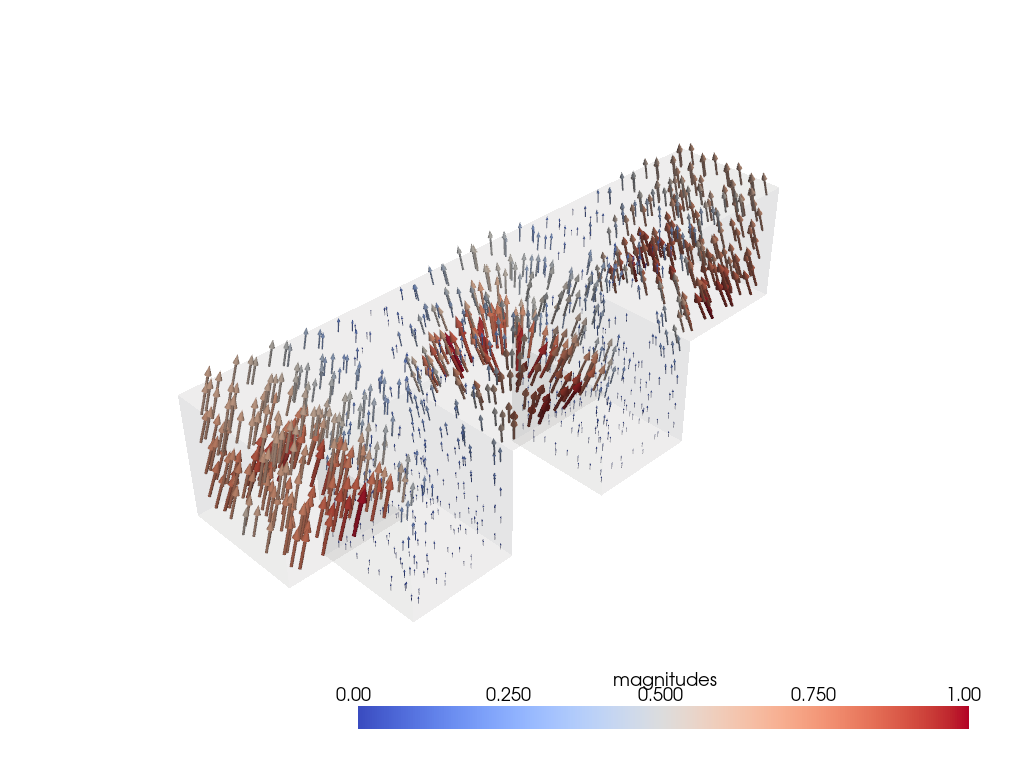

In [8]:

# Cell 5

def clearance_caps_from_path_length(
    tet,
    cap_near=np.deg2rad(45),   # near support (short path) can rotate more
    cap_far =np.deg2rad(20),   # far from support (long path) rotate much less
    gamma=1.5                  # steeper falloff => stricter caps far away
):
    d = tet.cell_data.get("cell_distance_to_bottom", None)
    if d is None:
        raise RuntimeError("cell_distance_to_bottom missing. Run calculate_path_length_to_base_gradient first (Cell 4).")

    d = d.astype(float)
    mask = ~np.isnan(d)
    caps = np.full(tet.number_of_cells, cap_near, dtype=float)
    if np.any(mask):
        d_norm = (d[mask] - np.nanmin(d[mask])) / max(np.nanmax(d[mask]) - np.nanmin(d[mask]), 1e-12)
        w = d_norm ** gamma                              # 0 near base → 1 far from base
        caps[mask] = cap_near - (cap_near - cap_far) * w # linear in w (could switch to smoothstep/sigmoid)
    return caps

def calculate_initial_rotation_field(tet, MAX_OVERHANG, ROTATION_MULTIPLIER, STEEP_OVERHANG_COMPENSATION, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO, MAX_POS_ROTATION, MAX_NEG_ROTATION):
    '''
    Calculate the initial rotation field for each cell in the tetrahedral mesh to make overhangs less than MAX_OVERHANG.
    The direction of rotation ensures the part is printable.
    '''

    # create initial rotation field rotating faces to be in safe printing angle
    initial_rotation_field = np.full((tet.number_of_cells), np.nan)
    initial_rotation_field = np.abs(np.deg2rad(90+MAX_OVERHANG) - tet.cell_data['overhang_angle'])

    path_length_to_base_gradient = calculate_path_length_to_base_gradient(tet, MAX_OVERHANG, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO)

    # if path_length_to_base_gradient is different to the cell's overhang direction, it needs to be rotated an additional amount (its overhang angle) to make it go the right way
    # Put behind a flag because it is normally not needed, and buggy/finnicky
    # Can try enable it for models with very steep overhangs (>90 degrees) (not common)
    if STEEP_OVERHANG_COMPENSATION:
        initial_rotation_field[tet.cell_data["in_air"]] += 2 * (np.deg2rad(180) - tet.cell_data['overhang_angle'][tet.cell_data["in_air"]])

    # # Apply the path_length_to_base_gradient (optimal overhang direction) to the initial rotation field
    initial_rotation_field *= path_length_to_base_gradient

    # apply rotation multiplier
    initial_rotation_field = np.clip(initial_rotation_field*ROTATION_MULTIPLIER, -np.deg2rad(360), np.deg2rad(360))

    # --- NEW: per-cell clearance caps (smaller cap when far from support)
    per_cell_caps = clearance_caps_from_path_length(
    tet,
    cap_near=np.deg2rad(45),   # tweak to taste / printer clearance
    cap_far =np.deg2rad(20),    # tighten if nozzle clearance still risky
    gamma=1.75
    )

    # clip to max rotation
    initial_rotation_field = np.clip(initial_rotation_field, MAX_NEG_ROTATION, MAX_POS_ROTATION)

    # Then clip by per-cell caps to enforce clearance in far regions
    initial_rotation_field = np.clip(initial_rotation_field, -per_cell_caps, per_cell_caps)


    tet.cell_data["initial_rotation_field"] = initial_rotation_field

    return initial_rotation_field

from scipy.sparse import lil_matrix

def calculate_rotation_matrices(tet, rotation_field):
    '''
    Calculate the rotation matrices for each cell in the tetrahedral mesh given the scalar
    rotation field that gives a rotation for each cell. Cells are rotated around the axis
    perpendicular to the radial direction and the z-axis.
    '''

    # create rotation matrix from theta around axis
    tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])
    # normalize
    tangential_vectors /= np.linalg.norm(tangential_vectors, axis=1)[:, None]
    # replace nan with [1,0,0]
    tangential_vectors[np.isnan(tangential_vectors).any(axis=1)] = [1, 0, 0]

    rotation_matrices = R.from_rotvec(rotation_field[:, None] * tangential_vectors).as_matrix()

    return rotation_matrices

def calculate_unique_vertices_rotated(tet, rotation_field):
    '''
    Calculate the vertices of a tetrahedral mesh after rotating each cell by the rotation field.
    Vertices are unique: they are not shared between cells.
    '''

    rotation_matrices = calculate_rotation_matrices(tet, rotation_field)

    # rotate each face by the rotation field around its center
    unique_vertices = np.zeros((tet.number_of_cells, 4, 3))
    for cell_index, cell in enumerate(tet.field_data["cells"]):
        unique_vertices[cell_index] = tet.field_data["cell_vertices"][cell]

    cell_centers = tet.cell_data["cell_center"]

    unique_vertices_rotated = cell_centers.reshape(-1, 1, 3, 1) + rotation_matrices.reshape(-1, 1, 3, 3) @ (unique_vertices.reshape(-1, 4, 3, 1) - cell_centers.reshape(-1, 1, 3, 1))
    # unique_vertices_rotated = rotation_matrices.reshape(-1, 1, 3, 3) @ unique_vertices.reshape(-1, 4, 3, 1)

    return unique_vertices_rotated

def apply_rotation_field_unique_vertices(tet, rotation_field):
    '''
    Apply the rotation field to the tetrahedral mesh and return a new tetrahedral mesh.
    Vertices are unique: they are not shared between cells.
    '''

    unique_vertices_rotated = calculate_unique_vertices_rotated(tet, rotation_field)

    unique_cells = np.zeros((tet.number_of_cells, 5), dtype=int)
    unique_cells[:, 0] = 4
    unique_cells[:, 1:] = np.arange(tet.number_of_cells*4).reshape(-1, 4)

    new_tet = pv.UnstructuredGrid(unique_cells.flatten(), np.full(tet.number_of_cells, pv.CellType.TETRA), unique_vertices_rotated.reshape(-1, 3))

    return new_tet

def apply_rotation_field(tet, rotation_field):
    '''
    Apply the rotation field to the tetrahedral mesh and return a new tetrahedral mesh.
    Vertices are shared between cells, so the surface is closed and smooth.
    '''

    new_vertices = np.zeros((tet.number_of_points, 3))
    vertices_count = np.zeros((tet.number_of_points))
    for cell in tet.field_data["cells"]:
        vertices_count[cell] += 1

    unique_vertices_rotated = calculate_unique_vertices_rotated(tet, rotation_field)

    for cell_index, vertices in enumerate(unique_vertices_rotated):
        for i, vertex in enumerate(vertices):
            new_vertices[tet.field_data["cells"][cell_index, i]] += vertex.T[0] / vertices_count[tet.field_data["cells"][cell_index][i]]

    new_tet = pv.UnstructuredGrid(tet.cells, np.full(tet.number_of_cells, pv.CellType.TETRA), new_vertices)

    return new_tet


def optimize_rotations(tet, NEIGHBOUR_LOSS_WEIGHT, MAX_OVERHANG, ROTATION_MULTIPLIER, ITERATIONS, SAVE_GIF, STEEP_OVERHANG_COMPENSATION, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO, MAX_POS_ROTATION, MAX_NEG_ROTATION):
    '''
    Optimize the rotation field for each cell in the tetrahedral mesh to make overhangs less
    than MAX_OVERHANG while keeping the rotation field smooth.
    '''

    imgs = []
    plotter = pv.Plotter(off_screen=True)
    if SAVE_GIF:
        plotter.open_gif(f'gifs/{model_name}_optimize_rotations.gif')

    initial_rotation_field = calculate_initial_rotation_field(tet, MAX_OVERHANG, ROTATION_MULTIPLIER, STEEP_OVERHANG_COMPENSATION, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO, MAX_POS_ROTATION, MAX_NEG_ROTATION)
    num_cells_with_initial_rotation = np.sum(~np.isnan(initial_rotation_field))

    def save_gif(rotation_field):
        new_tet = apply_rotation_field_unique_vertices(tet, rotation_field)
        new_tet.cell_data["rotation_field"] = rotation_field
        mesh_actor = plotter.add_mesh(new_tet,  clim=[-np.pi/4, np.pi/4], scalars="rotation_field", lighting=False)
        plotter.write_frame()
        plotter.remove_actor(mesh_actor)

    def objective_function(rotation_field):
        '''
        Objective function to minimize the neighbour losses and initial rotation losses.
        '''
        if SAVE_GIF:
            save_gif(rotation_field)

        # Compute neighbour losses using vectorized operations
        cell_face_neighbours = tet.field_data["cell_face_neighbours"]
        neighbour_differences = rotation_field[cell_face_neighbours[:, 0]] - rotation_field[cell_face_neighbours[:, 1]]
        neighbour_losses = NEIGHBOUR_LOSS_WEIGHT * neighbour_differences**2

        # Compute the initial rotation losses
        overhanging_mask = tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)
        valid_cell_indices = np.where(~np.isnan(initial_rotation_field))[0]#np.where(overhanging_mask)[0]
        initial_rotation_losses = (rotation_field[valid_cell_indices] - initial_rotation_field[valid_cell_indices])**2

        # Return the concatenated losses
        return np.concatenate((neighbour_losses, initial_rotation_losses))


    def objective_jacobian(rotation_field):
        start_time = time.time()
        # Initialize the sparse matrix with LIL format for efficient row-wise operations
        cell_face_neighbours = tet.field_data["cell_face_neighbours"]
        jac = lil_matrix((len(cell_face_neighbours) + num_cells_with_initial_rotation, tet.number_of_cells), dtype=np.float32)

        # Vectorized computation for neighbour loss derivatives
        cell_1 = cell_face_neighbours[:, 0]
        cell_2 = cell_face_neighbours[:, 1]

        # Compute the differences
        differences = rotation_field[cell_1] - rotation_field[cell_2]

        # Fill in the Jacobian for the first derivative of the neighbour loss function
        jac[range(len(cell_face_neighbours)), cell_1] = 2 * NEIGHBOUR_LOSS_WEIGHT * differences
        jac[range(len(cell_face_neighbours)), cell_2] = -2 * NEIGHBOUR_LOSS_WEIGHT * differences

        # Vectorized computation for initial rotation loss derivatives
        overhanging_mask = tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)
        valid_cell_indices = np.where(~np.isnan(initial_rotation_field))[0]#np.where(overhanging_mask)[0]

        # Fill in the Jacobian for the first derivative of the initial rotation loss function
        jac[len(cell_face_neighbours) + np.arange(len(valid_cell_indices)), valid_cell_indices] = \
            2 * (rotation_field[valid_cell_indices] - initial_rotation_field[valid_cell_indices])

        # print("Jacobian time:", time.time() - start_time)
        # Convert the LIL matrix to CSR format for efficient computations in further steps
        return jac.tocsr()

    def jac_sparsity():
        cell_face_neighbours = tet.field_data["cell_face_neighbours"]
        sparsity = lil_matrix((len(cell_face_neighbours) + num_cells_with_initial_rotation, tet.number_of_cells), dtype=np.int8)

        for i, (cell_1, cell_2) in enumerate(cell_face_neighbours):
            sparsity[i, cell_1] = 1
            sparsity[i, cell_2] = 1

        valid_cell_indices = np.where(~np.isnan(initial_rotation_field))[0]#np.where(overhanging_mask)[0]
        i = 0
        for cell_index, initial_rotation in enumerate(initial_rotation_field):
            if cell_index in valid_cell_indices:
                sparsity[len(cell_face_neighbours) + i, cell_index] = 1
                i += 1

        return sparsity.tocsr()

    # smoothed_rotation_field = np.zeros((tet.number_of_cells))

    # Build per-cell caps (same parameters as above to stay consistent)
    per_cell_caps = clearance_caps_from_path_length(
        tet,
        cap_near=np.deg2rad(45),
        cap_far =np.deg2rad(15),
        gamma=1.75
    )

    lower_bounds = -per_cell_caps
    upper_bounds =  per_cell_caps

    # Initial guess (you used zeros). You can also seed with the clipped initial field:
    smoothed_rotation_field = np.zeros((tet.number_of_cells), dtype=float)

    # Optimization process to smooth the initial rotation field
    result = least_squares(objective_function,
                    smoothed_rotation_field,
                    jac=objective_jacobian,
                    max_nfev=ITERATIONS,
                    jac_sparsity=jac_sparsity(),
                    verbose=2,
                    method='trf',
                    ftol=1e-6,
                    bounds=(lower_bounds, upper_bounds)   # <-- enforce clearance during solve
                    )

    # render array of numpy images (imgs) into gif
    if SAVE_GIF:
        plotter.close()

    return result.x

NEIGHBOUR_LOSS_WEIGHT = 20 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 30          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 2   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = False # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
MAX_POS_ROTATION = np.deg2rad(3600) # normally set to 360 unless you get collisions
MAX_NEG_ROTATION = np.deg2rad(-3600) # normally set to 360 unless you get collisions
ITERATIONS = 100
SAVE_GIF = True
STEEP_OVERHANG_COMPENSATION = True


# --- 1) optimise rotation field on the original tetrahedral mesh ----------
rotation_field = optimize_rotations(
    undeformed_tet,
    NEIGHBOUR_LOSS_WEIGHT,
    MAX_OVERHANG,
    ROTATION_MULTIPLIER,
    ITERATIONS,
    SAVE_GIF,
    STEEP_OVERHANG_COMPENSATION,
    INITIAL_ROTATION_FIELD_SMOOTHING,
    SET_INITIAL_ROTATION_TO_ZERO,
    MAX_POS_ROTATION,
    MAX_NEG_ROTATION
)


# ============================================================
# 2) Build rotation matrices for each tetrahedron
# ============================================================
rotation_matrices = calculate_rotation_matrices(undeformed_tet, rotation_field)

# ============================================================
# 3) Compute the rotated direction vectors
#    (this visualizes the *effective upward rotation*, not the
#     tangential rotation axis)
# ============================================================

# Option A: visualize rotation of the upward axis (recommended)
up_vec = np.array([0, 0, 1])

rotated_vectors = rotation_matrices @ up_vec.reshape(3, 1)
rotated_vectors = rotated_vectors.reshape(-1, 3)

# Normalize vector directions
norms = np.linalg.norm(rotated_vectors, axis=1)
norms[norms < 1e-12] = 1e-12
rotated_vectors = rotated_vectors / norms[:, None]

# ============================================================
# 4) Scale vector lengths according to rotation magnitude
#    (Tetrahedra farther from support rotate more strongly)
# ============================================================
magnitudes = np.abs(rotation_field)
magnitudes = (magnitudes - magnitudes.min()) / (magnitudes.max() - magnitudes.min() + 1e-12)

# scale between 0.5× and 3.0× for clear visualization
rotated_vectors_scaled = rotated_vectors * (0.5 + 3.0 * magnitudes[:, None])

# ============================================================
# 5) Prepare glyph visualization
# ============================================================
centers = undeformed_tet.cell_data["cell_center"]

cloud = pv.PolyData(centers)
cloud["vectors"] = rotated_vectors_scaled
cloud["magnitudes"] = magnitudes  # optional for color mapping

# A nice 3D arrow geometry (ETH-style)
arrow = pv.Arrow(
    tip_length=0.3,
    tip_radius=0.1,
    shaft_radius=0.04,
    tip_resolution=32,
    shaft_resolution=24
)

glyphs = cloud.glyph(
    orient="vectors",
    scale="vectors",
    factor=1,   # increase this to enlarge the arrows globally
    geom=arrow
)

# ============================================================
# 6) Plot everything
# ============================================================
plotter = pv.Plotter()

# plot tetrahedral mesh lightly for context
plotter.add_mesh(
    undeformed_tet,
    opacity=0.08,
    color="lightgray",
    show_edges=False
)

# plot the 3D rotated direction arrows
plotter.add_mesh(
    glyphs,
    scalars="magnitudes",
    cmap="coolwarm",
    lighting=True
)

# Save the image (PNG, high-res)
plotter.screenshot("rotation_field.png", window_size=[3000, 2000])

# Display on screen
plotter.show()


default
```
NEIGHBOUR_LOSS_WEIGHT = 20 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 30          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 2   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = False # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
```

benchy upsidedown tilted
scale: 1.5
Iteration 1:
```
NEIGHBOUR_LOSS_WEIGHT = 100 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 5          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 1   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = True # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
```

Iteration 2:
```
NEIGHBOUR_LOSS_WEIGHT = 50 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 5          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 1   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = True # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
```

Iteration 3,4,5:
```
NEIGHBOUR_LOSS_WEIGHT = 50 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 50          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 3   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = True # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
```

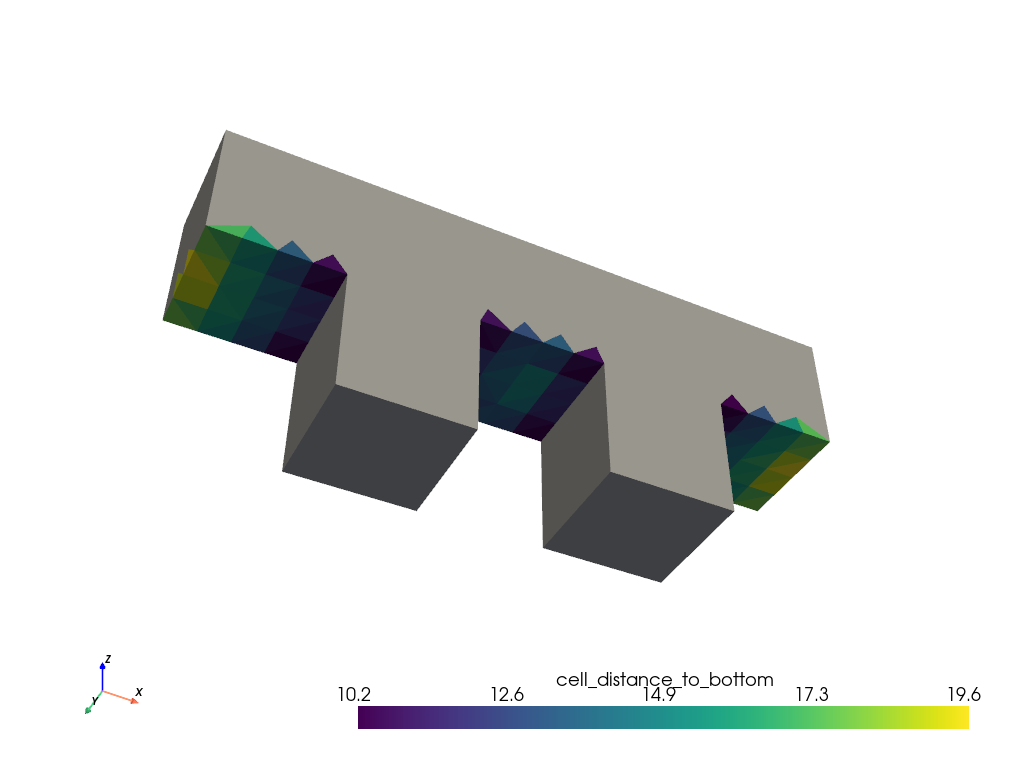

In [9]:
# Cell 6
# view the initial rotation field we are trying to optimize towards
# tet.extract_cells(tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)).plot(scalars="initial_rotation_field")
# tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)
# undeformed_tet.plot(scalars="initial_rotation_field")
# undeformed_tet.plot(scalars="in_air")
undeformed_tet.plot(scalars="cell_distance_to_bottom", cpos=[-0.5, -1, -1])
# undeformed_tet.plot(scalars="overhang_angle")
# undeformed_tet.plot(scalars="path_length_to_base_gradient")
# undeformed_tet.plot(scalars=new_tet1.cell_data['rotation_field'])

def show_path_to_base(tet, cell_index, plotter=pv.Plotter()):
    path_to_bottom = tet.cell_data['path_to_bottom'][cell_index]
    first_negative_index = np.where(path_to_bottom == -1)[0][0]
    path_to_bottom = path_to_bottom[:first_negative_index]
    print(path_to_bottom)

    for i in range(len(path_to_bottom)-1):
        path_to_base = pv.Line(tet.cell_data["cell_center"][path_to_bottom[i]], tet.cell_data["cell_center"][path_to_bottom[i+1]])
        plotter.add_mesh(path_to_base, color="red")

    plotter.add_mesh(tet, opacity=0.2)
    plotter.show()

# show_path_to_base(tet, np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > 3))[0][7])

def show_path_to_base_gradient_calculation(tet, cell_indices):
    plotter = pv.Plotter()
    scalar = np.full(tet.number_of_cells, 0.0)

    for cell_index in cell_indices:
        local_cells = cell_neighbour_dict["edge"][cell_index]
        local_cells = np.hstack((local_cells, cell_index))
        local_cells_with_path_lengths = [x for x in local_cells if not np.isnan(tet.cell_data['cell_distance_to_bottom'][x])]
        path_lengths = tet.cell_data['cell_distance_to_bottom'][local_cells_with_path_lengths]

        cell_centers = tet.cell_data["cell_center"][local_cells_with_path_lengths]
        cell_centers_z_is_path_length = cell_centers.copy()
        cell_centers_z_is_path_length[:, 2] = path_lengths - np.min(path_lengths) + np.min(cell_centers[:, 2])
        points = pv.PolyData(cell_centers_z_is_path_length)
        glyph = points.glyph(geom=pv.Sphere(theta_resolution=8, phi_resolution=8, radius=0.1))

        if len(cell_centers_z_is_path_length) < 3:
            continue

        p, n = planeFit(cell_centers_z_is_path_length.T)
        plane = pv.Plane(center=p, direction=n, i_size=4, j_size=4)
        normal_arrow = pv.Arrow(start=p, direction=n, scale=1.5)

        # reflect arrow across xy plane
        reflected_n = -n - 2 * (np.dot(-n, up_vector)) * up_vector

        # extract radial component
        cell_center_direction_normalized = tet.cell_data["cell_center"][cell_index, :2] / np.linalg.norm(tet.cell_data["cell_center"][cell_index, :2])
        gradient_in_radial_direction = np.dot(cell_center_direction_normalized, reflected_n[:2]) * cell_center_direction_normalized
        nozzle_arrow = pv.Arrow(start=tet.cell_data["cell_center"][cell_index], direction=np.hstack((gradient_in_radial_direction, reflected_n[2])), scale=1)


        # plotter.add_mesh(glyph, color="blue", opacity=0.5, )
        # plotter.add_mesh(plane, color="green", opacity=0.2)
        # plotter.add_mesh(normal_arrow, color="orange")
        plotter.add_mesh(nozzle_arrow, color="red")
    scalar[local_cells_with_path_lengths] = 0.5
    scalar[cell_index] = 1
    plotter.add_mesh(tet, opacity=0.2, scalars=scalar, cmap="binary")
    plotter.show()

# show_path_to_base_gradient_calculation(undeformed_tet, [np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > 3))[0][1]])
# show_path_to_base_gradient_calculation(undeformed_tet, np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > np.deg2rad(90 + MAX_OVERHANG)))[0])

def show_dijkstras(tet, cell_index):
    plotter = pv.Plotter()#window_size=[3840, 2160])
    lines = []
    for neighbour in tet.field_data["cell_face_neighbours"]:
        lines += [tet.cell_data["cell_center"][neighbour[0]], tet.cell_data["cell_center"][neighbour[1]]]
    mesh = pv.line_segments_from_points(lines)
    plotter.add_mesh(mesh, color="grey", opacity=0.4)

    points = pv.PolyData(tet.cell_data["cell_center"])
    glyph = points.glyph(geom=pv.Sphere(theta_resolution=8, phi_resolution=8, radius=0.1))
    plotter.add_mesh(glyph, color="red", opacity=0.2)

    if cell_index is None:
        plotter.show()
        return

    plotter.camera_position = "xz"

    # run dijkstra's algorithm and visualize
    plotter.open_gif(f'gifs/{model_name}_dijkstra.gif')
    distances, paths = nx.single_source_dijkstra(cell_neighbour_graph, cell_index)
    dijkstra_actors = []
    for i in np.arange(0, tet.cell_data['cell_distance_to_bottom'][cell_index], 0.2):
        nodes_in_range = [node for node, distance in distances.items() if distance < i]
        if len(nodes_in_range) == 0:
            continue
        if set(nodes_in_range) & set(bottom_cells):
            break
        points = pv.PolyData(tet.cell_data["cell_center"][nodes_in_range])
        glyph = points.glyph(geom=pv.Sphere(theta_resolution=8, phi_resolution=8, radius=0.2))
        actor = plotter.add_mesh(glyph, color="blue", opacity=0.4)
        dijkstra_actors.append(actor)
        plotter.write_frame()


    path_to_bottom = tet.cell_data['path_to_bottom'][cell_index]
    first_negative_index = np.where(path_to_bottom == -1)[0][0]
    path_to_bottom = path_to_bottom[:first_negative_index]
    print(path_to_bottom)

    for i in range(len(path_to_bottom)-1):
        path_to_base = pv.Line(tet.cell_data["cell_center"][path_to_bottom[i]], tet.cell_data["cell_center"][path_to_bottom[i+1]])
        plotter.add_mesh(path_to_base, color="blue", line_width=5)

    for actor in dijkstra_actors:
        plotter.remove_actor(actor)

    plotter.write_frame()

    plotter.show()
    plotter.close()


# show_dijkstras(undeformed_tet, np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > 3))[0][1])

/tmp/ipykernel_261/3209274865.py:75: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.4072e+03                                    2.72e+02    
       1              4         1.2297e+03      1.78e+02       2.79e+00       2.39e+02    
       2              5         9.9585e+02      2.34e+02       3.20e+00       1.86e+02    
       3              6         7.4582e+02      2.50e+02       2.56e+00       1.47e+02    
       4              7         5.7495e+02      1.71e+02       2.57e+00       1.14e+02    
       5              8         4.2821e+02      1.47e+02       2.44e+00       8.87e+01    
       6              9         3.1436e+02      1.14e+02       5.05e+00       9.71e+01    
       7             10         2.0609e+02      1.08e+02       5.02e+00       2.49e+01    
       8             11         1.5534e+02      5.07e+01       5.52e+00       1.28e+01    
       9             13         1.2829e+02      2.70e+01       1.66e+00       9.92e+00    

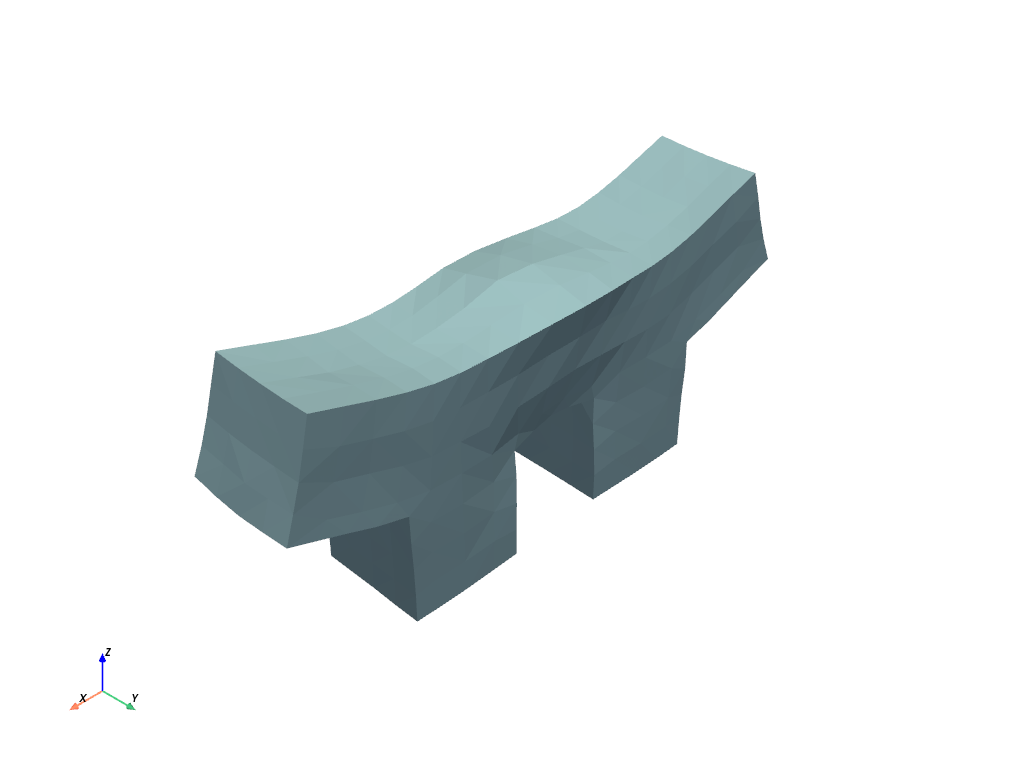

/tmp/ipykernel_261/660622666.py:530: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()


In [10]:
# Cell 7
N = np.eye(4) - 1/4 * np.ones((4, 4)) # the N matrix centers the vertices of a tetrahedron around the origin

save_gif_i = 0

def calculate_deformation(tet, rotation_field, ITERATIONS, SAVE_GIF):
    '''
    Try to find the optimal deformation of the tetrahedral mesh to make cells have the same rotation as
    the given rotation field.

    Our parameters are the vertices of the deformed mesh.
    '''

    new_vertices = tet.points.copy()

    params = new_vertices.flatten()

    rotation_matrices = calculate_rotation_matrices(tet, rotation_field)

    # Extract old vertices for all cells
    old_vertices = tet.field_data["cell_vertices"][tet.field_data["cells"]]
    # Apply the transformation for all cells
    old_vertices_transformed = np.einsum('ijk,ikl->ijl', rotation_matrices, (N @ old_vertices).transpose(0, 2, 1))

    plotter = pv.Plotter(off_screen=True)

    if SAVE_GIF:
        plotter.open_gif(f'gifs/{model_name}_calculate_deformation.gif')

    def save_gif(new_vertices):
        global save_gif_i
        save_gif_i += 1

        if save_gif_i % 10 != 0:
            return

        new_tet = pv.UnstructuredGrid(tet.cells, np.full(tet.number_of_cells, pv.CellType.TETRA), new_vertices)
        mesh_actor = plotter.add_mesh(new_tet)
        plotter.write_frame()
        plotter.remove_actor(mesh_actor)


    def objective_function(params):
        start_time = time.time()

        new_vertices = params[:tet.number_of_points * 3].reshape(-1, 3)

        if SAVE_GIF:
            save_gif(new_vertices)

        # Apply transformation for the new vertices
        new_vertices_transformed = (N @ new_vertices[tet.field_data["cells"]]).transpose(0, 2, 1)

        # Calculate position compatibility loss using vectorized operations
        position_losses = np.linalg.norm(new_vertices_transformed - old_vertices_transformed, axis=(1, 2))**2

        # print(f"Objective function took {time.time() - start_time} seconds")
        return position_losses

    def objective_jacobian(params):
        start_time = time.time()

        # Initialize Jacobian matrix
        J = lil_matrix((tet.number_of_cells, len(params)), dtype=np.float32)

        # Extract parameters
        new_vertices = params[:tet.number_of_points * 3].reshape(-1, 3)

        # Extract old vertices for all cells
        old_vertices = tet.field_data["cell_vertices"][tet.field_data["cells"]]

        # Apply the transformation for old and new vertices
        new_vertices_transformed = (N @ new_vertices[tet.field_data["cells"]]).transpose(0, 2, 1)

        # Compute the difference between transformed new and old vertices
        diff = new_vertices_transformed - old_vertices_transformed  # shape: (num_cells, 3, num_vertices_per_cell)

        # Reshape diff for easier broadcasting
        diff = diff.transpose(0, 2, 1)  # shape: (num_cells, num_vertices_per_cell, 3)

        # Now, for each cell, update the corresponding rows in the Jacobian
        cell_indices = np.repeat(np.arange(tet.number_of_cells), len(tet.field_data["cells"][0]))  # Cell indices repeated per vertex
        vertex_indices = np.ravel(tet.field_data["cells"])  # Flatten the cell-to-vertex mapping

        # For each component x, y, z in the vertex, update the Jacobian
        for dim in range(3):
            J[cell_indices, vertex_indices * 3 + dim] = 2 * diff[:, :, dim].ravel()

        # print(f"Objective jacobian took {time.time() - start_time} seconds")
        return J.tocsr()

    def jac_sparsity():
        sparsity = lil_matrix((tet.number_of_cells, len(params)), dtype=np.int8)

        cell_indices = np.repeat(np.arange(tet.number_of_cells), len(tet.field_data["cells"][0]))
        vertex_indices = np.ravel(tet.field_data["cells"])

        for dim in range(3):
            sparsity[cell_indices, vertex_indices * 3 + dim] = 1

        return sparsity.tocsr()

    result = least_squares(objective_function,
                    params,
                    max_nfev=ITERATIONS,
                    verbose=2,
                    jac=objective_jacobian,
                    jac_sparsity=jac_sparsity(),
                    method='trf',
                    x_scale='jac',
                    )

    plotter.close()

    return result.x[:tet.number_of_points*3].reshape(-1, 3)

ITERATIONS = 1000
SAVE_GIF = True
new_vertices = calculate_deformation(undeformed_tet, rotation_field, ITERATIONS, SAVE_GIF)
deformed_tet = pv.UnstructuredGrid(undeformed_tet.cells, np.full(undeformed_tet.number_of_cells, pv.CellType.TETRA), new_vertices)
deformed_tet.plot()

for key in undeformed_tet.field_data.keys():
    deformed_tet.field_data[key] = undeformed_tet.field_data[key]
for key in undeformed_tet.cell_data.keys():
    deformed_tet.cell_data[key] = undeformed_tet.cell_data[key]
deformed_tet = update_tet_attributes(deformed_tet)

Run below to do another iteration

In [11]:
# Cell 8
undeformed_tet = deformed_tet.copy()

Run below when finished deforming to save mesh as STL

In [12]:
# Cell 9
# make origin center bottom of bounding box
x_min, x_max, y_min, y_max, z_min, z_max = deformed_tet.bounds
offsets_applied = np.array([(x_min + x_max) / 2, (y_min + y_max) / 2, z_min])
deformed_tet.points -= offsets_applied

deformed_tet.extract_surface().save(f'output_models/{model_name}_deformed_tet.stl')

/tmp/ipykernel_261/2999012177.py:7: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  deformed_tet.extract_surface().save(f'output_models/{model_name}_deformed_tet.stl')


In [13]:
# Cell 10
# save to pickle
with open(f'pickle_files/deformed_{model_name}.pkl', 'wb') as f:
    pickle.dump(deformed_tet, f)

# Now, go and slice the stl file in Cura!

Settings:
- Make the printer origin at the center of the buildplate
- Dont use any pre/post scripts, z hop, etc. The config I use is provided in the github repo
- Autoplace the model at the center by clicking "Arrange All Models"

In [14]:
# Cell 11
deformed_tet = pickle.load(open(f'pickle_files/deformed_{model_name}.pkl', 'rb'))

In [15]:
# Cell 12
import numpy as np

def tetrahedron_volume(p1, p2, p3, p4):
    """
    Calculate the volume of a tetrahedron defined by four 3D points.
    Used in barycentric interpolation inside deformed/un-deformed meshes.

    Parameters:
        p1, p2, p3, p4 : np.ndarray
            3D coordinates of the tetrahedron vertices.

    Returns:
        float : Volume of the tetrahedron.
    """
    mat = np.vstack([p2 - p1, p3 - p1, p4 - p1])
    return np.abs(np.linalg.det(mat)) / 6.0


def calc_barycentric_coordinates(tet_a, tet_b, tet_c, tet_d, point):
    """
    Compute barycentric coordinates of a point inside a tetrahedron.
    These weights allow interpolation of deformation fields.

    Parameters:
        tet_a, tet_b, tet_c, tet_d : np.ndarray
            3D coordinates of tetrahedron vertices.
        point : np.ndarray
            3D coordinates of the point inside the tetrahedron.

    Returns:
        np.ndarray : (lambda_a, lambda_b, lambda_c, lambda_d)
                     Barycentric coordinates summing to 1.
    """
    total_volume = tetrahedron_volume(tet_a, tet_b, tet_c, tet_d)
    if total_volume == 0:
        raise ValueError("Degenerate tetrahedron: zero volume.")

    # Volumes of subtetrahedra formed with the point
    vol_a = tetrahedron_volume(point, tet_b, tet_c, tet_d)
    vol_b = tetrahedron_volume(point, tet_a, tet_c, tet_d)
    vol_c = tetrahedron_volume(point, tet_a, tet_b, tet_d)
    vol_d = tetrahedron_volume(point, tet_a, tet_b, tet_c)

    # Normalize
    lambda_a = vol_a / total_volume
    lambda_b = vol_b / total_volume
    lambda_c = vol_c / total_volume
    lambda_d = vol_d / total_volume

    return np.array([lambda_a, lambda_b, lambda_c, lambda_d])


def project_point_onto_plane(plane_x_axis, plane_y_axis, point):
    """
    Project a 3D point onto a 2D plane defined by X and Y axes.
    Used during slicing/deformation to express points in local coords.

    Parameters:
        plane_x_axis, plane_y_axis : np.ndarray
            Basis vectors defining the plane orientation.
        point : np.ndarray
            3D coordinates of the point to project.

    Returns:
        np.ndarray : [projected_x, projected_y]
    """
    projected_x = np.dot(plane_x_axis, point)
    projected_y = np.dot(plane_y_axis, point)
    return np.array([projected_x, projected_y])


In [16]:
# Cell 13
deformed_tet, _, _ = calculate_tet_attributes(deformed_tet)

/tmp/ipykernel_261/660622666.py:1136: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  .extract_surface()
/tmp/ipykernel_261/660622666.py:530: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()


In [17]:
# print((input_tet.field_data["cells"]))

In [18]:
"""
robust_inverse_transform.py
===========================================================================
Robust, self-correcting inverse (reverse) deformation of a G-code toolpath
for supportless / non-planar additive manufacturing.

Drop-in replacement for the "parse remaining G-code + inverse deformation +
write preview" cells of the S4-style notebook.

WHY THIS EXISTS
---------------
The previous implementation produced G-code that had to be hand-repaired
before it was printable.  The defects were structural, not cosmetic:

  D1  INDEX DESYNC.  `ordered_lines` held one entry per *segment* while
      `new_gcode_points` silently skipped unmappable points (`continue`).
      After the first dropped point every emitted move was paired with the
      wrong source line, so feedrates, ;TYPE: / ;LAYER: markers, fan changes
      and retractions drifted relative to the motion.
  D2  TRUNCATION.  The writer did `if point_idx >= len(new_gcode_points):
      break`, so the tail of the file - including 4 whole layers and the
      entire end-of-print footer (M107 / M104 S0 / park / M84) - was lost.
      The file simply stopped mid-air.
  D3  FROZEN POINTS.  Unmappable travel points fell back to
      `prev_position`, emitting hundreds of byte-identical stationary moves
      (one run was 453 lines long).  Marlin still buffers those; they cost
      time, stall the planner and read as "lands / landscapes" in preview.
  D4  UNSIGNED BARYCENTRIC COORDINATES.  `tetrahedron_volume()` uses
      `abs(det)`, so the weights are always positive.  For the closest-cell
      fallback - i.e. exactly the case where the point is OUTSIDE the tet -
      the weights are meaningless, yet they were used anyway whenever their
      sum happened to land under 1.01.
  D5  NO Z FLOOR.  48 moves were emitted below the bed (min Z = -0.0188).
  D6  BAD INITIAL STATE.  Position was seeded at (0, 0, 20) instead of the
      real machine state left by the start block, so the first travel was
      segmented into ~33 phantom moves descending from Z17.
  D7  EXTRUSION CLIPPED, NOT CONSERVED.  Flow multiplier was clamped at 10x
      and the clipped volume was thrown away; dropped points threw their
      material away too.

WHAT THIS MODULE DOES DIFFERENTLY
---------------------------------
  * Lock-step emission.  Every source line owns its output lines.  There is
    no shared cursor, so desync (D1) and truncation (D2) are impossible by
    construction - the footer is copied because it is never consumed.
  * Three-tier mapping that never drops and never freezes a point (D3):
        tier 1  containing tetrahedron   -> exact barycentric
        tier 2  closest tetrahedron      -> signed barycentric, weights
                                            projected onto the simplex
        tier 3  k-nearest vertices       -> inverse-distance-weighted
                                            displacement (C0 continuous)
  * Signed barycentric coordinates from a linear solve (D4), which is both
    exact inside the tet and well-defined outside it.
  * Explicit post-mapping repair passes that do, deterministically, what
    was previously done by hand in Simplify3D: Z floor, degenerate-move
    collapse with extrusion folding, Z-spike limiting, travel clearance,
    automatic retract / Z-hop / prime insertion on long travels.
  * Volume-conserving extrusion with a bounded flow multiplier and a
    residual accumulator, so clipping redistributes material instead of
    discarding it (D7).
  * A validation report that fails loudly: layer-marker count in vs out,
    footer present, filament in vs out, Z range, per-tier mapping counts.

USAGE (notebook)
----------------
    from robust_inverse_transform import Config, run_inverse_transform

    cfg = Config(
        input_path      = 'input_gcode/OPM_pi 3mm_deformed_tet.gcode',
        # this is the file you print: the shift is applied internally, so the
        # name matches what the old separate shifter cell used to produce
        output_path     = f'output_gcode/{model_name}_final_reversed_out.gcode',
        seg_size        = 0.6,
        x_shift         = 100.0,   # part onto the plate
        y_shift         = 90.0,
        startup_y_shift = 5.0,     # purge line onto the plate (profile uses Y-2)
        bed_size        = (180.0, 180.0),
    )
    report = run_inverse_transform(cfg, deformed_tet, input_tet)
    report.print()

The mesh objects are used only through this small surface:
    deformed_tet.points                        (n_pts, 3)
    deformed_tet.number_of_cells               int
    deformed_tet.field_data["cells"]           (n_cells, 4) int
    deformed_tet.field_data["cell_vertices"]   (n_pts, 3)   == points
    deformed_tet.find_containing_cell(list)    -> array int  (-1 if none)
    deformed_tet.find_closest_cell(list)       -> array int
    input_tet.points                           (n_pts, 3)
so it can be unit-tested against a stub without PyVista.
===========================================================================
"""

from __future__ import annotations

import json
import math
import os
import re
import time
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Any, Tuple

import numpy as np

try:
    from scipy.spatial import cKDTree as _KDTree
except Exception:                                    # pragma: no cover
    _KDTree = None


# =========================================================================
# 1.  CONFIGURATION
# =========================================================================

@dataclass
class Config:
    # ---- paths ----------------------------------------------------------
    # No defaults on purpose.  A placeholder default means a forgotten path
    # silently writes a real G-code file to the wrong name, which you would
    # only notice at the printer.  Omitting either raises immediately.
    input_path: str
    output_path: str
    report_path: Optional[str] = None        # None -> output_path + '.report.json'

    # ---- start-block detection -----------------------------------------
    # The body begins after this line.  Matched on (feed, extrusion) with
    # tolerance; set to None to use `startup_end_marker` instead.
    startup_end_feed: Optional[float] = 4200.0
    startup_end_extrusion: Optional[float] = -3.5
    startup_end_marker: Optional[str] = None          # e.g. ';LAYER_COUNT:'
    keep_startup_block: bool = True

    # ---- segmentation ---------------------------------------------------
    enable_segmentation: bool = True
    seg_size: float = 0.6            # mm, printing moves
    travel_seg_size: float = 2.0     # mm, travel moves (coarser = smaller file)
    max_segments_per_move: int = 256
    min_segment_length: float = 1e-4

    # ---- mapping --------------------------------------------------------
    bary_inside_tol: float = 1e-6    # how negative a weight may go and still
                                     # count as "inside"
    idw_neighbours: int = 8
    idw_power: float = 2.0
    # Points further than this outside the mesh bbox are NOT mapped at all
    # (bed-level travels, purge moves).  They pass through untouched.
    bbox_margin: float = 2.0

    # ---- extrusion ------------------------------------------------------
    # 'volumetric' : E *= J  (J = V_undeformed / V_deformed)  - physically
    #                correct, matches the published pipeline.
    # 'length'     : E *= mapped_length / deformed_length     - conservative.
    # 'hybrid'     : geometric mean of the two                - gentlest.
    extrusion_model: str = 'volumetric'
    min_extrusion_multiplier: float = 0.25
    max_extrusion_multiplier: float = 3.0
    conserve_clipped_extrusion: bool = True
    max_residual_carry: float = 0.05   # mm filament; bounds the accumulator

    # ---- geometric safety ----------------------------------------------
    z_floor: float = 0.0             # nothing below the bed, ever
    z_ceiling: Optional[float] = None
    max_dz_per_segment: Optional[float] = None   # mm; None -> seg_size (45 deg)
    limit_z_spikes: bool = True
    drop_degenerate_moves: bool = True
    degenerate_tol: float = 5e-4     # mm

    # ---- travel intelligence -------------------------------------------
    travel_safety: bool = True
    # A travel is lifted when the nozzle would otherwise plough through
    # material already deposited along its path (collision test against a
    # running height field).  It is additionally retracted when it is longer
    # than `min_travel_for_retract`, the usual anti-stringing rule.
    min_travel_for_retract: float = 12.0   # mm of mapped travel length
    retract_on_collision: bool = True
    min_travel_for_collision_retract: float = 3.0   # don't retract for a hop
                                                    # over a single bead
    auto_detect_retraction: bool = True     # read length/feed out of the file
    retraction_length: float = 3.5          # fallback if detection finds none
    retraction_feed: float = 4200.0         # fallback
    z_hop: float = 0.5                     # mm lifted above the obstruction
    z_hop_feed: float = 600.0
    travel_clearance: float = 0.15         # extra mm above deposited material
    height_field_res: float = 0.8          # mm per cell
    nozzle_radius: float = 0.4             # mm, stamping radius
    max_auto_retractions: Optional[int] = None   # budget; None = unlimited

    # ---- overhang handling -------------------------------------------------
    # A printing move with no material beneath it is bridging into air.  Those
    # moves are detected from the deposition history rather than from a
    # hand-drawn region, so they follow the geometry on any part.
    overhang_slowdown: bool = True
    overhang_support_gap: float = 0.45   # mm; no material within this distance
                                         # below the move -> unsupported
    # Sparse infill legitimately bridges between the previous layer's widely
    # spaced lines, so it trips the support test everywhere without being an
    # overhang in any sense that matters for surface finish.  Slow only the
    # feature types you actually see on the outside of the part.
    overhang_skip_types: Tuple[str, ...] = ('FILL', 'SUPPORT', 'SKIRT')
    overhang_bead_width: float = 0.45    # mm; the footprint each bead marks
                                         # as support for the layer above
    overhang_probe_res: float = 0.20     # mm per cell for the support test.
                                         # The travel field is deliberately
                                         # coarse (it asks "is anything in the
                                         # way"); support asks "is anything
                                         # directly underneath", which needs a
                                         # cell about one bead wide.
    overhang_feed_scale: float = 0.5     # multiply feedrate by this
    overhang_min_feed: float = 480.0     # never go below this (mm/min)
    overhang_flow_scale: float = 1.0     # 1.0 = leave extrusion alone
    overhang_ramp: int = 2               # also slow this many moves either
                                         # side, so the feed change is not a step
    overhang_fan_min_run: int = 25        # only toggle the fan for unsupported
                                          # stretches at least this many moves
                                          # long; otherwise it thrashes
    overhang_fan: Optional[int] = None   # e.g. 255 -> M106 S255 while
                                         # unsupported, restored afterwards

    # ---- bed placement ---------------------------------------------------
    # Applied to BODY moves only.  The start block keeps its own absolute
    # coordinates (that is the fix for the purge line landing on the part).
    x_shift: float = 0.0
    y_shift: float = 0.0
    z_shift: float = 0.0

    # The start block is written in absolute MACHINE coordinates, so it gets
    # its own offset.  Slicer profiles often put the purge line at a negative
    # Y (Cura's Prusa MINI profile uses Y-2), which is in front of the plate.
    # Nudging it here moves the purge without moving the part.
    startup_x_shift: float = 0.0
    startup_y_shift: float = 0.0
    startup_z_shift: float = 0.0
    shift_startup_block: bool = False   # True -> reuse the body shift instead

    # Bed envelope, for the out-of-bounds check.  None disables it.
    bed_size: Optional[Tuple[float, float]] = None     # (X, Y) in mm
    bed_origin: Tuple[float, float] = (0.0, 0.0)

    # ---- output formatting ----------------------------------------------
    xyz_decimals: int = 4
    e_decimals: int = 5
    emit_feed_always: bool = True    # False -> only when the feedrate changes
    emit_unchanged_axes: bool = False  # False -> modal output: an axis word is
                                       # written only when its value changes
    body_banner: str = '; --- BEGIN REVERSED REMAINING GCODE ---'

    # ---- diagnostics ----------------------------------------------------
    verbose: bool = True
    strict: bool = True              # raise on failed validation checks


# =========================================================================
# 2.  G-CODE LEXER
# =========================================================================

_WORD_RE = re.compile(r'([A-Za-z])\s*(-?\d*\.?\d+)')
_MOTION_RE = re.compile(r'^\s*G0*([01])(?![\d.])')


def strip_comment(line: str) -> Tuple[str, str]:
    """Split a raw line into (code, comment) keeping the comment verbatim."""
    idx = line.find(';')
    if idx == -1:
        return line.rstrip('\n'), ''
    return line[:idx].rstrip('\n'), line[idx:].rstrip('\n')


def parse_words(code: str) -> Dict[str, float]:
    """`G1 X1.2 Y-3 E.04 F1800` -> {'G':1.0,'X':1.2,'Y':-3.0,'E':0.04,'F':1800.0}

    Regex based rather than pygcode based: it is ~40x faster on a 30k line
    file, it never raises on a line pygcode does not model, and it handles
    leading-dot numbers (`E.04`) and missing spaces, both of which appear in
    slicer output.
    """
    out: Dict[str, float] = {}
    for letter, value in _WORD_RE.findall(code):
        out[letter.upper()] = float(value)
    return out


def motion_code(code: str) -> Optional[str]:
    """Return 'G0' / 'G1' for a motion line, else None."""
    m = _MOTION_RE.match(code)
    return ('G0' if m.group(1) == '0' else 'G1') if m else None


# =========================================================================
# 3.  START BLOCK SPLITTER  (fixes D6)
# =========================================================================

@dataclass
class MachineState:
    position: np.ndarray
    feed: float
    relative_e: bool
    absolute_xyz: bool
    retracted: bool = False


def split_startup(lines: List[str], cfg: Config) -> Tuple[List[str], List[str], MachineState]:
    """Split the file into (start block, body) AND recover the real machine
    state left behind by the start block.

    The old code seeded the toolpath at (0, 0, 20), a position the machine is
    never actually in, so the first travel was segmented into ~33 phantom
    moves that descended from Z17 and were then mapped through the mesh.
    """
    startup: List[str] = []
    body: List[str] = []
    found = False

    pos = np.array([0.0, 0.0, 0.0])
    feed = 1500.0
    relative_e = False
    absolute_xyz = True
    retracted = False

    for raw in lines:
        if found:
            body.append(raw)
            continue

        startup.append(raw)
        code, _ = strip_comment(raw)
        stripped = code.strip()
        if not stripped:
            continue

        upper = stripped.upper()
        if upper.startswith('M83'):
            relative_e = True
        elif upper.startswith('M82'):
            relative_e = False
        elif upper.startswith('G91'):
            absolute_xyz = False
        elif upper.startswith('G90'):
            absolute_xyz = True

        cmd = motion_code(stripped)
        if cmd:
            w = parse_words(stripped)
            for i, ax in enumerate('XYZ'):
                if ax in w:
                    pos[i] = w[ax] if absolute_xyz else pos[i] + w[ax]
            if 'F' in w:
                feed = w['F']
            if 'E' in w and not any(ax in w for ax in 'XYZ'):
                retracted = w['E'] < 0

            if cfg.startup_end_marker is None and cfg.startup_end_feed is not None:
                if ('F' in w and 'E' in w
                        and abs(w['F'] - cfg.startup_end_feed) < 1e-3
                        and abs(w['E'] - cfg.startup_end_extrusion) < 1e-3):
                    found = True

        if cfg.startup_end_marker is not None and cfg.startup_end_marker in raw:
            found = True

    if not found:
        # Fallback 1: cut at the first layer marker any slicer emits, keeping
        # a trailing retraction with the start block if there is one.
        cut = None
        for j, raw in enumerate(lines):
            t = raw.lstrip()
            if t.startswith(';LAYER_COUNT') or t.startswith(';LAYER:'):
                cut = j
                break
        if cut is None:
            # Fallback 2: cut at the first extruding move with X/Y motion.
            for j, raw in enumerate(lines):
                code, _ = strip_comment(raw)
                if motion_code(code.strip()) is None:
                    continue
                w = parse_words(code)
                if w.get('E', 0.0) > 0 and any(ax in w for ax in 'XY'):
                    cut = j
                    break
        if cut is None:
            raise RuntimeError(
                'Could not locate the end of the start block. Set '
                'Config.startup_end_marker to a line that ends it.')

        startup, body = list(lines[:cut]), list(lines[cut:])
        pos, feed, relative_e, absolute_xyz, retracted = \
            _replay(startup, cfg)

    return startup, body, MachineState(pos.copy(), feed, relative_e,
                                       absolute_xyz, retracted)


def _replay(block: List[str], cfg: Config):
    """Re-derive machine state by executing a block of lines on paper."""
    pos = np.array([0.0, 0.0, 0.0])
    feed, relative_e, absolute_xyz, retracted = 1500.0, False, True, False
    for raw in block:
        code, _ = strip_comment(raw)
        t = code.strip()
        if not t:
            continue
        u = t.upper()
        if u.startswith('M83'):
            relative_e = True
        elif u.startswith('M82'):
            relative_e = False
        elif u.startswith('G91'):
            absolute_xyz = False
        elif u.startswith('G90'):
            absolute_xyz = True
        if motion_code(t) is None:
            continue
        w = parse_words(t)
        for i, ax in enumerate('XYZ'):
            if ax in w:
                pos[i] = w[ax] if absolute_xyz else pos[i] + w[ax]
        if 'F' in w:
            feed = w['F']
        if 'E' in w and not any(ax in w for ax in 'XYZ'):
            retracted = w['E'] < 0
    return pos, feed, relative_e, absolute_xyz, retracted


def detect_retraction(lines: List[str], cfg: Config) -> Tuple[float, float]:
    """Read the slicer's own retraction length and feedrate out of the file.

    Hard-coding 3.5 mm / F4200 only works for the one profile it was copied
    from.  Taking the most common E-only negative move makes the pass
    portable to any slicer profile.
    """
    from collections import Counter
    seen = Counter()
    for raw in lines:
        code, _ = strip_comment(raw)
        t = code.strip()
        if motion_code(t) is None:
            continue
        w = parse_words(t)
        if 'E' in w and w['E'] < 0 and not any(ax in w for ax in 'XYZ'):
            seen[(round(-w['E'], 5), w.get('F', cfg.retraction_feed))] += 1
    if not seen:
        return cfg.retraction_length, cfg.retraction_feed
    (length, feed), _ = seen.most_common(1)[0]
    return float(length), float(feed)


# =========================================================================
# 4.  INVERSE MAPPER  (fixes D3, D4)
# =========================================================================

class InverseMapper:
    """Maps points from deformed space back to undeformed (print) space.

    Tier 1  point inside a tetrahedron  -> exact barycentric interpolation
    Tier 2  point outside, nearest tet  -> signed barycentric, weights
            projected onto the simplex so the extrapolation stays bounded
    Tier 3  no usable tet               -> inverse-distance weighting over
            the k nearest mesh vertices

    Tier 3 is what removes the frozen-point runs: the old code fell back to
    `prev_position`, which emits the same coordinate over and over.  IDW
    always yields a distinct, continuous displacement.
    """

    def __init__(self, deformed_tet, input_tet, cfg: Config):
        self.cfg = cfg
        self.deformed = deformed_tet
        self.cells = np.asarray(deformed_tet.field_data['cells'], dtype=np.int64)
        # Index off .points, not field_data['cell_vertices'].  They are the
        # same array in a fresh mesh, but the displacement field is built from
        # .points, and if anything upstream ever refreshes one without the
        # other the two would be silently misaligned.
        self.verts = np.asarray(deformed_tet.points, dtype=float)
        undeformed = np.asarray(input_tet.points, dtype=float)

        if self.verts.shape != undeformed.shape:
            raise ValueError(
                f'deformed_tet has {self.verts.shape[0]} points but input_tet has '
                f'{undeformed.shape[0]}. They must share a vertex numbering for the '
                'displacement field to mean anything.')
        if self.cells.size and int(self.cells.max()) >= len(self.verts):
            raise ValueError('field_data["cells"] indexes a vertex that does not exist.')

        self.displacement = self.verts - undeformed

        lo = self.verts.min(axis=0) - cfg.bbox_margin
        hi = self.verts.max(axis=0) + cfg.bbox_margin
        self.bbox = (lo, hi)

        self._tree = _KDTree(self.verts) if _KDTree is not None else None
        self._basis_cache: Dict[int, Tuple[np.ndarray, np.ndarray]] = {}

        self.jacobian = self._compute_volume_ratios(input_tet)

        self.tier_counts = {'inside': 0, 'nearest': 0, 'idw': 0, 'skipped': 0}

    # -- setup ------------------------------------------------------------
    def _compute_volume_ratios(self, input_tet) -> np.ndarray:
        """J = V_undeformed / V_deformed per cell (the 'z-squish' factor).

        Vectorised; the original Python loop over 100k+ cells dominated the
        cell runtime.  Degenerate cells fall back to 1.0 instead of raising.
        """
        cells = self.cells
        dv = self.verts[cells]                                   # (n,4,3)
        uv = np.asarray(input_tet.points, dtype=float)[cells]

        def vol(v):
            return np.abs(np.einsum('ni,ni->n',
                                    np.cross(v[:, 1] - v[:, 0], v[:, 2] - v[:, 0]),
                                    v[:, 3] - v[:, 0])) / 6.0

        vw, vu = vol(dv), vol(uv)
        with np.errstate(divide='ignore', invalid='ignore'):
            j = np.where((vw > 1e-12) & (vu > 1e-12), vu / np.maximum(vw, 1e-12), 1.0)
        return np.nan_to_num(j, nan=1.0, posinf=1.0, neginf=1.0)

    def _basis(self, cell_index: int):
        """Cached (M_inv, v0) for the signed-barycentric linear solve."""
        cached = self._basis_cache.get(cell_index)
        if cached is not None:
            return cached
        vi = self.cells[cell_index]
        v = self.verts[vi]
        M = np.column_stack([v[1] - v[0], v[2] - v[0], v[3] - v[0]])
        try:
            M_inv = np.linalg.inv(M)
        except np.linalg.LinAlgError:
            M_inv = np.linalg.pinv(M)
        self._basis_cache[cell_index] = (M_inv, v[0])
        return M_inv, v[0]

    # -- core -------------------------------------------------------------
    def in_bbox(self, pts: np.ndarray) -> np.ndarray:
        lo, hi = self.bbox
        return np.all((pts >= lo) & (pts <= hi), axis=1)

    @staticmethod
    def _project_to_simplex(w: np.ndarray) -> np.ndarray:
        """Clamp barycentric weights to the tetrahedron and renormalise.

        Keeps extrapolation outside the mesh bounded and continuous instead
        of letting a negative weight fling the point across the build volume.
        """
        w = np.clip(w, 0.0, 1.0)
        s = w.sum()
        return w / s if s > 1e-12 else np.array([0.25, 0.25, 0.25, 0.25])

    def map_points(self, pts: np.ndarray):
        """Map an (n,3) array. Returns (mapped, cell_index, tier).

        `cell_index` is -1 for IDW / skipped points.  `tier` is a string
        array used by the report.
        """
        n = len(pts)
        mapped = pts.copy()
        cell_of = np.full(n, -1, dtype=np.int64)
        tier = np.array(['skipped'] * n, dtype=object)
        if n == 0:
            return mapped, cell_of, tier

        inside_box = self.in_bbox(pts)
        todo = np.flatnonzero(inside_box)
        self.tier_counts['skipped'] += int(n - len(todo))
        if len(todo) == 0:
            return mapped, cell_of, tier

        q = pts[todo]

        # -- tier 1 : containing cell -------------------------------------
        containing = np.asarray(self.deformed.find_containing_cell(q)).ravel()
        # -- tier 2 : closest cell, only where tier 1 failed ---------------
        miss = np.flatnonzero(containing < 0)
        closest = np.full(len(q), -1, dtype=np.int64)
        if len(miss):
            closest[miss] = np.asarray(
                self.deformed.find_closest_cell(q[miss])).ravel()

        need_idw: List[int] = []
        for k in range(len(q)):
            p = q[k]
            ci = int(containing[k])
            is_inside = ci >= 0
            if not is_inside:
                ci = int(closest[k])
            if ci < 0:
                need_idw.append(k)
                continue

            M_inv, v0 = self._basis(ci)
            lam = M_inv @ (p - v0)
            w = np.array([1.0 - lam.sum(), lam[0], lam[1], lam[2]])

            if not np.all(np.isfinite(w)):
                need_idw.append(k)
                continue

            if is_inside or np.all(w >= -self.cfg.bary_inside_tol):
                tier[todo[k]] = 'inside'
                self.tier_counts['inside'] += 1
            else:
                w = self._project_to_simplex(w)
                tier[todo[k]] = 'nearest'
                self.tier_counts['nearest'] += 1

            vi = self.cells[ci]
            disp = (self.displacement[vi] * w[:, None]).sum(axis=0)
            mapped[todo[k]] = p - disp
            cell_of[todo[k]] = ci

        # -- tier 3 : inverse distance weighting ---------------------------
        if need_idw:
            idx = np.array(need_idw)
            mapped[todo[idx]] = self._idw(q[idx])
            for k in idx:
                tier[todo[k]] = 'idw'
            self.tier_counts['idw'] += len(idx)

        return mapped, cell_of, tier

    def _idw(self, pts: np.ndarray) -> np.ndarray:
        if self._tree is None:                       # scipy-free fallback
            out = pts.copy()
            for i, p in enumerate(pts):
                d = np.linalg.norm(self.verts - p, axis=1)
                nn = np.argpartition(d, self.cfg.idw_neighbours)[:self.cfg.idw_neighbours]
                out[i] = p - self._idw_one(self.displacement[nn], d[nn])
            return out

        k = min(self.cfg.idw_neighbours, len(self.verts))
        d, nn = self._tree.query(pts, k=k)
        d = np.atleast_2d(d)
        nn = np.atleast_2d(nn)
        w = 1.0 / np.maximum(d, 1e-9) ** self.cfg.idw_power
        w /= w.sum(axis=1, keepdims=True)
        disp = (self.displacement[nn] * w[:, :, None]).sum(axis=1)
        return pts - disp

    @staticmethod
    def _idw_one(disp: np.ndarray, d: np.ndarray) -> np.ndarray:
        w = 1.0 / np.maximum(d, 1e-9) ** 2
        w /= w.sum()
        return (disp * w[:, None]).sum(axis=0)

    def jacobian_at(self, cell_index: int) -> float:
        if cell_index is None or cell_index < 0:
            return 1.0
        return float(self.jacobian[cell_index])


# =========================================================================
# 5.  RECORD MODEL  (fixes D1, D2)
# =========================================================================
#
# One Record per SOURCE LINE.  A record owns the output lines it produces.
# Writing the file is a flatten over records, so there is no shared cursor
# between the point list and the line list and therefore no way for them to
# drift apart or for the tail of the file to be truncated.

@dataclass(eq=False)
class Move:
    """One emitted motion segment."""
    command: str                  # 'G0' | 'G1'
    position: np.ndarray          # mapped (print-space) XYZ
    source_position: np.ndarray   # deformed-space XYZ, kept for diagnostics
    extrusion: Optional[float]
    feed: Optional[float]
    cell: int = -1
    tier: str = 'skipped'
    parent: int = -1              # index of the owning Record
    printing: bool = False
    synthetic: bool = False       # inserted by a repair pass
    pure_e: bool = False          # retract / prime: emit E and F only
    dropped: bool = False
    axes: str = 'XYZ'             # axis words the SOURCE line commanded
    raw_line: Optional[str] = None   # emit this verbatim (M-codes)


@dataclass(eq=False)
class Record:
    index: int
    raw: str                      # verbatim source line (comments, M-codes)
    is_motion: bool
    verbatim: bool = False        # end block: copy the source line untouched
    moves: List[Move] = field(default_factory=list)
    # bookkeeping for extrusion redistribution
    source_e: Optional[float] = None
    source_length: float = 0.0


# =========================================================================
# 6.  STAGE A - PARSE + SEGMENT
# =========================================================================

def build_records(body: List[str], state: MachineState, cfg: Config,
                  bbox: Optional[Tuple[np.ndarray, np.ndarray]] = None) -> List[Record]:
    """Turn the body into Records, segmenting motion in deformed space.

    Travel moves use a coarser segment size than printing moves: the fine
    subdivision only buys accuracy where a bead is being laid down, and the
    old uniform 0.6 mm split inflated the file from 8.3k to 29k G0 lines.
    """
    records: List[Record] = []
    pos = state.position.copy()
    feed = state.feed
    absolute_xyz = state.absolute_xyz

    for i, raw in enumerate(body):
        code, _ = strip_comment(raw)
        stripped = code.strip()

        if stripped.upper().startswith('G90'):
            absolute_xyz = True
        elif stripped.upper().startswith('G91'):
            absolute_xyz = False

        cmd = motion_code(stripped) if stripped else None
        if cmd is None:
            records.append(Record(index=i, raw=raw.rstrip('\n'), is_motion=False))
            continue

        w = parse_words(stripped)
        has_xyz = any(ax in w for ax in 'XYZ')
        if 'F' in w:
            feed = w['F']
        e = w.get('E')

        rec = Record(index=i, raw=raw.rstrip('\n'), is_motion=True, source_e=e)

        # -- pure E: retraction / prime / unretract -----------------------
        if not has_xyz:
            rec.moves.append(Move(
                command='G1', position=pos.copy(), source_position=pos.copy(),
                extrusion=e, feed=feed, parent=i, pure_e=True))
            records.append(rec)
            continue

        prev = pos.copy()
        target = pos.copy()
        axes = ''.join(ax for ax in 'XYZ' if ax in w)
        for k, ax in enumerate('XYZ'):
            if ax in w:
                target[k] = w[ax] if absolute_xyz else target[k] + w[ax]

        delta = target - prev
        dist = float(np.linalg.norm(delta))
        rec.source_length = dist
        printing = (e is not None and e > 0.0)

        step = cfg.seg_size if printing else cfg.travel_seg_size

        # A travel with an endpoint outside the deformed mesh (bed-level
        # repositioning, the run in from the purge line) is not deformed by
        # anything, so subdividing it only inflates the file.
        outside = False
        if bbox is not None and not printing:
            lo, hi = bbox
            outside = not (np.all((prev >= lo) & (prev <= hi))
                           and np.all((target >= lo) & (target <= hi)))

        if cfg.enable_segmentation and not outside \
                and dist > max(step, cfg.min_segment_length):
            n_seg = int(min(cfg.max_segments_per_move, math.ceil(dist / step)))
        else:
            n_seg = 1

        for s in range(n_seg):
            frac = (s + 1) / n_seg
            seg_pos = prev + delta * frac
            rec.moves.append(Move(
                command=cmd,
                position=seg_pos.copy(),
                source_position=seg_pos.copy(),
                extrusion=(e / n_seg) if e is not None else None,
                feed=feed, parent=i, printing=printing, axes=axes))

        pos = target
        records.append(rec)

    freeze_end_block(records)
    return records


def freeze_end_block(records: List[Record]) -> int:
    """Everything after the last extruding move is machine housekeeping.

    The park move, the wipe, the cool-down: those are absolute machine
    coordinates, not part coordinates.  Mapping or bed-shifting them sends
    the head off the plate - the previous pipeline shifted `G1 X178 Y180`
    into `X278 Y270`.  They are copied through verbatim instead.
    """
    last_print = -1
    for i, r in enumerate(records):
        if any((m.extrusion or 0) > 0 and not m.pure_e for m in r.moves):
            last_print = i
    frozen = 0
    for r in records[last_print + 1:]:
        if r.is_motion:
            r.verbatim = True
            r.moves = []
            frozen += 1
    return frozen


# =========================================================================
# 7.  STAGE B - MAP EVERY POINT (batched, deduplicated)
# =========================================================================

def map_records(records: List[Record], mapper: InverseMapper, cfg: Config) -> None:
    moves = [m for r in records for m in r.moves if not m.pure_e]
    if not moves:
        return

    pts = np.array([m.source_position for m in moves], dtype=float)

    # Deduplicate: slicer output revisits coordinates constantly and the
    # containing-cell query is the expensive part of the whole pipeline.
    keys = np.round(pts, 6)
    _, first_idx, inverse = np.unique(keys, axis=0, return_index=True,
                                      return_inverse=True)
    inverse = np.asarray(inverse).ravel()   # shape differs across numpy versions
    unique_pts = pts[first_idx]

    mapped_u, cell_u, tier_u = mapper.map_points(unique_pts)

    for i, m in enumerate(moves):
        u = inverse[i]
        m.position = mapped_u[u].copy()
        m.cell = int(cell_u[u])
        m.tier = str(tier_u[u])

    # Pure-E moves carry the position of whatever came before them so that
    # later passes can measure distances without special-casing.
    last = None
    for r in records:
        for m in r.moves:
            if m.pure_e:
                if last is not None:
                    m.position = last.position.copy()
            else:
                last = m


# =========================================================================
# 8.  STAGE C - REPAIR PASSES
# =========================================================================
#
# These are the passes that replace the manual Simplify3D editing.  Each one
# is independent, reports what it changed, and is individually switchable.

def pass_z_floor(records: List[Record], cfg: Config) -> Dict[str, Any]:
    """Nothing below the bed (fixes D5); optional ceiling clamp."""
    n_floor = n_ceiling = 0
    worst = 0.0
    for r in records:
        for m in r.moves:
            if m.pure_e:
                continue
            z = float(m.position[2])
            if z < cfg.z_floor:
                worst = min(worst, z - cfg.z_floor)
                m.position[2] = cfg.z_floor
                n_floor += 1
            if cfg.z_ceiling is not None and z > cfg.z_ceiling:
                m.position[2] = cfg.z_ceiling
                n_ceiling += 1
    return {'clamped_to_floor': n_floor, 'clamped_to_ceiling': n_ceiling,
            'deepest_violation_mm': round(worst, 5)}


def pass_extrusion(records: List[Record], mapper: InverseMapper, cfg: Config) -> Dict[str, Any]:
    """Volume-conserving flow scaling with bounded multiplier (fixes D7).

    Volumetric reasoning: the slicer laid a bead of volume E over a segment
    in DEFORMED space.  Mapping back scales that region's volume by
    J = V_undeformed / V_deformed, so the material actually required is E*J.
    Physical printers cannot follow an unbounded multiplier, so J is clamped
    - but the clipped volume is carried into the next segments instead of
    being thrown away, which keeps total filament close to the slicer's plan.
    """
    residual = 0.0
    n_clip_hi = n_clip_lo = 0
    cursor: Optional[np.ndarray] = None   # last emitted print-space position

    def deposited() -> float:
        return sum(m.extrusion for r in records for m in r.moves
                   if (not m.pure_e) and m.extrusion and m.extrusion > 0)

    total_in = deposited()

    for r in records:
        if r.source_e is None or r.source_e <= 0:
            for m in r.moves:
                if not m.pure_e:
                    cursor = m.position
            continue

        segs = [m for m in r.moves if not m.pure_e and m.extrusion is not None]
        if not segs:
            continue

        # Redistribute the parent's E across segments by MAPPED length.  The
        # old code split E uniformly in DEFORMED space, so a segment that the
        # inverse map stretched received the same material as one it
        # compressed - the direct cause of alternating thin/blobby beads.
        lengths = []
        prev = cursor
        for m in segs:
            lengths.append(float(np.linalg.norm(m.position - prev))
                           if prev is not None else 0.0)
            prev = m.position
        if lengths and lengths[0] == 0.0 and len(lengths) > 1:
            lengths[0] = float(np.mean(lengths[1:]))
        total_len = sum(lengths)

        for m, L in zip(segs, lengths):
            share = (L / total_len) if total_len > 1e-12 else (1.0 / len(segs))
            base = r.source_e * share

            j = mapper.jacobian_at(m.cell)
            if cfg.extrusion_model == 'length':
                j = 1.0
            elif cfg.extrusion_model == 'hybrid':
                j = math.sqrt(max(j, 1e-6))

            want = base * j
            lo, hi = cfg.min_extrusion_multiplier, cfg.max_extrusion_multiplier
            clamped = min(max(want, base * lo), base * hi)
            if want > clamped:
                n_clip_hi += 1
            elif want < clamped:
                n_clip_lo += 1

            if cfg.conserve_clipped_extrusion:
                give = max(-clamped * 0.5,
                           min(residual, clamped * 0.5, cfg.max_residual_carry))
                residual += (want - clamped) - give
                residual = max(-cfg.max_residual_carry * 20,
                               min(residual, cfg.max_residual_carry * 20))
                clamped += give

            m.extrusion = max(clamped, 0.0)
            cursor = m.position

    total_out = deposited()
    return {'clipped_high': n_clip_hi, 'clipped_low': n_clip_lo,
            'filament_in_mm': round(total_in, 3),
            'filament_out_mm': round(total_out, 3),
            'flow_ratio': round(total_out / total_in, 4) if total_in else None,
            'residual_left_mm': round(residual, 5)}


def pass_drop_degenerate(records: List[Record], cfg: Config) -> Dict[str, Any]:
    """Collapse zero-length moves (fixes D3).

    The old fallback re-emitted `prev_position` for every unmappable travel
    point, producing runs of identical lines (longest observed: 453).  Any
    extrusion attached to a collapsed move is folded into the next real move
    so no material is silently lost.
    """
    if not cfg.drop_degenerate_moves:
        return {'dropped': 0}

    dropped = 0
    carry = 0.0
    prev_pos = None
    for r in records:
        for m in r.moves:
            if m.pure_e:
                continue
            if prev_pos is not None:
                d = float(np.linalg.norm(m.position - prev_pos))
                if d <= cfg.degenerate_tol:
                    if m.extrusion:
                        carry += m.extrusion
                    m.dropped = True
                    dropped += 1
                    continue
            if carry and m.extrusion is not None:
                m.extrusion += carry
                carry = 0.0
            elif carry and m.extrusion is None and m.command == 'G1':
                m.extrusion = carry
                carry = 0.0
            prev_pos = m.position

    for r in records:
        r.moves = [m for m in r.moves if not m.dropped]
    return {'dropped': dropped, 'extrusion_still_carried_mm': round(carry, 5)}


def pass_limit_z_rate(records: List[Record], cfg: Config) -> Dict[str, Any]:
    """Cap |dZ| per printing segment.

    A single tetrahedron whose inverse map disagrees with its neighbours can
    put a step in the toolpath that the nozzle rams into.  Capping the step
    turns a cliff into a ramp; the count is reported so a large number tells
    you the mesh, not the G-code, needs attention.
    """
    if not cfg.limit_z_spikes:
        return {'limited': 0}
    cap = cfg.max_dz_per_segment if cfg.max_dz_per_segment is not None else cfg.seg_size
    limited = 0
    prev = None
    for r in records:
        for m in r.moves:
            if m.pure_e:
                continue
            if prev is not None and m.printing:
                dz = float(m.position[2] - prev[2])
                if abs(dz) > cap:
                    m.position[2] = prev[2] + math.copysign(cap, dz)
                    limited += 1
            prev = m.position
    return {'limited': limited, 'cap_mm': round(cap, 4)}


def _travel_runs(records: List[Record]):
    """Yield (list of (record, move)) for each maximal non-extruding run."""
    run: List[Tuple[Record, Move]] = []
    for r in records:
        for m in r.moves:
            if m.pure_e:
                if run:
                    yield run
                    run = []
                continue
            if m.extrusion is None or m.extrusion <= 0.0:
                run.append((r, m))
            else:
                if run:
                    yield run
                    run = []
    if run:
        yield run


class HeightField:
    """Running map of the highest material deposited at each XY cell.

    This is what makes the travel logic physical rather than heuristic.  On a
    non-planar toolpath the deformed Z profile of a travel is not a safe
    height in print space, so a travel is only lifted when it would actually
    intersect something already printed - which is both fewer lifts than a
    blanket rule and, unlike a blanket rule, catches the short travels that
    do collide.
    """

    def __init__(self, cfg: Config, xy_min, xy_max, res=None, pad=None):
        self.cfg = cfg
        self.res = max(res if res is not None else cfg.height_field_res, 1e-3)
        self.origin = np.asarray(xy_min, float) - 2.0
        span = np.asarray(xy_max, float) + 2.0 - self.origin
        self.shape = tuple(max(int(math.ceil(v / self.res)) + 1, 1) for v in span)
        self.grid = np.full(self.shape, -np.inf, dtype=float)
        self.pad = (pad if pad is not None
                    else max(int(round(cfg.nozzle_radius / self.res)), 1))

    def _cell(self, p):
        i = int((p[0] - self.origin[0]) / self.res)
        j = int((p[1] - self.origin[1]) / self.res)
        return (min(max(i, 0), self.shape[0] - 1),
                min(max(j, 0), self.shape[1] - 1))

    def stamp(self, p, pad=None) -> None:
        i, j = self._cell(p)
        k = self.pad if pad is None else pad
        sl = (slice(max(i - k, 0), i + k + 1), slice(max(j - k, 0), j + k + 1))
        np.maximum(self.grid[sl], float(p[2]), out=self.grid[sl])

    def stamp_segment(self, p0, p1, pad=None) -> None:
        """Mark the whole bead, not just where it ended.

        Stamping only the endpoint leaves gaps: a 0.55 mm segment across
        0.35 mm cells skips the cells in between, and a zero pad ignores the
        bead's own width.  The next layer then lands on unmarked cells, reads
        'no support' and is wrongly treated as an overhang - scattered slow
        moves all over the part, including inside solid walls.
        """
        p0 = np.asarray(p0, float)
        p1 = np.asarray(p1, float)
        d = float(np.linalg.norm(p1[:2] - p0[:2]))
        n = max(int(math.ceil(d / (self.res * 0.5))), 1)
        for t in np.linspace(0.0, 1.0, n + 1):
            self.stamp(p0 + (p1 - p0) * t, pad=pad)

    def probe(self, p) -> float:
        i, j = self._cell(p)
        k = self.pad
        sl = (slice(max(i - k, 0), i + k + 1), slice(max(j - k, 0), j + k + 1))
        return float(self.grid[sl].max())


def pass_travel_safety(records: List[Record], cfg: Config,
                       start_retracted: bool = False) -> Dict[str, Any]:
    """Lift travels over deposited material and retract where it matters.

    Two independent triggers:
      collision - any point of the travel sits at or below the height already
                  recorded along its path (plus clearance).  The whole run is
                  raised above the obstruction; this is the pass that removes
                  the nozzle scarring that was previously cleaned up by hand.
      length    - travels longer than `min_travel_for_retract` get the usual
                  anti-stringing retract/prime even if they are collision free.

    Runs the slicer already bracketed with its own retraction are left alone
    apart from clearance, so the slicer's combing strategy is respected.
    """
    if not cfg.travel_safety:
        return {'retractions_added': 0, 'lifts_added': 0, 'collisions_found': 0}

    positions = [m.position for r in records for m in r.moves if not m.pure_e]
    if not positions:
        return {'retractions_added': 0, 'lifts_added': 0, 'collisions_found': 0}
    arr = np.array(positions)
    hf = HeightField(cfg, arr[:, :2].min(axis=0), arr[:, :2].max(axis=0))

    # Which travel runs did the slicer already retract for?  The state is
    # seeded from the start block, which normally ends on a retraction - the
    # reason the previous version double-retracted on the very first travel.
    already: set = set()
    last_pure_e: Optional[float] = -1.0 if start_retracted else None
    for r in records:
        for m in r.moves:
            if m.pure_e:
                last_pure_e = m.extrusion
            else:
                if last_pure_e is not None and last_pure_e < 0:
                    already.add(id(m))
                last_pure_e = None

    added = lifts = collisions = 0
    budget = cfg.max_auto_retractions

    # Walk the whole toolpath in order: stamp printing moves, inspect travels.
    run: List[Tuple[Record, Move]] = []

    def flush(run, anchor):
        nonlocal added, lifts, collisions, budget
        if not run:
            return
        length, prev = 0.0, None
        for _, m in run:
            if prev is not None:
                length += float(np.linalg.norm(m.position - prev))
            prev = m.position

        # Only the INTERIOR of a travel can collide.  Its first and last
        # points sit on the beads it leaves and rejoins, so probing those
        # would flag every single travel as a collision.
        interior = run[1:-1] if len(run) > 2 else []
        obstruction = -np.inf
        for _, m in interior:
            h = hf.probe(m.position)
            if h - float(m.position[2]) > cfg.travel_clearance:
                obstruction = max(obstruction, h)
        collided = np.isfinite(obstruction)
        if collided:
            collisions += 1
        floor_needed = obstruction + cfg.travel_clearance

        pre_retracted = id(run[0][1]) in already
        want_retract = (not pre_retracted) and (
            length >= cfg.min_travel_for_retract
            or (collided and cfg.retract_on_collision
                and length >= cfg.min_travel_for_collision_retract))
        if budget is not None and added >= budget:
            want_retract = False

        if collided:
            target = floor_needed + cfg.z_hop
            start_rec, start_move = run[0]
            end_rec, end_move = run[-1]
            land_z = float(end_move.position[2])

            for _, m in run:
                if float(m.position[2]) < target:
                    m.position[2] = target
                    m.command = 'G0'

            # Climb and descend VERTICALLY.  Rolling the lift into the first
            # travel segment makes it a diagonal that drags the nozzle across
            # whatever it is trying to clear.
            lift_xy = anchor if anchor is not None else start_move.position
            lift = Move(command='G1',
                        position=np.array([lift_xy[0], lift_xy[1], target]),
                        source_position=start_move.source_position.copy(),
                        extrusion=None, feed=cfg.z_hop_feed,
                        parent=start_rec.index, synthetic=True)
            start_rec.moves.insert(start_rec.moves.index(start_move), lift)

            if land_z < target - 1e-9:
                descend = Move(command='G1',
                               position=np.array([end_move.position[0],
                                                  end_move.position[1], land_z]),
                               source_position=end_move.source_position.copy(),
                               extrusion=None, feed=cfg.z_hop_feed,
                               parent=end_rec.index, synthetic=True)
                end_rec.moves.insert(end_rec.moves.index(end_move) + 1, descend)
            lifts += 1

        if not want_retract:
            return

        start_rec, start_move = run[0]
        end_rec, end_move = run[-1]
        start_rec.moves.insert(
            max(start_rec.moves.index(start_move) - (1 if collided else 0), 0),
            Move(command='G1', position=start_move.position.copy(),
                 source_position=start_move.source_position.copy(),
                 extrusion=-cfg.retraction_length, feed=cfg.retraction_feed,
                 parent=start_rec.index, pure_e=True, synthetic=True))
        prime = Move(command='G1', position=end_move.position.copy(),
                     source_position=end_move.source_position.copy(),
                     extrusion=cfg.retraction_length, feed=cfg.retraction_feed,
                     parent=end_rec.index, pure_e=True, synthetic=True)
        at = end_rec.moves.index(end_move) + 1
        while at < len(end_rec.moves) and end_rec.moves[at].synthetic \
                and not end_rec.moves[at].pure_e:
            at += 1                       # place the prime after the descend
        end_rec.moves.insert(at, prime)
        added += 1

    anchor: Optional[np.ndarray] = None    # last real nozzle position
    for r in records:
        for m in list(r.moves):
            if m.pure_e:
                flush(run, anchor); run = []
                continue
            if m.extrusion is not None and m.extrusion > 0:
                flush(run, anchor); run = []
                if anchor is not None:
                    hf.stamp_segment(anchor, m.position)
                else:
                    hf.stamp(m.position)
                anchor = m.position
            else:
                # `anchor` deliberately stays on the last PRINTING point: that
                # is where the nozzle physically is when a travel run starts,
                # so a lift inserted there is a true vertical climb.
                run.append((r, m))
    flush(run, anchor)

    return {'retractions_added': added, 'lifts_added': lifts,
            'collisions_found': collisions}


def pass_overhang_speed(records: List[Record], cfg: Config) -> Dict[str, Any]:
    """Slow the nozzle where it is extruding into air.

    Support is read from the same running height field the travel pass uses:
    a printing move is unsupported when nothing has been deposited within
    `overhang_support_gap` below it.  The bed counts as support, so the first
    layer is never flagged.

    Feedrate is what gets scaled.  Flow is left alone by default - an
    unsupported strand that is also over-extruded sags more, not less.
    """
    if not cfg.overhang_slowdown:
        return {'moves_slowed': 0}

    # feature type of each move, from the ;TYPE: comments the slicer emits
    cur_type = ''
    type_of: List[str] = []
    flat = []
    for r in records:
        u = r.raw.strip().upper()
        if u.startswith(';TYPE:'):
            cur_type = u.split(':', 1)[1].strip()
        for m in r.moves:
            if not m.pure_e:
                flat.append((r, m))
                type_of.append(cur_type)
    if not flat:
        return {'moves_slowed': 0}
    skip = tuple(t.upper() for t in cfg.overhang_skip_types)
    eligible = np.array([not any(k in t for k in skip) for t in type_of])

    arr = np.array([m.position for _, m in flat])
    hf = HeightField(cfg, arr[:, :2].min(axis=0), arr[:, :2].max(axis=0),
                     res=cfg.overhang_probe_res, pad=0)
    hf.grid[:] = cfg.z_floor          # the build plate supports the first layer

    stamp_pad = max(int(round(0.5 * cfg.overhang_bead_width / hf.res)), 1)

    unsupported = np.zeros(len(flat), bool)
    prev_pos = None
    for i, (_, m) in enumerate(flat):
        printing = m.extrusion is not None and m.extrusion > 0
        if printing:
            if (eligible[i] and float(m.position[2]) - hf.probe(m.position)
                    > cfg.overhang_support_gap):
                unsupported[i] = True
            # stamp the bead's whole footprint, probe a single point
            if prev_pos is not None:
                hf.stamp_segment(prev_pos, m.position, pad=stamp_pad)
            else:
                hf.stamp(m.position, pad=stamp_pad)
        prev_pos = m.position

    if not unsupported.any():
        return {'moves_slowed': 0}

    # widen slightly so the feedrate ramps instead of stepping
    wide = unsupported.copy()
    for k in range(1, cfg.overhang_ramp + 1):
        wide[k:] |= unsupported[:-k]
        wide[:-k] |= unsupported[k:]

    def minutes() -> float:
        t, prev = 0.0, None
        for _, mv in flat:
            if prev is not None and mv.feed:
                t += float(np.linalg.norm(mv.position - prev)) / mv.feed
            prev = mv.position
        return t

    before = minutes()
    n_printing = sum(1 for _, m in flat
                     if m.extrusion is not None and m.extrusion > 0)

    slowed = 0
    for i, (_, m) in enumerate(flat):
        if not wide[i]:
            continue
        if m.extrusion is None or m.extrusion <= 0:
            continue
        if m.feed is not None:
            m.feed = max(m.feed * cfg.overhang_feed_scale, cfg.overhang_min_feed)
        if cfg.overhang_flow_scale != 1.0:
            m.extrusion *= cfg.overhang_flow_scale
        slowed += 1

    after = minutes()
    pct = 100.0 * slowed / max(n_printing, 1)
    if pct > 25.0:
        print(f'  [warn] {pct:.0f}% of printing moves slowed. Raise '
              f'overhang_support_gap or lower overhang_ramp if that is more '
              f'than you intended.')

    fan_changes = 0
    if cfg.overhang_fan is not None:
        # track the fan the slicer asked for, so it can be put back
        current = 'M107'
        fan_of_record: Dict[int, str] = {}
        for r in records:
            u = r.raw.strip().upper()
            if u.startswith('M106') or u.startswith('M107'):
                current = r.raw.strip()
            fan_of_record[id(r)] = current

        # Only bracket stretches long enough to be worth a fan change.
        fanmask = np.zeros_like(wide)
        i = 0
        while i < len(wide):
            if wide[i]:
                j = i
                while j < len(wide) and wide[j]:
                    j += 1
                if j - i >= cfg.overhang_fan_min_run:
                    fanmask[i:j] = True
                i = j
            else:
                i += 1

        inside = False
        for i, (r, m) in enumerate(flat):
            if fanmask[i] and not inside:
                at = r.moves.index(m)
                r.moves.insert(at, Move(command='G1', position=m.position.copy(),
                                        source_position=m.source_position.copy(),
                                        extrusion=None, feed=None, parent=r.index,
                                        synthetic=True,
                                        raw_line=f'M106 S{cfg.overhang_fan}'))
                inside = True
                fan_changes += 1
            elif not fanmask[i] and inside:
                at = r.moves.index(m)
                r.moves.insert(at, Move(command='G1', position=m.position.copy(),
                                        source_position=m.source_position.copy(),
                                        extrusion=None, feed=None, parent=r.index,
                                        synthetic=True,
                                        raw_line=fan_of_record[id(r)]))
                inside = False
                fan_changes += 1

    return {'moves_slowed': slowed,
            'pct_of_printing_moves': round(pct, 1),
            'unsupported_moves': int(unsupported.sum()),
            'est_print_time_change_pct': round(100.0 * (after - before) / before, 1)
            if before else None,
            'fan_changes': fan_changes}


def pass_shift(records: List[Record], cfg: Config) -> None:
    """Bed placement, body only.

    The old shifter ran over the whole file, so it also moved the purge line
    - which is why the produced file primed at X279 Y88 while the part sat at
    X106 Y92.  Keeping the start block in absolute machine coordinates is the
    fix that was previously made by hand-editing the header.
    """
    if not any((cfg.x_shift, cfg.y_shift, cfg.z_shift)):
        return
    off = np.array([cfg.x_shift, cfg.y_shift, cfg.z_shift])
    for r in records:
        if r.verbatim:
            continue
        for m in r.moves:
            # Pure-E moves (retract / prime) never emit XYZ, so shifting them
            # cannot change the G-code - but their carried position is what
            # the plotting cells read, and leaving it unshifted scatters a
            # ghost copy of the part across the point cloud.
            m.position = m.position + off


# =========================================================================
# 9.  STAGE D - EMIT  (lock-step; fixes D1 and D2 by construction)
# =========================================================================

class _EmitState:
    """Modal machine state carried across emitted lines."""

    def __init__(self):
        self.pos: Optional[np.ndarray] = None
        self.feed: Optional[float] = None


def format_move(m: Move, cfg: Config, st: _EmitState) -> Optional[str]:
    if m.raw_line is not None:
        return m.raw_line            # M-code: no motion, no modal update
    """Render one move, omitting axis words whose value has not changed.

    Modal output is not only smaller, it is safer: a source line that said
    only `G1 F600 Z0.7` stays a Z-only move instead of being expanded into a
    diagonal XYZ move toward a stale X/Y, which is what turned a bed-level Z
    change into a 134 mm crawl across the plate.
    """
    p = cfg.xyz_decimals
    parts = [m.command]
    if not m.pure_e:
        first = st.pos is None
        for k, ax in enumerate('XYZ'):
            v = float(m.position[k])
            changed = first or abs(v - float(st.pos[k])) > 0.5 * 10 ** (-p)
            if cfg.emit_unchanged_axes or changed or ax in m.axes:
                parts.append(f'{ax}{v:.{p}f}')
    if m.extrusion is not None:
        parts.append(f'E{m.extrusion:.{cfg.e_decimals}f}')
    if m.feed is not None and (cfg.emit_feed_always or m.feed != st.feed):
        parts.append(f'F{m.feed:g}')

    if len(parts) == 1:
        return None                     # nothing left to say; drop the line

    if not m.pure_e:
        st.pos = m.position.copy()
    if m.feed is not None:
        st.feed = m.feed
    return ' '.join(parts)


def emit(records: List[Record], cfg: Config,
         initial_position: Optional[np.ndarray] = None) -> List[str]:
    """Flatten records to lines.

    Every non-motion source line is copied verbatim, in order.  Nothing is
    consumed from a shared cursor, nothing breaks out of the loop early, so
    ;LAYER: markers stay attached to their layers and the end-of-print footer
    is always present.
    """
    out: List[str] = []
    st = _EmitState()
    if initial_position is not None:
        st.pos = np.asarray(initial_position, float).copy()
    for r in records:
        if not r.is_motion or r.verbatim:
            out.append(r.raw)
            continue
        if not r.moves:
            # motion line whose segments were all collapsed: keep a trace so
            # the file remains auditable against the source
            out.append(f'; [collapsed] {r.raw.strip()}')
            continue
        for m in r.moves:
            line = format_move(m, cfg, st)
            if line is not None:
                out.append(line)
    return out


# =========================================================================
# 10.  VALIDATION + REPORT
# =========================================================================

@dataclass
class Report:
    stats: Dict[str, Any] = field(default_factory=dict)
    checks: List[Tuple[str, bool, str]] = field(default_factory=list)
    records: List[Any] = field(default_factory=list, repr=False)
    mapper: Any = field(default=None, repr=False)

    def check(self, name: str, ok: bool, detail: str = '') -> None:
        self.checks.append((name, bool(ok), detail))

    @property
    def failed(self) -> List[Tuple[str, bool, str]]:
        return [c for c in self.checks if not c[1]]

    def print(self) -> None:
        print('\n' + '=' * 64)
        print('  INVERSE TRANSFORM REPORT')
        print('=' * 64)
        for k, v in self.stats.items():
            if isinstance(v, dict):
                print(f'  {k}:')
                for kk, vv in v.items():
                    print(f'      {kk:<28} {vv}')
            else:
                print(f'  {k:<32} {v}')
        print('-' * 64)
        for name, ok, detail in self.checks:
            mark = 'PASS' if ok else 'FAIL'
            print(f'  [{mark}] {name}' + (f'  -> {detail}' if detail else ''))
        print('=' * 64 + '\n')

    def to_json(self, path: str) -> None:
        with open(path, 'w') as fh:
            json.dump({'stats': self.stats,
                       'checks': [{'name': n, 'ok': o, 'detail': d}
                                  for n, o, d in self.checks]}, fh, indent=2)


def validate(body: List[str], out_lines: List[str], records: List[Record],
             cfg: Config, report: Report, start_retracted: bool = False,
             all_lines: Optional[List[str]] = None) -> None:
    """Structural checks that would have caught every historical defect."""

    def count_prefix(lines, prefix):
        return sum(1 for l in lines if l.lstrip().startswith(prefix))

    src_layers = count_prefix(body, ';LAYER:')
    out_layers = count_prefix(out_lines, ';LAYER:')
    report.check('layer markers preserved', src_layers == out_layers,
                 f'{out_layers}/{src_layers}')

    src_raw = [l.rstrip('\n') for l in body
               if motion_code(strip_comment(l)[0].strip()) is None]
    out_raw = [l for l in out_lines
               if motion_code(l.strip()) is None and not l.startswith('; [collapsed]')]
    report.check('non-motion lines preserved', len(out_raw) >= len(src_raw),
                 f'{len(out_raw)}/{len(src_raw)}')

    # Exact suffix test.  Everything after the last extruding move is copied
    # verbatim, so it must appear byte-for-byte at the end of the output.  A
    # keyword sniff over the last N lines silently passes on files with long
    # trailing ;SETTING_ blocks, which is exactly where truncation hid before.
    last_print = -1
    for j, l in enumerate(body):
        code, _ = strip_comment(l)
        t = code.strip()
        if motion_code(t) and parse_words(t).get('E', 0.0) > 0:
            last_print = j
    tail = [l.rstrip('\n') for l in body[last_print + 1:]]
    if tail:
        ok = out_lines[-len(tail):] == tail
        report.check('end block reproduced verbatim', ok,
                     f'{len(tail)} trailing lines')
    else:
        report.check('end block reproduced verbatim', True, 'no end block')

    # geometry
    zs, jumps, dup_run, worst_run = [], 0.0, 0, 0
    prev = None
    for r in records:
        for m in r.moves:
            if m.pure_e:
                continue
            zs.append(float(m.position[2]))
            if prev is not None:
                d = float(np.linalg.norm(m.position - prev))
                jumps = max(jumps, d)
                if d <= cfg.degenerate_tol:
                    dup_run += 1
                    worst_run = max(worst_run, dup_run)
                else:
                    dup_run = 0
            prev = m.position

    # retraction bookkeeping: a double retract or an unmatched prime is the
    # classic cause of a blob at the restart or a gap at the resume
    state_retracted = start_retracted
    double_retract = double_prime = 0
    for r in records:
        for m in r.moves:
            if not m.pure_e or m.extrusion is None:
                continue
            if m.extrusion < 0:
                if state_retracted:
                    double_retract += 1
                state_retracted = True
            elif m.extrusion > 0:
                if not state_retracted:
                    double_prime += 1
                state_retracted = False
    report.check('retractions balanced', double_retract == 0 and double_prime == 0,
                 f'{double_retract} double retract, {double_prime} unmatched prime')

    report.stats['z_range_mm'] = [round(min(zs), 4), round(max(zs), 4)] if zs else None
    report.stats['longest_stationary_run'] = worst_run
    report.stats['largest_single_jump_mm'] = round(jumps, 3)
    report.check('no sub-bed moves', (min(zs) >= cfg.z_floor - 1e-9) if zs else True,
                 f'min Z = {min(zs):.4f}' if zs else '')
    report.check('no stationary runs', worst_run <= 2, f'longest = {worst_run}')

    # --- bed envelope, over the WHOLE file including the start block ------
    # The start block is copied verbatim, so a purge line the slicer profile
    # placed off the plate survives untouched into the output.  Only a check
    # over the written file catches it.
    if cfg.bed_size and all_lines is not None:
        ox, oy = cfg.bed_origin
        bx, by = cfg.bed_size
        cur = [None, None]
        bad = []
        for ln in all_lines:
            code, _ = strip_comment(ln)
            t = code.strip()
            if motion_code(t) is None:
                continue
            w = parse_words(t)
            for i, axn in enumerate('XY'):
                if axn in w:
                    cur[i] = w[axn]
            if cur[0] is None or cur[1] is None:
                continue
            if not (ox <= cur[0] <= ox + bx and oy <= cur[1] <= oy + by):
                bad.append((cur[0], cur[1], t))
        if bad:
            x0, y0, t0 = bad[0]
            detail = (f'{len(bad)} move(s), first at X{x0:g} Y{y0:g}  "{t0[:40]}"')
        else:
            detail = f'bed {bx:g} x {by:g} from ({ox:g}, {oy:g})'
        report.check('all moves inside the bed', not bad, detail)
        report.stats['off_bed_moves'] = len(bad)


# =========================================================================
# 11.  ORCHESTRATOR
# =========================================================================

def run_inverse_transform(cfg: Config, deformed_tet, input_tet) -> Report:
    t0 = time.time()
    report = Report()

    with open(cfg.input_path, 'r') as fh:
        lines = fh.readlines()

    startup, body, state = split_startup(lines, cfg)

    if cfg.auto_detect_retraction:
        cfg.retraction_length, cfg.retraction_feed = detect_retraction(lines, cfg)
    if cfg.verbose:
        print(f'[1/7] split      : {len(startup)} start-block lines, '
              f'{len(body)} body lines')
        print(f'      machine state after start block: '
              f'X{state.position[0]:.3f} Y{state.position[1]:.3f} '
              f'Z{state.position[2]:.3f} F{state.feed:g} '
              f'{"relative" if state.relative_e else "absolute"} E')
    if not state.relative_e:
        print('[WARN] Start block does not select relative extrusion (M83). '
              'Per-segment E splitting assumes relative mode.')

    mapper = InverseMapper(deformed_tet, input_tet, cfg)

    records = build_records(body, state, cfg, bbox=mapper.bbox)
    n_moves = sum(len(r.moves) for r in records)
    if cfg.verbose:
        print(f'[2/7] segment    : {n_moves} motion segments from '
              f'{sum(1 for r in records if r.is_motion)} motion lines')

    map_records(records, mapper, cfg)
    if cfg.verbose:
        print(f'[3/7] map        : {mapper.tier_counts}')

    s_floor = pass_z_floor(records, cfg)
    s_extr = pass_extrusion(records, mapper, cfg)
    s_degen = pass_drop_degenerate(records, cfg)
    s_zrate = pass_limit_z_rate(records, cfg)
    s_over = pass_overhang_speed(records, cfg)
    s_travel = pass_travel_safety(records, cfg,
                                  start_retracted=state.retracted)
    s_degen2 = pass_drop_degenerate(records, cfg)   # sweep lift/descend twins
    s_degen['dropped'] += s_degen2['dropped']
    pass_shift(records, cfg)
    if cfg.verbose:
        print(f'[4/7] repair     : floor={s_floor["clamped_to_floor"]} '
              f'degenerate={s_degen["dropped"]} '
              f'zspikes={s_zrate["limited"]} '
              f'lifts={s_travel["lifts_added"]} '
              f'retracts+={s_travel["retractions_added"]} '
              f'overhang-slowed={s_over["moves_slowed"]}')

    body_frame_origin = state.position + np.array(
        [cfg.x_shift, cfg.y_shift, cfg.z_shift])
    out_lines = emit(records, cfg, initial_position=body_frame_origin)
    if cfg.verbose:
        print(f'[5/7] emit       : {len(out_lines)} body lines')

    header = []
    if cfg.keep_startup_block:
        if cfg.shift_startup_block:
            s_off = (cfg.x_shift, cfg.y_shift, cfg.z_shift)
        else:
            s_off = (cfg.startup_x_shift, cfg.startup_y_shift, cfg.startup_z_shift)
        if any(s_off):
            header = [_shift_raw(l, cfg, s_off) for l in startup]
        else:
            header = [l.rstrip('\n') for l in startup]
        header.append('')
        header.append(cfg.body_banner)

    os.makedirs(os.path.dirname(os.path.abspath(cfg.output_path)) or '.', exist_ok=True)
    with open(cfg.output_path, 'w') as fh:
        fh.write('\n'.join(header + out_lines) + '\n')

    validate(body, out_lines, records, cfg, report,
             start_retracted=state.retracted, all_lines=header + out_lines)
    report.stats['input_path'] = cfg.input_path
    report.stats['output_path'] = cfg.output_path
    report.stats['source_body_lines'] = len(body)
    report.stats['output_body_lines'] = len(out_lines)
    report.stats['motion_segments'] = sum(len(r.moves) for r in records)
    report.stats['mapping_tiers'] = mapper.tier_counts
    report.stats['z_floor'] = s_floor
    report.stats['extrusion'] = s_extr
    report.stats['degenerate'] = s_degen
    report.stats['z_rate'] = s_zrate
    report.stats['travel'] = s_travel
    report.stats['overhang'] = s_over
    report.stats['runtime_s'] = round(time.time() - t0, 2)

    report.records = records
    report.mapper = mapper

    rp = cfg.report_path or (cfg.output_path + '.report.json')
    report.to_json(rp)
    if cfg.verbose:
        print(f'[6/7] validate   : {len(report.failed)} failed check(s)')
        print(f'[7/7] written    : {cfg.output_path}  (report: {rp})')

    if report.failed and cfg.strict:
        raise RuntimeError(
            'Inverse transform validation failed: '
            + '; '.join(f'{n} ({d})' for n, _, d in report.failed)
            + '  -- set Config.strict=False to write anyway.')
    return report


def _shift_raw(line: str, cfg: Config,
               offset: Optional[Tuple[float, float, float]] = None) -> str:
    code, comment = strip_comment(line)
    if motion_code(code.strip()) is None:
        return line.rstrip('\n')
    ox, oy, oz = offset if offset is not None else (cfg.x_shift, cfg.y_shift,
                                                    cfg.z_shift)
    off = {'X': ox, 'Y': oy, 'Z': oz}

    def sub(m):
        L, v = m.group(1).upper(), float(m.group(2))
        return f'{L}{v + off[L]:.{cfg.xyz_decimals}f}' if L in off else m.group(0)

    return (re.sub(r'([XYZxyz])(-?\d*\.?\d+)', sub, code).rstrip() + ' ' + comment).rstrip()


# =========================================================================
# 12.  RUN  -  this is the only part you edit
# =========================================================================
#
# ### THIS CELL REPLACES FOUR CELLS.  DELETE THE OTHER THREE: ###
#
#   1. the old parse + inverse-deformation + debug-preview cell  (this one)
#   2. "PATCH FIRST G1 LINE AND PREVIEW"
#      -> obsolete: the first move is correct now because the machine state
#         is replayed from the start block instead of assumed to be (0,0,20)
#   3. "PREPEND STARTUP LINES TO PATCHED G-CODE"     -> done internally
#   4. "G-code Shifter (Python version of The MATLAB script)"
#      -> done internally.  LEAVING IT IN WILL SHIFT THE FILE A SECOND TIME
#         (+200/+180 instead of +100/+90) and will also drag the purge line
#         and the park move with it.
#
# Paths below match your pipeline: the file this writes is the one you
# actually print, i.e. the post-shift `..._final_reversed_out.gcode` that
# the shifter cell used to produce.
#
# Expects `deformed_tet`, `input_tet` and `model_name` to already exist.

CFG = Config(
    # ---- paths (same names your notebook already uses) --------------------
    input_path  = 'input_gcode/OPM_pi 3mm_deformed_tet.gcode',
    output_path = f'output_gcode/{model_name}_final_reversed_out.gcode',
    # a JSON report lands next to it as <output_path>.report.json

    # ---- path subdivision -------------------------------------------------
    seg_size        = 0.6,     # printing moves (your old SEG_SIZE)
    travel_seg_size = 2.0,     # travels: coarser, they only need to follow
                               # the surface, not resolve a bead

    # ---- flow --------------------------------------------------------------
    extrusion_model          = 'volumetric',  # 'volumetric'|'length'|'hybrid'
    min_extrusion_multiplier = 0.25,
    max_extrusion_multiplier = 3.0,   # your old MAX_EXTRUSION_MULTIPLIER was
                                      # 10.0, which no nozzle can actually feed

    # ---- geometric safety --------------------------------------------------
    z_floor            = 0.0,
    max_dz_per_segment = None,        # None -> seg_size, i.e. a 45 deg cap

    # ---- travel behaviour --------------------------------------------------
    travel_safety                    = True,
    travel_clearance                 = 0.15,
    z_hop                            = 0.5,
    min_travel_for_retract           = 12.0,
    min_travel_for_collision_retract = 3.0,
    auto_detect_retraction           = True,   # reads the real retraction
                                               # length/feed out of the file,
                                               # so other profiles work too

    # ---- bed placement (this is the old shifter cell) ----------------------
    # Body: moves the PART onto the plate.
    x_shift = 100.0,
    y_shift = 90.0,
    z_shift = 0.0,

    # Start block: its own offset, because it is written in absolute machine
    # coordinates.  The Cura Prusa MINI profile purges at Y-2, which is 2 mm
    # in FRONT of the plate - that is the purge running off the bed in the
    # slicer preview.  +5 puts it at Y3, on the plate and ~80 mm clear of the
    # part, which sits at Y84..95.  Raise it if your purge still looks tight.
    startup_y_shift = 5.0,
    startup_x_shift = 0.0,
    startup_z_shift = 0.0,
    shift_startup_block = False,  # True reuses the body shift for the start
                                  # block too - do not: +100 in X throws the
                                  # purge to X279, off the other side.

    # ---- overhang handling -------------------------------------------------
    # Slows the nozzle where it is extruding into air.  Support is read from
    # the deposition history, so it follows the geometry instead of a
    # hand-drawn region - no need to name the overhang ends.
    overhang_slowdown    = True,
    overhang_support_gap = 0.45,   # mm of clear air below a move before it
                                   # counts as unsupported.  LOWER = more
                                   # sensitive = more of the print slowed.
    overhang_feed_scale  = 0.5,    # halve the feedrate there
    overhang_min_feed    = 480.0,  # but never below this
    overhang_flow_scale  = 1.0,    # leave extrusion alone: an unsupported
                                   # strand that is also over-extruded sags
                                   # more, not less
    overhang_ramp        = 2,      # moves either side, so feed ramps
    overhang_probe_res   = 0.20,   # mm per support-grid cell
    overhang_bead_width  = 0.45,   # mm; footprint each bead marks as support
    overhang_skip_types  = ('FILL', 'SUPPORT', 'SKIRT'),
    overhang_fan         = None,   # e.g. 255 to also boost cooling there
    overhang_fan_min_run = 25,

    # ---- bed envelope ------------------------------------------------------
    bed_size   = (180.0, 180.0),  # Prusa MINI. Set to your machine.
    bed_origin = (0.0, 0.0),      # None for bed_size disables the check

    # ---- diagnostics -------------------------------------------------------
    verbose = True,
    strict  = False,   # True -> raise instead of writing a file that failed a
                       #         validation check.  Worth turning on once you
                       #         have seen a clean run on your own mesh.
)

REPORT = run_inverse_transform(CFG, deformed_tet, input_tet)
REPORT.print()

if REPORT.failed:
    print('!! The file was written, but these checks did not pass:')
    for name, _, detail in REPORT.failed:
        print(f'     - {name}: {detail}')
    print('   Inspect before printing, or set Config.strict=True to make it fatal.')


# ---------------------------------------------------------------------------
# Backwards compatibility with the cells that come after this one: the PyVista
# and matplotlib toolpath plots, and `print(len(ordered_lines))`.
# ---------------------------------------------------------------------------
new_gcode_points = [
    {
        'position':          m.position,
        'original_position': m.source_position,
        'command':           m.command,
        'extrusion':         m.extrusion,
        'feed':              m.feed,
        'travelling':        (m.extrusion is None or m.extrusion <= 0),
        'pure_extrusion':    m.pure_e,
        'cell':              m.cell,
        'tier':              m.tier,
    }
    for r in REPORT.records for m in r.moves
]

ordered_lines = [(r.raw, r.is_motion and not r.verbatim) for r in REPORT.records]

# the two arrays the old cell exported, under their original names
vertex_transformations = REPORT.mapper.displacement
z_squish_scales        = REPORT.mapper.jacobian

# paths the old cells exported, in case anything else refers to them
final_output_path = CFG.output_path
input_path        = CFG.input_path

print(f'\n[compat] new_gcode_points: {len(new_gcode_points)}   '
      f'ordered_lines: {len(ordered_lines)}')
print(f'[compat] printable file: {final_output_path}')


[1/7] split      : 39 start-block lines, 30814 body lines
      machine state after start block: X40.000 Y-2.000 Z0.200 F4200 relative E
[2/7] segment    : 101696 motion segments from 29377 motion lines
[3/7] map        : {'inside': 97161, 'nearest': 2979, 'idw': 0, 'skipped': 1}
[4/7] repair     : floor=280 degenerate=16 zspikes=0 lifts=1000 retracts+=690 overhang-slowed=3123
[5/7] emit       : 106515 body lines
[6/7] validate   : 0 failed check(s)
[7/7] written    : output_gcode/pi 3mm_final_reversed_out.gcode  (report: output_gcode/pi 3mm_final_reversed_out.gcode.report.json)

  INVERSE TRANSFORM REPORT
  z_range_mm                       [0.0, 23.1463]
  longest_stationary_run           0
  largest_single_jump_mm           32.944
  off_bed_moves                    0
  input_path                       input_gcode/OPM_pi 3mm_deformed_tet.gcode
  output_path                      output_gcode/pi 3mm_final_reversed_out.gcode
  source_body_lines                30814
  output_body_lines   

In [19]:
print(len(ordered_lines))

30814


[info] excluded 6 start-block and 1 end-block moves
  TOOLPATH INSPECTION
  source                 output_gcode/pi 3mm_final_reversed_out.gcode
  view                   section  -  1.20 mm slab at Y=94.38 (layers edge-on)
  points                 103139  (86718 printing, 16421 travel)
  shown                  25499
  X / Y / Z range        40.00..125.07  3.00..95.31  0.00..23.15 mm
  sub-bed points         0
  longest stationary run 0
  largest single move    112.242 mm
  layer Z spread         median 1.118 mm, max 4.538 mm   <- non-planarity
  curves drawn           246  (median 45 points each)


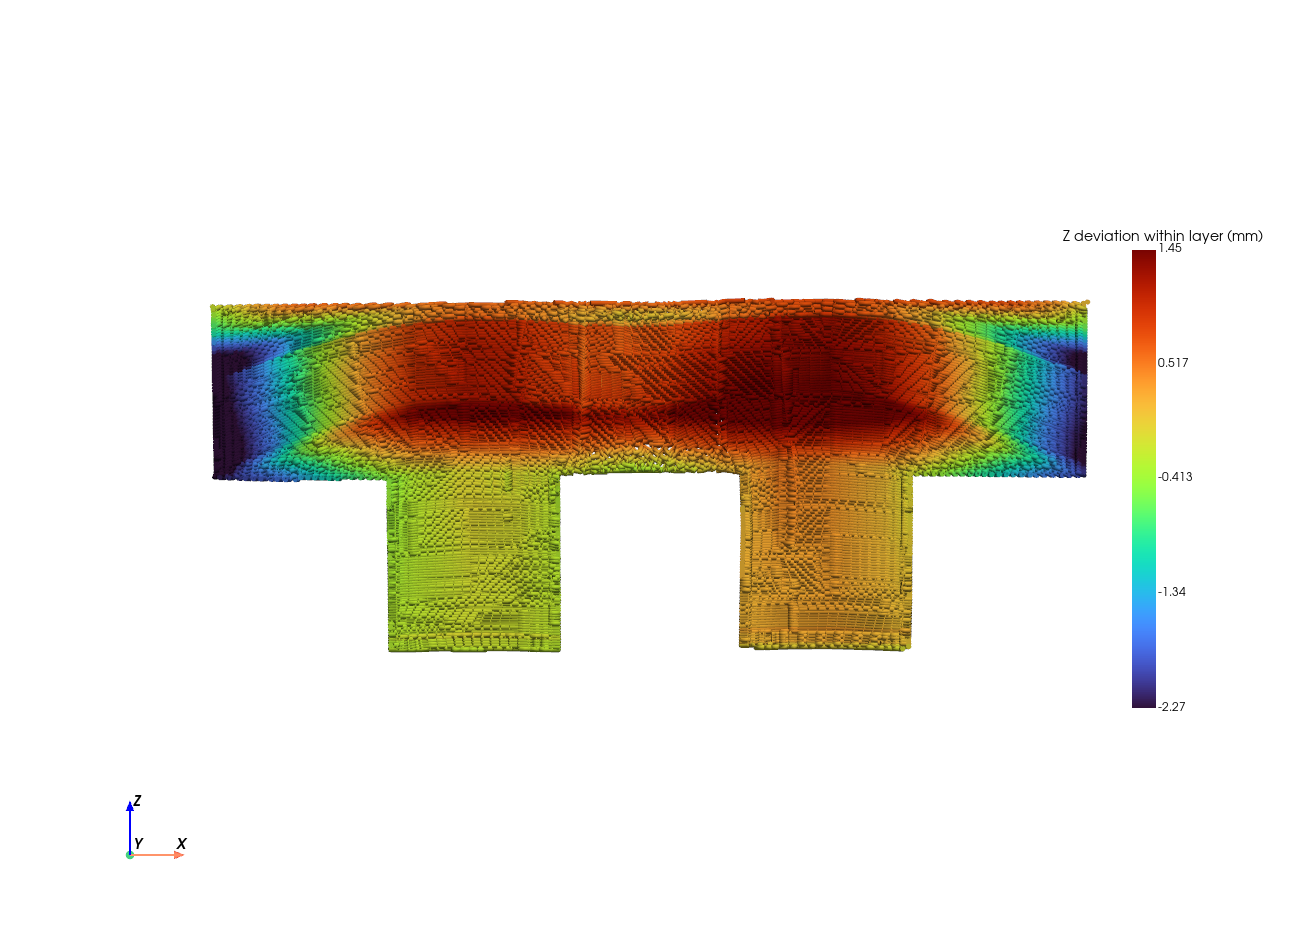

In [20]:
# =========================================================================
#  INSPECT THE REVERSED G-CODE
#  Drop-in replacement for BOTH old plotting cells.
#  (The "G-code Shifter" cell stays deleted - the transform cell shifts.)
#
#  Renders the toolpath as CONNECTED LINES, not a point cloud.  A point
#  cloud cannot show layer curvature: every bead becomes a dot and the
#  non-planar structure you are trying to see dissolves into speckle.
#
#  Start with VIEW = 'section'.  A thin slab through the part is by far the
#  clearest way to see curved layers at an overhang - you look at the layers
#  edge-on instead of through the skin.
# =========================================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- settings
VIEW = 'section'          # 'solid'   whole part
                          # 'section' thin slab, layers edge-on  <- start here
                          # 'layers'  a range of layers only

SECTION_AXIS      = 'y'   # slab normal: 'x' or 'y'
SECTION_AT        = 'densest'
                          # 'densest' -> the slab holding the most material
                          #              (the geometric middle is often a
                          #               sparse infill gap)
                          # 'middle'  -> median of the part
                          # a number  -> that coordinate, in mm
SECTION_THICKNESS = 1.2   # mm

SECTION_STYLE = 'profiles'
# 'profiles' join each LAYER's slab points into a profile curve, sorted
#            along the view axis.  This is what draws curved layers as
#            curves.  A toolpath crosses a thin slab almost perpendicularly,
#            so consecutive-point joining gives 2-point stubs, not lines.
# 'toolpath' join consecutive toolpath points (honest, but dotty)
PROFILE_GAP = 2.5         # mm; break a profile across a gap wider than this,
                          # so separate regions are not bridged

LAYER_RANGE = (0, 40)     # used when VIEW == 'layers'

COLOR_BY = 'nonplanarity'
# 'nonplanarity'  Z minus that layer's mean Z.  Flat layers go uniform,
#                 curvature shows as a colour gradient.  Best for overhangs.
# 'layer'         layer index, so adjacent layers separate visually
# 'height'        absolute Z
# 'z_bands'       Z modulo 1 mm (the old default; misleading on curved layers)
# 'feed' | 'extrusion'
# 'tier'          mapping quality: inside tet / nearest tet / IDW fallback
#                 (forces the in-memory source)

RENDER       = 'tube'     # 'tube' | 'line' | 'point'
TUBE_RADIUS  = 0.16       # mm, roughly half a bead width
LINE_WIDTH   = 2
SHOW_TRAVELS = False      # travels drawn over the part hide exactly what you
                          # are trying to look at; turn on to debug hops
ZOOM         = 1.0        # 1.0 = fit.  The camera auto-fits first, so values
                          # much above 1 crop the part off the window edges.
CLIM_PCT     = (2, 98)    # robust colour limits; a couple of outlying beads
                          # otherwise flatten the whole scale
WINDOW_SIZE  = (1300, 950)
CMAP         = 'turbo'
SKIP_MACHINE_BLOCKS = True
MAX_SEGMENTS_MPL = 60_000   # matplotlib fallback only

GCODE_PATH = globals().get('final_output_path',
                           f"output_gcode/{globals().get('model_name','model')}"
                           "_final_reversed_out.gcode")

# ------------------------------------------------------------------ parse
_WORD = re.compile(r'([A-Za-z])\s*(-?\d*\.?\d+)')
_MOTION = re.compile(r'^\s*G0*([01])(?![\d.])')
_LAYER = re.compile(r'^\s*;\s*LAYER:\s*(-?\d+)')


def points_from_file(path):
    """Replay the written file the way the firmware would.

    Also tracks the ;LAYER: index, which is what makes per-layer colouring
    and the non-planarity metric possible.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} not found. Run the reverse transform cell first, or set '
            'GCODE_PATH by hand.')

    pos, feed, layer = np.zeros(3), np.nan, -1
    recording = not SKIP_MACHINE_BLOCKS
    n_skipped = 0
    xyz, printing, feeds, extr, layers = [], [], [], [], []

    for raw in open(path):
        lm = _LAYER.match(raw)
        if lm:
            layer = int(lm.group(1))
            continue
        if not recording and 'BEGIN REVERSED REMAINING GCODE' in raw:
            recording = True
            continue
        code = raw.split(';', 1)[0]
        if not _MOTION.match(code):
            continue
        w = {k.upper(): float(v) for k, v in _WORD.findall(code)}
        if 'F' in w:
            feed = w['F']
        moved = False
        for i, ax in enumerate('XYZ'):
            if ax in w:
                pos[i] = w[ax]
                moved = True
        if not moved:
            continue                      # retraction / prime
        if not recording:
            n_skipped += 1                # still replayed: modal state stays right
            continue
        e = w.get('E')
        xyz.append(pos.copy())
        printing.append(e is not None and e > 0)
        feeds.append(feed)
        extr.append(e if e is not None else np.nan)
        layers.append(layer)

    xyz = np.array(xyz)
    printing = np.array(printing, bool)
    feeds, extr = np.array(feeds), np.array(extr)
    layers = np.array(layers)

    if SKIP_MACHINE_BLOCKS and printing.any():
        last = int(np.flatnonzero(printing)[-1])
        tail = len(xyz) - last - 1
        xyz, printing = xyz[:last + 1], printing[:last + 1]
        feeds, extr, layers = feeds[:last + 1], extr[:last + 1], layers[:last + 1]
        if n_skipped or tail:
            print(f'[info] excluded {n_skipped} start-block and {tail} end-block moves')

    return dict(xyz=xyz, printing=printing, feed=feeds, extrusion=extr,
                layer=layers, tier=None, label=path)


def points_from_memory(pts):
    tier_map = {'inside': 0, 'nearest': 1, 'idw': 2, 'skipped': 3}
    return dict(
        xyz=np.array([p['position'] for p in pts], float),
        printing=np.array([not p['travelling'] for p in pts], bool),
        feed=np.array([p['feed'] if p['feed'] is not None else np.nan for p in pts]),
        extrusion=np.array([p['extrusion'] if p['extrusion'] is not None else np.nan
                            for p in pts]),
        layer=None,
        tier=np.array([tier_map.get(p.get('tier', 'skipped'), 3) for p in pts]),
        label='new_gcode_points (in memory)')


D = points_from_memory(new_gcode_points) if COLOR_BY == 'tier' \
    else points_from_file(GCODE_PATH)

xyz, printing = D['xyz'], D['printing']

# ------------------------------------------------------------ scalar field
def build_scalars():
    if COLOR_BY == 'nonplanarity':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='nonplanarity' needs the file source "
                             "(it reads ;LAYER: markers).")
        s = np.full(len(xyz), np.nan)
        for L in np.unique(D['layer']):
            m = (D['layer'] == L) & printing
            if m.any():
                s[m] = xyz[m, 2] - xyz[m, 2].mean()
        s[~np.isfinite(s)] = 0.0          # travels: neutral, keeps array finite
        return s, 'Z deviation within layer (mm)'
    if COLOR_BY == 'layer':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='layer' needs the file source.")
        return D['layer'].astype(float), 'layer index'
    if COLOR_BY == 'height':
        return xyz[:, 2], 'Z height (mm)'
    if COLOR_BY == 'z_bands':
        return xyz[:, 2] % 1.0, 'Z modulo 1 mm'
    if COLOR_BY == 'feed':
        return D['feed'], 'feedrate (mm/min)'
    if COLOR_BY == 'extrusion':
        return D['extrusion'], 'E per move (mm)'
    if COLOR_BY == 'tier':
        return D['tier'].astype(float), 'mapping tier (0 in / 1 near / 2 idw)'
    raise ValueError(f'unknown COLOR_BY: {COLOR_BY}')


scal, scal_title = build_scalars()

# ------------------------------------------------------------------ subset
sel = np.ones(len(xyz), bool)
view_note = 'whole part'

if VIEW == 'section':
    ax_i = {'x': 0, 'y': 1}[SECTION_AXIS]
    pm = xyz[printing]
    if isinstance(SECTION_AT, (int, float)):
        at = float(SECTION_AT)
    elif SECTION_AT == 'densest' and len(pm):
        hist, edges = np.histogram(pm[:, ax_i], bins=60)
        at = float(edges[hist.argmax()] + (edges[1] - edges[0]) / 2)
    else:
        at = float(np.median(pm[:, ax_i])) if len(pm) else float(xyz[:, ax_i].mean())
    sel = np.abs(xyz[:, ax_i] - at) <= SECTION_THICKNESS / 2.0
    view_note = (f'{SECTION_THICKNESS:.2f} mm slab at {SECTION_AXIS.upper()}={at:.2f}'
                 ' (layers edge-on)')
elif VIEW == 'layers':
    if D['layer'] is None:
        raise ValueError("VIEW='layers' needs the file source.")
    lo, hi = LAYER_RANGE
    sel = (D['layer'] >= lo) & (D['layer'] <= hi)
    view_note = f'layers {lo}..{hi}'

if not sel.any():
    raise RuntimeError('Selection is empty - widen SECTION_THICKNESS or LAYER_RANGE.')

# ---------------------------------------------------------------- text QC
step = np.linalg.norm(np.diff(xyz, axis=0), axis=1) if len(xyz) > 1 else np.zeros(1)
stall = longest = 0
for d in step:
    stall = stall + 1 if d < 5e-4 else 0
    longest = max(longest, stall)

print('=' * 64)
print('  TOOLPATH INSPECTION')
print('=' * 64)
print(f'  source                 {D["label"]}')
print(f'  view                   {VIEW}  -  {view_note}')
print(f'  points                 {len(xyz)}  '
      f'({int(printing.sum())} printing, {int((~printing).sum())} travel)')
print(f'  shown                  {int(sel.sum())}')
print(f'  X / Y / Z range        {xyz[:,0].min():.2f}..{xyz[:,0].max():.2f}  '
      f'{xyz[:,1].min():.2f}..{xyz[:,1].max():.2f}  '
      f'{xyz[:,2].min():.2f}..{xyz[:,2].max():.2f} mm')
print(f'  sub-bed points         {int((xyz[:,2] < -1e-6).sum())}')
print(f'  longest stationary run {longest}')
print(f'  largest single move    {step.max():.3f} mm')
if D['layer'] is not None and printing.any():
    dev = np.array([np.ptp(xyz[(D['layer'] == L) & printing, 2])
                    for L in np.unique(D['layer'])
                    if ((D['layer'] == L) & printing).any()])
    print(f'  layer Z spread         median {np.median(dev):.3f} mm, '
          f'max {dev.max():.3f} mm   <- non-planarity')
if D['tier'] is not None:
    for nm, c in (('inside', 0), ('nearest', 1), ('idw', 2)):
        n = int((D['tier'] == c).sum())
        if n:
            print(f'  mapped via {nm:<8}   {n} ({100*n/len(D["tier"]):.2f}%)')
print('=' * 64)


# -------------------------------------------------------- polyline builder
def runs(mask):
    """Contiguous index runs where mask is True (length >= 2)."""
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []
    brk = np.flatnonzero(np.diff(idx) > 1) + 1
    return [p for p in np.split(idx, brk) if len(p) >= 2]


def layer_profiles(mask, horiz):
    """One curve per layer: slab points sorted along the view axis.

    A section cuts the toolpath almost perpendicularly, so joining
    consecutive toolpath points inside the slab yields thousands of
    two-point stubs - dots and dashes, not layers.  Sorting each layer's
    points along the horizontal axis instead reconstructs that layer's
    profile through the slab, which is the curve you want to look at.
    """
    if D['layer'] is None:
        return runs(mask)
    out = []
    for L in np.unique(D['layer'][mask]):
        idx = np.flatnonzero(mask & (D['layer'] == L))
        if len(idx) < 2:
            continue
        idx = idx[np.argsort(xyz[idx, horiz])]
        gaps = np.flatnonzero(np.diff(xyz[idx, horiz]) > PROFILE_GAP) + 1
        out += [p for p in np.split(idx, gaps) if len(p) >= 2]
    return out


def draw_runs(mask):
    """Runs to draw, honouring SECTION_STYLE."""
    if VIEW == 'section' and SECTION_STYLE == 'profiles':
        return layer_profiles(mask, 0 if SECTION_AXIS == 'y' else 1)
    return runs(mask)


def polydata(mask, scalars=None):
    """One PolyData holding every run as a VTK polyline cell.

    Building lines rather than points is the whole point: a bead becomes a
    continuous stroke that follows the surface, so a curved layer reads as a
    curve instead of as a band of dots.
    """
    import pyvista as pv
    pieces = draw_runs(mask)
    if not pieces:
        return None
    pts, cells, vals, off = [], [], [], 0
    for p in pieces:
        pts.append(xyz[p])
        cells.append(np.concatenate(([len(p)], np.arange(len(p)) + off)))
        if scalars is not None:
            vals.append(scalars[p])
        off += len(p)
    poly = pv.PolyData(np.vstack(pts))
    poly.lines = np.concatenate(cells)
    if scalars is not None:
        poly.point_data[scal_title] = np.concatenate(vals)
    return poly


_pieces = draw_runs(printing & sel)
print(f'  curves drawn           {len(_pieces)}  '
      f'(median {int(np.median([len(r) for r in _pieces])) if _pieces else 0} points each)')
if VIEW == 'section' and SECTION_STYLE == 'toolpath':
    print("  note: SECTION_STYLE='toolpath' gives short stubs; "
          "'profiles' joins each layer")
print('=' * 64)

# ------------------------------------------------------------------- plot
plotted = False
try:
    import pyvista as pv

    body = polydata(printing & sel, scal)
    if body is None:
        raise RuntimeError('nothing to draw')

    pl = pv.Plotter(window_size=list(WINDOW_SIZE))
    mesh = body.tube(radius=TUBE_RADIUS, n_sides=8) if RENDER == 'tube' else body

    finite = scal[np.isfinite(scal)]
    clim = ([float(np.percentile(finite, CLIM_PCT[0])),
             float(np.percentile(finite, CLIM_PCT[1]))] if len(finite) else None)
    if clim and clim[0] == clim[1]:
        clim = None

    kw = dict(scalars=scal_title, cmap=CMAP, clim=clim,
              scalar_bar_args=dict(title=scal_title, vertical=True,
                                   position_x=0.87, position_y=0.25,
                                   height=0.5, width=0.05,
                                   title_font_size=14, label_font_size=12,
                                   color='black'))
    if RENDER == 'point':
        kw.update(style='points', point_size=4)
    elif RENDER == 'line':
        kw.update(line_width=LINE_WIDTH)
    else:
        kw.update(smooth_shading=True)
    pl.add_mesh(mesh, **kw)

    if SHOW_TRAVELS:
        tv = polydata((~printing) & sel)
        if tv is not None:
            pl.add_mesh(tv, color='red', line_width=1, opacity=0.35)

    # --- camera -----------------------------------------------------------
    # cpos alone only sets a direction.  Without reset_camera + zoom the part
    # ends up as a speck in the middle of a mostly empty window.
    if VIEW == 'section':
        pl.view_xz() if SECTION_AXIS == 'y' else pl.view_yz()
        pl.enable_parallel_projection()      # true edge-on, no perspective skew
    else:
        pl.camera_position = [(-0.5, -1.0, 0.5), (0, 0, 0), (0, 0, 1)]
    pl.reset_camera()          # fit first...
    if ZOOM != 1.0:
        pl.camera.zoom(ZOOM)   # ...then zoom only if asked
    pl.set_background('white')
    pl.add_axes(color='black')
    pl.show()
    plotted = True

except Exception as exc:
    print(f'[info] PyVista path unavailable ({exc.__class__.__name__}: {exc}); '
          'using matplotlib')

if not plotted:
    # ---------------- matplotlib fallback -------------------------------
    from matplotlib.collections import LineCollection
    from mpl_toolkits.mplot3d.art3d import Line3DCollection

    pieces = draw_runs(printing & sel)
    segs = [np.stack([xyz[p[:-1]], xyz[p[1:]]], axis=1) for p in pieces]
    sv = [0.5 * (scal[p[:-1]] + scal[p[1:]]) for p in pieces]
    segs = np.concatenate(segs) if segs else np.empty((0, 2, 3))
    sv = np.concatenate(sv) if sv else np.empty(0)
    if len(segs) > MAX_SEGMENTS_MPL:
        k = np.linspace(0, len(segs) - 1, MAX_SEGMENTS_MPL).astype(int)
        segs, sv = segs[k], sv[k]
        print(f'[info] matplotlib: subsampled to {MAX_SEGMENTS_MPL} segments')

    P = xyz[sel]

    if VIEW == 'section':
        # A section is edge-on by definition, so draw it flat.  A 3D axes
        # here spends most of the canvas on empty space around a picture that
        # has no depth in it anyway - which is what made the first render
        # look like a stamp in the corner of a page.
        h = 0 if SECTION_AXIS == 'y' else 1          # horizontal axis index
        fig, ax = plt.subplots(figsize=(13, 7))
        lc = LineCollection(segs[:, :, [h, 2]], cmap=CMAP, linewidths=1.2)
        lc.set_array(sv)
        if len(sv):
            lc.set_clim(np.percentile(sv, CLIM_PCT[0]),
                        np.percentile(sv, CLIM_PCT[1]))
        ax.add_collection(lc)
        fig.colorbar(lc, ax=ax, shrink=0.85, label=scal_title)
        if SHOW_TRAVELS:
            for p in runs((~printing) & sel):
                ax.plot(xyz[p, h], xyz[p, 2], color='red', lw=0.3, alpha=0.3)
        ax.set_xlim(P[:, h].min() - 1, P[:, h].max() + 1)
        ax.set_ylim(P[:, 2].min() - 1, P[:, 2].max() + 1)
        ax.set_aspect('equal')          # 1 mm in Z looks like 1 mm across
        ax.set_xlabel(f'{"XY"[h]} (mm)')
        ax.set_ylabel('Z (mm)')
        ax.grid(alpha=0.25, lw=0.4)
        ax.set_title(f'{view_note}\n{scal_title}')
    else:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')
        lc = Line3DCollection(segs, cmap=CMAP, linewidths=1.0)
        lc.set_array(sv)
        ax.add_collection3d(lc)
        fig.colorbar(lc, ax=ax, shrink=0.6, label=scal_title)
        if SHOW_TRAVELS:
            for p in runs((~printing) & sel):
                ax.plot(xyz[p, 0], xyz[p, 1], xyz[p, 2],
                        color='red', lw=0.3, alpha=0.3)
        for setter, lo, hi in ((ax.set_xlim, P[:, 0].min(), P[:, 0].max()),
                               (ax.set_ylim, P[:, 1].min(), P[:, 1].max()),
                               (ax.set_zlim, P[:, 2].min(), P[:, 2].max())):
            pad = max((hi - lo) * 0.05, 0.2)
            setter(lo - pad, hi + pad)
        ax.set_box_aspect((max(np.ptp(P[:, 0]), 1e-6),
                           max(np.ptp(P[:, 1]), 1e-6),
                           max(np.ptp(P[:, 2]), 1e-6)))
        ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
        ax.set_title(f'{VIEW}  -  {view_note}\n{scal_title}')

    plt.tight_layout()
    plt.show()


[info] excluded 6 start-block and 1 end-block moves
  TOOLPATH INSPECTION
  source                 output_gcode/pi 3mm_final_reversed_out.gcode
  view                   section  -  0.60 mm slab at Y=94.38 (layers edge-on)
  points                 103139  (86718 printing, 16421 travel)
  shown                  12529
  X / Y / Z range        40.00..125.07  3.00..95.31  0.00..23.15 mm
  sub-bed points         0
  longest stationary run 0
  largest single move    112.242 mm
  layer spacing (median)  0.148 mm
  layer Z spread         median 1.118 mm, max 4.538 mm   <- non-planarity
  curves drawn           244  (median 21 points each)


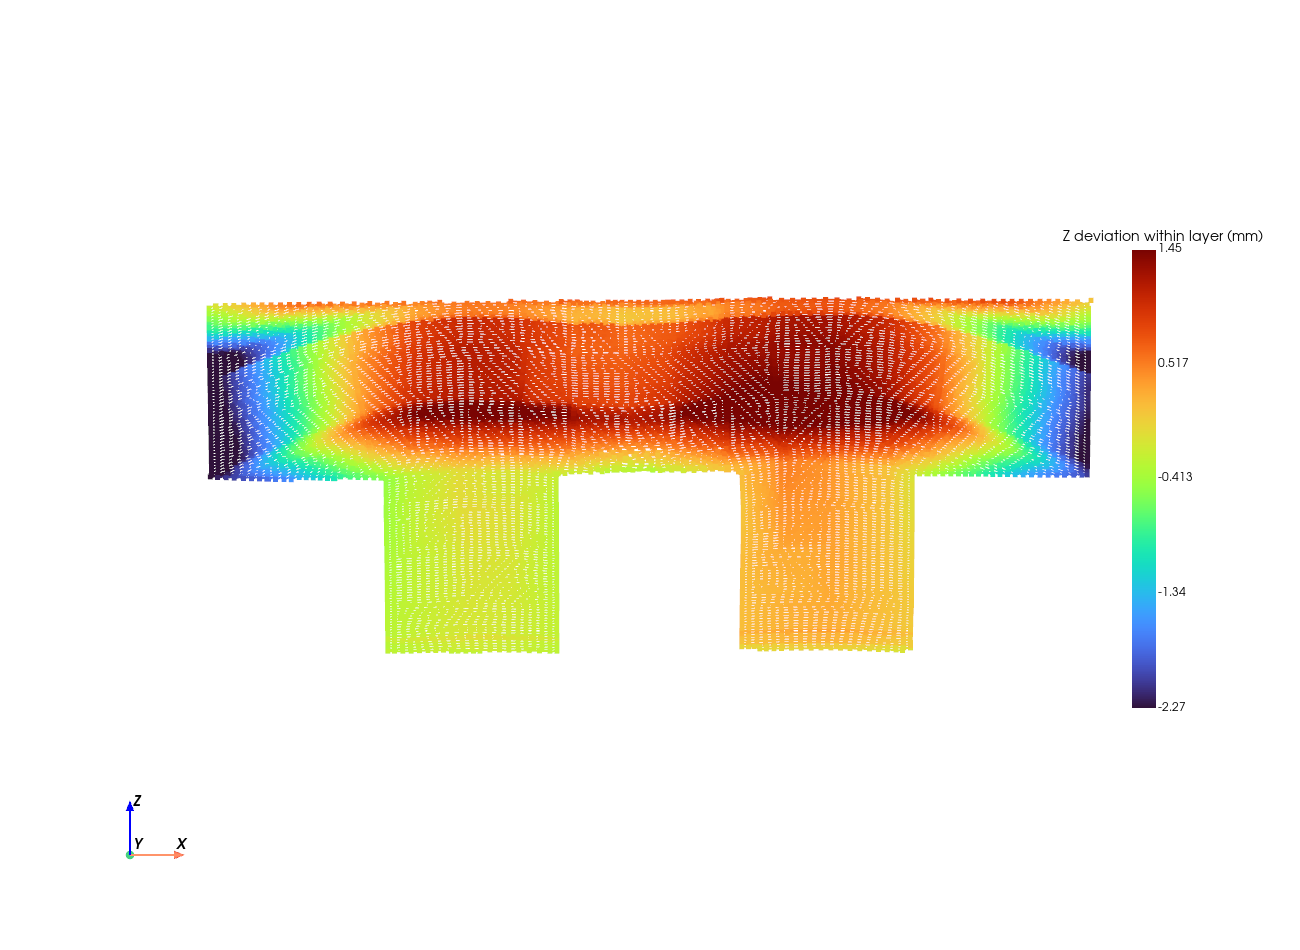

In [21]:
# =========================================================================
#  INSPECT THE REVERSED G-CODE
#  Drop-in replacement for BOTH old plotting cells.
#  (The "G-code Shifter" cell stays deleted - the transform cell shifts.)
#
#  Renders the toolpath as CONNECTED LINES, not a point cloud.  A point
#  cloud cannot show layer curvature: every bead becomes a dot and the
#  non-planar structure you are trying to see dissolves into speckle.
#
#  Start with VIEW = 'section'.  A thin slab through the part is by far the
#  clearest way to see curved layers at an overhang - you look at the layers
#  edge-on instead of through the skin.
# =========================================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- settings
VIEW = 'section'          # 'solid'   whole part
                          # 'section' thin slab, layers edge-on  <- start here
                          # 'layers'  a range of layers only

SECTION_AXIS      = 'y'   # slab normal: 'x' or 'y'
SECTION_AT        = 'densest'
                          # 'densest' -> the slab holding the most material
                          #              (the geometric middle is often a
                          #               sparse infill gap)
                          # 'middle'  -> median of the part
                          # a number  -> that coordinate, in mm
SECTION_THICKNESS = 0.6   # mm.  Wider slabs stack several beads on top of
                          # each other and the layer profiles smear together.

SECTION_STYLE = 'profiles'
# 'profiles' join each LAYER's slab points into a profile curve, sorted
#            along the view axis.  This is what draws curved layers as
#            curves.  A toolpath crosses a thin slab almost perpendicularly,
#            so consecutive-point joining gives 2-point stubs, not lines.
# 'toolpath' join consecutive toolpath points (honest, but dotty)
PROFILE_GAP = 2.5         # mm; break a profile across a gap wider than this,
                          # so separate regions are not bridged

LAYER_RANGE  = (0, 40)    # used when VIEW == 'layers'
LAYER_STRIDE = 1          # draw every Nth layer.  Set 2-4 to open up gaps
                          # between layers when they are too dense to read.

CAMERA = 'auto'           # 'auto'  edge-on for a section, isometric otherwise
                          # 'iso'   isometric
                          # 'front' look along -Y   |  'side' along -X
                          # 'top'   look down -Z

COLOR_BY = 'nonplanarity'
# 'layer_parity'  alternating two colours, one per layer.  Nothing separates
#                 stacked layers as clearly; use it whenever you want to
#                 count layers or check they are not merging.
# 'nonplanarity'  Z minus that layer's mean Z.  Flat layers go uniform,
#                 curvature shows as a colour gradient.  Best for overhangs.
# 'layer'         layer index, so adjacent layers separate visually
# 'height'        absolute Z
# 'z_bands'       Z modulo 1 mm (the old default; misleading on curved layers)
# 'feed' | 'extrusion'
# 'tier'          mapping quality: inside tet / nearest tet / IDW fallback
#                 (forces the in-memory source)

RENDER       = 'auto'     # 'auto' -> lines for a section, tubes otherwise
                          # 'tube' | 'line' | 'point'
TUBE_RADIUS  = 'auto'     # 'auto' -> 0.3 x the measured layer spacing, so
                          # neighbouring layers stay visually separate.  A
                          # fixed radius larger than half the layer height
                          # fuses the whole part into one solid block.
LINE_WIDTH   = 2
SHOW_TRAVELS = False      # travels drawn over the part hide exactly what you
                          # are trying to look at; turn on to debug hops
ZOOM         = 1.0        # 1.0 = fit.  The camera auto-fits first, so values
                          # much above 1 crop the part off the window edges.
CLIM_PCT     = (2, 98)    # robust colour limits; a couple of outlying beads
                          # otherwise flatten the whole scale
WINDOW_SIZE  = (1300, 950)
CMAP         = 'turbo'
SKIP_MACHINE_BLOCKS = True
MAX_SEGMENTS_MPL = 60_000   # matplotlib fallback only

GCODE_PATH = globals().get('final_output_path',
                           f"output_gcode/{globals().get('model_name','model')}"
                           "_final_reversed_out.gcode")

# ------------------------------------------------------------------ parse
_WORD = re.compile(r'([A-Za-z])\s*(-?\d*\.?\d+)')
_MOTION = re.compile(r'^\s*G0*([01])(?![\d.])')
_LAYER = re.compile(r'^\s*;\s*LAYER:\s*(-?\d+)')


def points_from_file(path):
    """Replay the written file the way the firmware would.

    Also tracks the ;LAYER: index, which is what makes per-layer colouring
    and the non-planarity metric possible.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} not found. Run the reverse transform cell first, or set '
            'GCODE_PATH by hand.')

    pos, feed, layer = np.zeros(3), np.nan, -1
    recording = not SKIP_MACHINE_BLOCKS
    n_skipped = 0
    xyz, printing, feeds, extr, layers = [], [], [], [], []

    for raw in open(path):
        lm = _LAYER.match(raw)
        if lm:
            layer = int(lm.group(1))
            continue
        if not recording and 'BEGIN REVERSED REMAINING GCODE' in raw:
            recording = True
            continue
        code = raw.split(';', 1)[0]
        if not _MOTION.match(code):
            continue
        w = {k.upper(): float(v) for k, v in _WORD.findall(code)}
        if 'F' in w:
            feed = w['F']
        moved = False
        for i, ax in enumerate('XYZ'):
            if ax in w:
                pos[i] = w[ax]
                moved = True
        if not moved:
            continue                      # retraction / prime
        if not recording:
            n_skipped += 1                # still replayed: modal state stays right
            continue
        e = w.get('E')
        xyz.append(pos.copy())
        printing.append(e is not None and e > 0)
        feeds.append(feed)
        extr.append(e if e is not None else np.nan)
        layers.append(layer)

    xyz = np.array(xyz)
    printing = np.array(printing, bool)
    feeds, extr = np.array(feeds), np.array(extr)
    layers = np.array(layers)

    if SKIP_MACHINE_BLOCKS and printing.any():
        last = int(np.flatnonzero(printing)[-1])
        tail = len(xyz) - last - 1
        xyz, printing = xyz[:last + 1], printing[:last + 1]
        feeds, extr, layers = feeds[:last + 1], extr[:last + 1], layers[:last + 1]
        if n_skipped or tail:
            print(f'[info] excluded {n_skipped} start-block and {tail} end-block moves')

    return dict(xyz=xyz, printing=printing, feed=feeds, extrusion=extr,
                layer=layers, tier=None, label=path)


def points_from_memory(pts):
    tier_map = {'inside': 0, 'nearest': 1, 'idw': 2, 'skipped': 3}
    return dict(
        xyz=np.array([p['position'] for p in pts], float),
        printing=np.array([not p['travelling'] for p in pts], bool),
        feed=np.array([p['feed'] if p['feed'] is not None else np.nan for p in pts]),
        extrusion=np.array([p['extrusion'] if p['extrusion'] is not None else np.nan
                            for p in pts]),
        layer=None,
        tier=np.array([tier_map.get(p.get('tier', 'skipped'), 3) for p in pts]),
        label='new_gcode_points (in memory)')


D = points_from_memory(new_gcode_points) if COLOR_BY == 'tier' \
    else points_from_file(GCODE_PATH)

xyz, printing = D['xyz'], D['printing']

# ------------------------------------------------------------ scalar field
def build_scalars():
    if COLOR_BY == 'nonplanarity':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='nonplanarity' needs the file source "
                             "(it reads ;LAYER: markers).")
        s = np.full(len(xyz), np.nan)
        for L in np.unique(D['layer']):
            m = (D['layer'] == L) & printing
            if m.any():
                s[m] = xyz[m, 2] - xyz[m, 2].mean()
        s[~np.isfinite(s)] = 0.0          # travels: neutral, keeps array finite
        return s, 'Z deviation within layer (mm)'
    if COLOR_BY == 'layer_parity':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='layer_parity' needs the file source.")
        return (D['layer'] % 2).astype(float), 'alternating layers'
    if COLOR_BY == 'layer':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='layer' needs the file source.")
        return D['layer'].astype(float), 'layer index'
    if COLOR_BY == 'height':
        return xyz[:, 2], 'Z height (mm)'
    if COLOR_BY == 'z_bands':
        return xyz[:, 2] % 1.0, 'Z modulo 1 mm'
    if COLOR_BY == 'feed':
        return D['feed'], 'feedrate (mm/min)'
    if COLOR_BY == 'extrusion':
        return D['extrusion'], 'E per move (mm)'
    if COLOR_BY == 'tier':
        return D['tier'].astype(float), 'mapping tier (0 in / 1 near / 2 idw)'
    raise ValueError(f'unknown COLOR_BY: {COLOR_BY}')


scal, scal_title = build_scalars()

# Measured layer spacing drives the auto tube radius and is worth printing:
# if it is larger than your nominal layer height the deformation is
# stretching the part in Z.
LAYER_DZ = 0.2
if D['layer'] is not None and printing.any():
    zs = [xyz[(D['layer'] == L) & printing, 2].mean()
          for L in np.unique(D['layer']) if ((D['layer'] == L) & printing).any()]
    if len(zs) > 2:
        LAYER_DZ = float(np.median(np.diff(zs)))

# ------------------------------------------------------------------ subset
sel = np.ones(len(xyz), bool)
view_note = 'whole part'

if VIEW == 'section':
    ax_i = {'x': 0, 'y': 1}[SECTION_AXIS]
    pm = xyz[printing]
    if isinstance(SECTION_AT, (int, float)):
        at = float(SECTION_AT)
    elif SECTION_AT == 'densest' and len(pm):
        hist, edges = np.histogram(pm[:, ax_i], bins=60)
        at = float(edges[hist.argmax()] + (edges[1] - edges[0]) / 2)
    else:
        at = float(np.median(pm[:, ax_i])) if len(pm) else float(xyz[:, ax_i].mean())
    sel = np.abs(xyz[:, ax_i] - at) <= SECTION_THICKNESS / 2.0
    view_note = (f'{SECTION_THICKNESS:.2f} mm slab at {SECTION_AXIS.upper()}={at:.2f}'
                 ' (layers edge-on)')
elif VIEW == 'layers':
    if D['layer'] is None:
        raise ValueError("VIEW='layers' needs the file source.")
    lo, hi = LAYER_RANGE
    sel = (D['layer'] >= lo) & (D['layer'] <= hi)
    view_note = f'layers {lo}..{hi}'

if LAYER_STRIDE > 1 and D['layer'] is not None:
    sel &= (D['layer'] % LAYER_STRIDE == 0)
    view_note += f', every {LAYER_STRIDE}th layer'

if not sel.any():
    raise RuntimeError('Selection is empty - widen SECTION_THICKNESS or LAYER_RANGE.')

# ---------------------------------------------------------------- text QC
step = np.linalg.norm(np.diff(xyz, axis=0), axis=1) if len(xyz) > 1 else np.zeros(1)
stall = longest = 0
for d in step:
    stall = stall + 1 if d < 5e-4 else 0
    longest = max(longest, stall)

print('=' * 64)
print('  TOOLPATH INSPECTION')
print('=' * 64)
print(f'  source                 {D["label"]}')
print(f'  view                   {VIEW}  -  {view_note}')
print(f'  points                 {len(xyz)}  '
      f'({int(printing.sum())} printing, {int((~printing).sum())} travel)')
print(f'  shown                  {int(sel.sum())}')
print(f'  X / Y / Z range        {xyz[:,0].min():.2f}..{xyz[:,0].max():.2f}  '
      f'{xyz[:,1].min():.2f}..{xyz[:,1].max():.2f}  '
      f'{xyz[:,2].min():.2f}..{xyz[:,2].max():.2f} mm')
print(f'  sub-bed points         {int((xyz[:,2] < -1e-6).sum())}')
print(f'  longest stationary run {longest}')
print(f'  largest single move    {step.max():.3f} mm')
print(f'  layer spacing (median)  {LAYER_DZ:.3f} mm')
if D['layer'] is not None and printing.any():
    dev = np.array([np.ptp(xyz[(D['layer'] == L) & printing, 2])
                    for L in np.unique(D['layer'])
                    if ((D['layer'] == L) & printing).any()])
    print(f'  layer Z spread         median {np.median(dev):.3f} mm, '
          f'max {dev.max():.3f} mm   <- non-planarity')
if D['tier'] is not None:
    for nm, c in (('inside', 0), ('nearest', 1), ('idw', 2)):
        n = int((D['tier'] == c).sum())
        if n:
            print(f'  mapped via {nm:<8}   {n} ({100*n/len(D["tier"]):.2f}%)')
print('=' * 64)


# -------------------------------------------------------- polyline builder
def runs(mask):
    """Contiguous index runs where mask is True (length >= 2)."""
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []
    brk = np.flatnonzero(np.diff(idx) > 1) + 1
    return [p for p in np.split(idx, brk) if len(p) >= 2]


def layer_profiles(mask, horiz):
    """One curve per layer: slab points sorted along the view axis.

    A section cuts the toolpath almost perpendicularly, so joining
    consecutive toolpath points inside the slab yields thousands of
    two-point stubs - dots and dashes, not layers.  Sorting each layer's
    points along the horizontal axis instead reconstructs that layer's
    profile through the slab, which is the curve you want to look at.
    """
    if D['layer'] is None:
        return runs(mask)
    out = []
    for L in np.unique(D['layer'][mask]):
        idx = np.flatnonzero(mask & (D['layer'] == L))
        if len(idx) < 2:
            continue
        idx = idx[np.argsort(xyz[idx, horiz])]
        gaps = np.flatnonzero(np.diff(xyz[idx, horiz]) > PROFILE_GAP) + 1
        out += [p for p in np.split(idx, gaps) if len(p) >= 2]
    return out


def draw_runs(mask):
    """Runs to draw, honouring SECTION_STYLE."""
    if VIEW == 'section' and SECTION_STYLE == 'profiles':
        return layer_profiles(mask, 0 if SECTION_AXIS == 'y' else 1)
    return runs(mask)


def polydata(mask, scalars=None):
    """One PolyData holding every run as a VTK polyline cell.

    Building lines rather than points is the whole point: a bead becomes a
    continuous stroke that follows the surface, so a curved layer reads as a
    curve instead of as a band of dots.
    """
    import pyvista as pv
    pieces = draw_runs(mask)
    if not pieces:
        return None
    pts, cells, vals, off = [], [], [], 0
    for p in pieces:
        pts.append(xyz[p])
        cells.append(np.concatenate(([len(p)], np.arange(len(p)) + off)))
        if scalars is not None:
            vals.append(scalars[p])
        off += len(p)
    poly = pv.PolyData(np.vstack(pts))
    poly.lines = np.concatenate(cells)
    if scalars is not None:
        poly.point_data[scal_title] = np.concatenate(vals)
    return poly


_pieces = draw_runs(printing & sel)
print(f'  curves drawn           {len(_pieces)}  '
      f'(median {int(np.median([len(r) for r in _pieces])) if _pieces else 0} points each)')
if VIEW == 'section' and SECTION_STYLE == 'toolpath':
    print("  note: SECTION_STYLE='toolpath' gives short stubs; "
          "'profiles' joins each layer")
print('=' * 64)

# ------------------------------------------------- resolved render settings
_flat_section = (VIEW == 'section' and CAMERA in ('auto', 'front', 'side'))
_render = RENDER
if _render == 'auto':
    _render = 'line' if _flat_section else 'tube'
_radius = (0.3 * LAYER_DZ) if TUBE_RADIUS == 'auto' else float(TUBE_RADIUS)
if _render == 'tube' and _radius > 0.5 * LAYER_DZ:
    print(f'  [warn] tube radius {_radius:.3f} mm exceeds half the layer spacing '
          f'({LAYER_DZ:.3f} mm); layers will visually merge')

_cmap = CMAP
if COLOR_BY == 'layer_parity':
    _cmap = ['#1f4e9c', '#e8871a']

# ------------------------------------------------------------------- plot
plotted = False
try:
    import pyvista as pv

    body = polydata(printing & sel, scal)
    if body is None:
        raise RuntimeError('nothing to draw')

    pl = pv.Plotter(window_size=list(WINDOW_SIZE))
    mesh = body.tube(radius=_radius, n_sides=8) if _render == 'tube' else body

    finite = scal[np.isfinite(scal)]
    clim = ([float(np.percentile(finite, CLIM_PCT[0])),
             float(np.percentile(finite, CLIM_PCT[1]))] if len(finite) else None)
    if clim and clim[0] == clim[1]:
        clim = None

    kw = dict(scalars=scal_title, cmap=_cmap, clim=clim,
              show_scalar_bar=(COLOR_BY != 'layer_parity'),
              scalar_bar_args=dict(title=scal_title, vertical=True,
                                   position_x=0.87, position_y=0.25,
                                   height=0.5, width=0.05,
                                   title_font_size=14, label_font_size=12,
                                   color='black'))
    if _render == 'point':
        kw.update(style='points', point_size=4)
    elif _render == 'line':
        kw.update(line_width=LINE_WIDTH)
    else:
        kw.update(smooth_shading=True)
    pl.add_mesh(mesh, **kw)

    if SHOW_TRAVELS:
        tv = polydata((~printing) & sel)
        if tv is not None:
            pl.add_mesh(tv, color='red', line_width=1, opacity=0.35)

    # --- camera -----------------------------------------------------------
    # cpos alone only sets a direction.  Without reset_camera + zoom the part
    # ends up as a speck in the middle of a mostly empty window.
    cam = CAMERA
    if cam == 'auto':
        cam = 'front' if VIEW == 'section' else 'iso'
    if cam == 'iso':
        pl.view_isometric()
    elif cam == 'front':
        pl.view_xz() if SECTION_AXIS == 'y' else pl.view_yz()
        pl.enable_parallel_projection()   # true edge-on, no perspective skew
    elif cam == 'side':
        pl.view_yz() if SECTION_AXIS == 'y' else pl.view_xz()
        pl.enable_parallel_projection()
    elif cam == 'top':
        pl.view_xy()
    else:
        raise ValueError(f'unknown CAMERA: {CAMERA}')
    pl.reset_camera()          # fit first...
    if ZOOM != 1.0:
        pl.camera.zoom(ZOOM)   # ...then zoom only if asked
    pl.set_background('white')
    pl.add_axes(color='black')
    pl.show()
    plotted = True

except Exception as exc:
    print(f'[info] PyVista path unavailable ({exc.__class__.__name__}: {exc}); '
          'using matplotlib')

if not plotted:
    # ---------------- matplotlib fallback -------------------------------
    from matplotlib.collections import LineCollection
    from mpl_toolkits.mplot3d.art3d import Line3DCollection

    pieces = draw_runs(printing & sel)
    segs = [np.stack([xyz[p[:-1]], xyz[p[1:]]], axis=1) for p in pieces]
    sv = [0.5 * (scal[p[:-1]] + scal[p[1:]]) for p in pieces]
    segs = np.concatenate(segs) if segs else np.empty((0, 2, 3))
    sv = np.concatenate(sv) if sv else np.empty(0)
    if len(segs) > MAX_SEGMENTS_MPL:
        k = np.linspace(0, len(segs) - 1, MAX_SEGMENTS_MPL).astype(int)
        segs, sv = segs[k], sv[k]
        print(f'[info] matplotlib: subsampled to {MAX_SEGMENTS_MPL} segments')

    # Frame on PRINTED geometry only.  A single travel leg from the purge
    # position otherwise sets the axes and shrinks the part to a speck in the
    # corner - the same failure the fixed camera zoom had.
    P = xyz[sel & printing]
    if not len(P):
        P = xyz[sel]

    if COLOR_BY == 'layer_parity':
        from matplotlib.colors import ListedColormap
        mpl_cmap = ListedColormap(_cmap)
    else:
        mpl_cmap = CMAP

    if _flat_section:
        # A section viewed edge-on has no depth, so draw it flat.  A 3D axes
        # here spends most of the canvas on empty space around a picture that
        # has no depth in it anyway - which is what made the first render
        # look like a stamp in the corner of a page.
        h = 0 if SECTION_AXIS == 'y' else 1          # horizontal axis index
        fig, ax = plt.subplots(figsize=(13, 7))
        lc = LineCollection(segs[:, :, [h, 2]], cmap=mpl_cmap, linewidths=1.2)
        lc.set_array(sv)
        if len(sv):
            lc.set_clim(np.percentile(sv, CLIM_PCT[0]),
                        np.percentile(sv, CLIM_PCT[1]))
        ax.add_collection(lc)
        if COLOR_BY != 'layer_parity':
            fig.colorbar(lc, ax=ax, shrink=0.85, label=scal_title)
        if SHOW_TRAVELS:
            for p in runs((~printing) & sel):
                ax.plot(xyz[p, h], xyz[p, 2], color='red', lw=0.3, alpha=0.3)
        ax.set_xlim(P[:, h].min() - 1, P[:, h].max() + 1)
        ax.set_ylim(P[:, 2].min() - 1, P[:, 2].max() + 1)
        ax.set_aspect('equal')          # 1 mm in Z looks like 1 mm across
        ax.set_xlabel(f'{"XY"[h]} (mm)')
        ax.set_ylabel('Z (mm)')
        ax.grid(alpha=0.25, lw=0.4)
        ax.set_title(f'{view_note}\n{scal_title}')
    else:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')
        lc = Line3DCollection(segs, cmap=mpl_cmap, linewidths=1.0)
        lc.set_array(sv)
        ax.add_collection3d(lc)
        if COLOR_BY != 'layer_parity':
            fig.colorbar(lc, ax=ax, shrink=0.6, label=scal_title)
        if SHOW_TRAVELS:
            for p in runs((~printing) & sel):
                ax.plot(xyz[p, 0], xyz[p, 1], xyz[p, 2],
                        color='red', lw=0.3, alpha=0.3)
        for setter, lo, hi in ((ax.set_xlim, P[:, 0].min(), P[:, 0].max()),
                               (ax.set_ylim, P[:, 1].min(), P[:, 1].max()),
                               (ax.set_zlim, P[:, 2].min(), P[:, 2].max())):
            pad = max((hi - lo) * 0.05, 0.2)
            setter(lo - pad, hi + pad)
        ax.set_box_aspect((max(np.ptp(P[:, 0]), 1e-6),
                           max(np.ptp(P[:, 1]), 1e-6),
                           max(np.ptp(P[:, 2]), 1e-6)))
        cam = CAMERA if CAMERA != 'auto' else 'iso'
        if cam == 'iso':
            ax.view_init(elev=22, azim=-55)
        elif cam == 'front':
            ax.view_init(elev=0, azim=-90)
        elif cam == 'side':
            ax.view_init(elev=0, azim=0)
        elif cam == 'top':
            ax.view_init(elev=90, azim=-90)
        ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
        ax.set_title(f'{VIEW} / {cam}  -  {view_note}\n{scal_title}')

    plt.tight_layout()
    plt.show()


[info] excluded 6 start-block and 1 end-block moves
  TOOLPATH INSPECTION
  source                 output_gcode/pi 3mm_final_reversed_out.gcode
  view                   solid  -  whole part
  points                 103139  (86718 printing, 16421 travel)
  shown                  103139
  X / Y / Z range        40.00..125.07  3.00..95.31  0.00..23.15 mm
  sub-bed points         0
  longest stationary run 0
  largest single move    112.242 mm
  layer spacing (median)  0.148 mm
  layer Z spread         median 1.118 mm, max 4.538 mm   <- non-planarity
  curves drawn           3833  (median 9 points each)


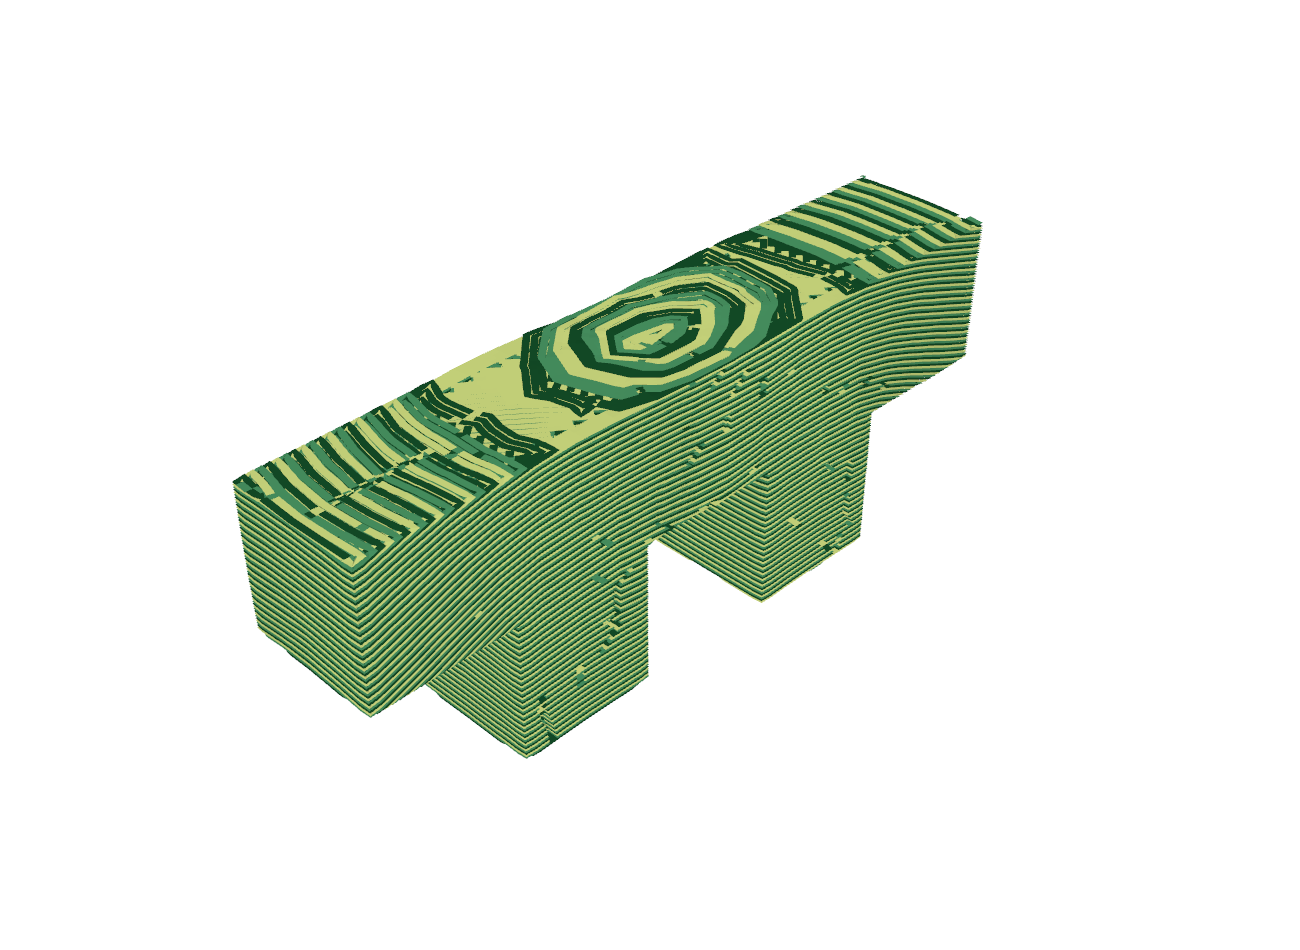

In [22]:
# =========================================================================
#  INSPECT THE REVERSED G-CODE
#  Drop-in replacement for BOTH old plotting cells.
#  (The "G-code Shifter" cell stays deleted - the transform cell shifts.)
#
#  Renders the toolpath as CONNECTED LINES, not a point cloud.  A point
#  cloud cannot show layer curvature: every bead becomes a dot and the
#  non-planar structure you are trying to see dissolves into speckle.
#
#  Start with VIEW = 'section'.  A thin slab through the part is by far the
#  clearest way to see curved layers at an overhang - you look at the layers
#  edge-on instead of through the skin.
# =========================================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- settings
VIEW = 'solid'            # 'solid'   whole part, layers wrap the surface as
                          #           contour bands  <- deposition view
                          # 'section' thin slab, layers edge-on
                          # 'layers'  a range of layers only

SECTION_AXIS      = 'y'   # slab normal: 'x' or 'y'
SECTION_AT        = 'densest'
                          # 'densest' -> the slab holding the most material
                          #              (the geometric middle is often a
                          #               sparse infill gap)
                          # 'middle'  -> median of the part
                          # a number  -> that coordinate, in mm
SECTION_THICKNESS = 0.6   # mm.  Wider slabs stack several beads on top of
                          # each other and the layer profiles smear together.

SECTION_STYLE = 'profiles'
# 'profiles' join each LAYER's slab points into a profile curve, sorted
#            along the view axis.  This is what draws curved layers as
#            curves.  A toolpath crosses a thin slab almost perpendicularly,
#            so consecutive-point joining gives 2-point stubs, not lines.
# 'toolpath' join consecutive toolpath points (honest, but dotty)
PROFILE_GAP = 2.5         # mm; break a profile across a gap wider than this,
                          # so separate regions are not bridged

LAYER_CYCLE  = 3          # how many colours before the palette repeats
LAYER_COLORS = ['#14532d', '#4c9f70', '#d9ed92']   # dark -> light green
                          # 2 colours gives a stripe, 3-5 a contour-map look

LAYER_RANGE  = (0, 40)    # used when VIEW == 'layers'
LAYER_STRIDE = 1          # draw every Nth layer.  Set 2-4 to open up gaps
                          # between layers when they are too dense to read.

CAMERA = 'iso'            # 'auto'  edge-on for a section, isometric otherwise
                          # 'iso'   isometric
                          # 'front' look along -Y   |  'side' along -X
                          # 'top'   look down -Z

COLOR_BY = 'layer_cycle'
# 'layer_cycle'   cycles a short palette through the layer index, so every
#                 layer differs from its neighbours and the colour repeats
#                 every LAYER_CYCLE layers.  Because the ;LAYER: markers are
#                 carried through untouched, the layer index IS the strand's
#                 Z height BEFORE the inverse deformation - so one colour band
#                 marks one original flat layer, wherever the deformation has
#                 since pushed it.  Reads as contour lines over the surface.
# 'layer_parity'  the same idea with just two colours.  Nothing separates
#                 stacked layers as clearly; use it whenever you want to
#                 count layers or check they are not merging.
# 'nonplanarity'  Z minus that layer's mean Z.  Flat layers go uniform,
#                 curvature shows as a colour gradient.  Best for overhangs.
# 'layer'         layer index, so adjacent layers separate visually
# 'height'        absolute Z
# 'z_bands'       Z modulo 1 mm (the old default; misleading on curved layers)
# 'feed' | 'extrusion'
# 'tier'          mapping quality: inside tet / nearest tet / IDW fallback
#                 (forces the in-memory source)

RENDER       = 'ribbon'   # 'ribbon' flat tape of BEAD_WIDTH lying in the XY
                          #          plane.  A real bead is a flat ellipse
                          #          (~0.42 mm wide, one layer tall), so a
                          #          ribbon can be full width without ever
                          #          touching the layer above - a round tube
                          #          cannot.  Use this when strands look thin.
                          # 'auto'   lines for a section, tubes otherwise
                          # 'tube' | 'line' | 'point'
BEAD_WIDTH   = 0.45       # mm, ribbon width.  Set to your nozzle's extrusion
                          # width for a physically honest picture.
TUBE_RADIUS  = 'auto'     # 'auto' -> 0.45 x the measured layer spacing.
                          # A radius above HALF the layer spacing fuses
                          # neighbouring layers into one solid block, so this
                          # is the ceiling for round tubes - raise TUBE_SCALE
                          # past ~1.1 and you lose layer separation.
TUBE_SCALE   = 1.0        # multiplier on the auto radius
LINE_WIDTH   = 2.5        # thickness for 'line' render and for matplotlib
SHOW_TRAVELS = False      # travels drawn over the part hide exactly what you
                          # are trying to look at; turn on to debug hops
ZOOM         = 1.0        # 1.0 = fit.  The camera auto-fits first, so values
                          # much above 1 crop the part off the window edges.
CLEAN_AXES   = True       # hide grid, panes and ticks for a presentation
                          # render.  False keeps them for measuring.
CLIM_PCT     = (2, 98)    # robust colour limits; a couple of outlying beads
                          # otherwise flatten the whole scale
WINDOW_SIZE  = (1300, 950)
CMAP         = 'turbo'
SKIP_MACHINE_BLOCKS = True
MAX_SEGMENTS_MPL = 60_000   # matplotlib fallback only

GCODE_PATH = globals().get('final_output_path',
                           f"output_gcode/{globals().get('model_name','model')}"
                           "_final_reversed_out.gcode")

# ------------------------------------------------------------------ parse
_WORD = re.compile(r'([A-Za-z])\s*(-?\d*\.?\d+)')
_MOTION = re.compile(r'^\s*G0*([01])(?![\d.])')
_LAYER = re.compile(r'^\s*;\s*LAYER:\s*(-?\d+)')


def points_from_file(path):
    """Replay the written file the way the firmware would.

    Also tracks the ;LAYER: index, which is what makes per-layer colouring
    and the non-planarity metric possible.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} not found. Run the reverse transform cell first, or set '
            'GCODE_PATH by hand.')

    pos, feed, layer = np.zeros(3), np.nan, -1
    recording = not SKIP_MACHINE_BLOCKS
    n_skipped = 0
    xyz, printing, feeds, extr, layers = [], [], [], [], []

    for raw in open(path):
        lm = _LAYER.match(raw)
        if lm:
            layer = int(lm.group(1))
            continue
        if not recording and 'BEGIN REVERSED REMAINING GCODE' in raw:
            recording = True
            continue
        code = raw.split(';', 1)[0]
        if not _MOTION.match(code):
            continue
        w = {k.upper(): float(v) for k, v in _WORD.findall(code)}
        if 'F' in w:
            feed = w['F']
        moved = False
        for i, ax in enumerate('XYZ'):
            if ax in w:
                pos[i] = w[ax]
                moved = True
        if not moved:
            continue                      # retraction / prime
        if not recording:
            n_skipped += 1                # still replayed: modal state stays right
            continue
        e = w.get('E')
        xyz.append(pos.copy())
        printing.append(e is not None and e > 0)
        feeds.append(feed)
        extr.append(e if e is not None else np.nan)
        layers.append(layer)

    xyz = np.array(xyz)
    printing = np.array(printing, bool)
    feeds, extr = np.array(feeds), np.array(extr)
    layers = np.array(layers)

    if SKIP_MACHINE_BLOCKS and printing.any():
        last = int(np.flatnonzero(printing)[-1])
        tail = len(xyz) - last - 1
        xyz, printing = xyz[:last + 1], printing[:last + 1]
        feeds, extr, layers = feeds[:last + 1], extr[:last + 1], layers[:last + 1]
        if n_skipped or tail:
            print(f'[info] excluded {n_skipped} start-block and {tail} end-block moves')

    return dict(xyz=xyz, printing=printing, feed=feeds, extrusion=extr,
                layer=layers, tier=None, label=path)


def points_from_memory(pts):
    tier_map = {'inside': 0, 'nearest': 1, 'idw': 2, 'skipped': 3}
    return dict(
        xyz=np.array([p['position'] for p in pts], float),
        printing=np.array([not p['travelling'] for p in pts], bool),
        feed=np.array([p['feed'] if p['feed'] is not None else np.nan for p in pts]),
        extrusion=np.array([p['extrusion'] if p['extrusion'] is not None else np.nan
                            for p in pts]),
        layer=None,
        tier=np.array([tier_map.get(p.get('tier', 'skipped'), 3) for p in pts]),
        label='new_gcode_points (in memory)')


D = points_from_memory(new_gcode_points) if COLOR_BY == 'tier' \
    else points_from_file(GCODE_PATH)

xyz, printing = D['xyz'], D['printing']

# ------------------------------------------------------------ scalar field
def build_scalars():
    if COLOR_BY == 'nonplanarity':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='nonplanarity' needs the file source "
                             "(it reads ;LAYER: markers).")
        s = np.full(len(xyz), np.nan)
        for L in np.unique(D['layer']):
            m = (D['layer'] == L) & printing
            if m.any():
                s[m] = xyz[m, 2] - xyz[m, 2].mean()
        s[~np.isfinite(s)] = 0.0          # travels: neutral, keeps array finite
        return s, 'Z deviation within layer (mm)'
    if COLOR_BY == 'layer_cycle':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='layer_cycle' needs the file source "
                             "(it reads ;LAYER: markers).")
        return ((D['layer'] % LAYER_CYCLE).astype(float),
                f'layer index mod {LAYER_CYCLE}')
    if COLOR_BY == 'layer_parity':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='layer_parity' needs the file source.")
        return (D['layer'] % 2).astype(float), 'alternating layers'
    if COLOR_BY == 'layer':
        if D['layer'] is None:
            raise ValueError("COLOR_BY='layer' needs the file source.")
        return D['layer'].astype(float), 'layer index'
    if COLOR_BY == 'height':
        return xyz[:, 2], 'Z height (mm)'
    if COLOR_BY == 'z_bands':
        return xyz[:, 2] % 1.0, 'Z modulo 1 mm'
    if COLOR_BY == 'feed':
        return D['feed'], 'feedrate (mm/min)'
    if COLOR_BY == 'extrusion':
        return D['extrusion'], 'E per move (mm)'
    if COLOR_BY == 'tier':
        return D['tier'].astype(float), 'mapping tier (0 in / 1 near / 2 idw)'
    raise ValueError(f'unknown COLOR_BY: {COLOR_BY}')


scal, scal_title = build_scalars()

# Measured layer spacing drives the auto tube radius and is worth printing:
# if it is larger than your nominal layer height the deformation is
# stretching the part in Z.
LAYER_DZ = 0.2
if D['layer'] is not None and printing.any():
    zs = [xyz[(D['layer'] == L) & printing, 2].mean()
          for L in np.unique(D['layer']) if ((D['layer'] == L) & printing).any()]
    if len(zs) > 2:
        LAYER_DZ = float(np.median(np.diff(zs)))

# ------------------------------------------------------------------ subset
sel = np.ones(len(xyz), bool)
view_note = 'whole part'

if VIEW == 'section':
    ax_i = {'x': 0, 'y': 1}[SECTION_AXIS]
    pm = xyz[printing]
    if isinstance(SECTION_AT, (int, float)):
        at = float(SECTION_AT)
    elif SECTION_AT == 'densest' and len(pm):
        hist, edges = np.histogram(pm[:, ax_i], bins=60)
        at = float(edges[hist.argmax()] + (edges[1] - edges[0]) / 2)
    else:
        at = float(np.median(pm[:, ax_i])) if len(pm) else float(xyz[:, ax_i].mean())
    sel = np.abs(xyz[:, ax_i] - at) <= SECTION_THICKNESS / 2.0
    view_note = (f'{SECTION_THICKNESS:.2f} mm slab at {SECTION_AXIS.upper()}={at:.2f}'
                 ' (layers edge-on)')
elif VIEW == 'layers':
    if D['layer'] is None:
        raise ValueError("VIEW='layers' needs the file source.")
    lo, hi = LAYER_RANGE
    sel = (D['layer'] >= lo) & (D['layer'] <= hi)
    view_note = f'layers {lo}..{hi}'

if LAYER_STRIDE > 1 and D['layer'] is not None:
    sel &= (D['layer'] % LAYER_STRIDE == 0)
    view_note += f', every {LAYER_STRIDE}th layer'

if not sel.any():
    raise RuntimeError('Selection is empty - widen SECTION_THICKNESS or LAYER_RANGE.')

# ---------------------------------------------------------------- text QC
step = np.linalg.norm(np.diff(xyz, axis=0), axis=1) if len(xyz) > 1 else np.zeros(1)
stall = longest = 0
for d in step:
    stall = stall + 1 if d < 5e-4 else 0
    longest = max(longest, stall)

print('=' * 64)
print('  TOOLPATH INSPECTION')
print('=' * 64)
print(f'  source                 {D["label"]}')
print(f'  view                   {VIEW}  -  {view_note}')
print(f'  points                 {len(xyz)}  '
      f'({int(printing.sum())} printing, {int((~printing).sum())} travel)')
print(f'  shown                  {int(sel.sum())}')
print(f'  X / Y / Z range        {xyz[:,0].min():.2f}..{xyz[:,0].max():.2f}  '
      f'{xyz[:,1].min():.2f}..{xyz[:,1].max():.2f}  '
      f'{xyz[:,2].min():.2f}..{xyz[:,2].max():.2f} mm')
print(f'  sub-bed points         {int((xyz[:,2] < -1e-6).sum())}')
print(f'  longest stationary run {longest}')
print(f'  largest single move    {step.max():.3f} mm')
print(f'  layer spacing (median)  {LAYER_DZ:.3f} mm')
if D['layer'] is not None and printing.any():
    dev = np.array([np.ptp(xyz[(D['layer'] == L) & printing, 2])
                    for L in np.unique(D['layer'])
                    if ((D['layer'] == L) & printing).any()])
    print(f'  layer Z spread         median {np.median(dev):.3f} mm, '
          f'max {dev.max():.3f} mm   <- non-planarity')
if D['tier'] is not None:
    for nm, c in (('inside', 0), ('nearest', 1), ('idw', 2)):
        n = int((D['tier'] == c).sum())
        if n:
            print(f'  mapped via {nm:<8}   {n} ({100*n/len(D["tier"]):.2f}%)')
print('=' * 64)


# -------------------------------------------------------- polyline builder
def runs(mask):
    """Contiguous index runs where mask is True (length >= 2)."""
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        return []
    brk = np.flatnonzero(np.diff(idx) > 1) + 1
    return [p for p in np.split(idx, brk) if len(p) >= 2]


def layer_profiles(mask, horiz):
    """One curve per layer: slab points sorted along the view axis.

    A section cuts the toolpath almost perpendicularly, so joining
    consecutive toolpath points inside the slab yields thousands of
    two-point stubs - dots and dashes, not layers.  Sorting each layer's
    points along the horizontal axis instead reconstructs that layer's
    profile through the slab, which is the curve you want to look at.
    """
    if D['layer'] is None:
        return runs(mask)
    out = []
    for L in np.unique(D['layer'][mask]):
        idx = np.flatnonzero(mask & (D['layer'] == L))
        if len(idx) < 2:
            continue
        idx = idx[np.argsort(xyz[idx, horiz])]
        gaps = np.flatnonzero(np.diff(xyz[idx, horiz]) > PROFILE_GAP) + 1
        out += [p for p in np.split(idx, gaps) if len(p) >= 2]
    return out


def draw_runs(mask):
    """Runs to draw, honouring SECTION_STYLE."""
    if VIEW == 'section' and SECTION_STYLE == 'profiles':
        return layer_profiles(mask, 0 if SECTION_AXIS == 'y' else 1)
    return runs(mask)


def polydata(mask, scalars=None):
    """One PolyData holding every run as a VTK polyline cell.

    Building lines rather than points is the whole point: a bead becomes a
    continuous stroke that follows the surface, so a curved layer reads as a
    curve instead of as a band of dots.
    """
    import pyvista as pv
    pieces = draw_runs(mask)
    if not pieces:
        return None
    pts, cells, vals, off = [], [], [], 0
    for p in pieces:
        pts.append(xyz[p])
        cells.append(np.concatenate(([len(p)], np.arange(len(p)) + off)))
        if scalars is not None:
            vals.append(scalars[p])
        off += len(p)
    poly = pv.PolyData(np.vstack(pts))
    poly.lines = np.concatenate(cells)
    if scalars is not None:
        poly.point_data[scal_title] = np.concatenate(vals)
    return poly


_pieces = draw_runs(printing & sel)
print(f'  curves drawn           {len(_pieces)}  '
      f'(median {int(np.median([len(r) for r in _pieces])) if _pieces else 0} points each)')
if VIEW == 'section' and SECTION_STYLE == 'toolpath':
    print("  note: SECTION_STYLE='toolpath' gives short stubs; "
          "'profiles' joins each layer")
print('=' * 64)

# ------------------------------------------------- resolved render settings
_flat_section = (VIEW == 'section' and CAMERA in ('auto', 'front', 'side'))
_render = RENDER
if _render == 'auto':
    _render = 'line' if _flat_section else 'tube'
elif _render == 'ribbon' and _flat_section:
    _render = 'line'          # a ribbon seen exactly edge-on is invisible
_radius = ((0.45 * LAYER_DZ * TUBE_SCALE) if TUBE_RADIUS == 'auto'
           else float(TUBE_RADIUS) * TUBE_SCALE)
if _render == 'tube' and _radius > 0.5 * LAYER_DZ:
    print(f'  [warn] tube radius {_radius:.3f} mm exceeds half the layer spacing '
          f'({LAYER_DZ:.3f} mm); layers will visually merge')

_cmap = CMAP
_discrete = COLOR_BY in ('layer_parity', 'layer_cycle')
if COLOR_BY == 'layer_parity':
    _cmap = ['#1f4e9c', '#e8871a']
elif COLOR_BY == 'layer_cycle':
    _cmap = list(LAYER_COLORS)[:max(LAYER_CYCLE, 2)]
    while len(_cmap) < LAYER_CYCLE:          # palette shorter than the cycle
        _cmap.append(_cmap[len(_cmap) % len(LAYER_COLORS)])

# ------------------------------------------------------------------- plot
plotted = False
try:
    import pyvista as pv

    body = polydata(printing & sel, scal)
    if body is None:
        raise RuntimeError('nothing to draw')

    pl = pv.Plotter(window_size=list(WINDOW_SIZE))
    if _render == 'tube':
        mesh = body.tube(radius=_radius, n_sides=8)
    elif _render == 'ribbon':
        # flat in the XY plane: full bead width, zero height, so layers can
        # never merge no matter how wide the bead is
        mesh = body.ribbon(width=BEAD_WIDTH / 2.0, normal=(0.0, 0.0, 1.0))
    else:
        mesh = body

    finite = scal[np.isfinite(scal)]
    if _discrete:
        clim = [0.0, float(max(LAYER_CYCLE, 2) - 1)]   # exact colour per layer
    else:
        clim = ([float(np.percentile(finite, CLIM_PCT[0])),
                 float(np.percentile(finite, CLIM_PCT[1]))] if len(finite) else None)
        if clim and clim[0] == clim[1]:
            clim = None

    kw = dict(scalars=scal_title, cmap=_cmap, clim=clim,
              show_scalar_bar=(not _discrete),
              scalar_bar_args=dict(title=scal_title, vertical=True,
                                   position_x=0.87, position_y=0.25,
                                   height=0.5, width=0.05,
                                   title_font_size=14, label_font_size=12,
                                   color='black'))
    if _render == 'point':
        kw.update(style='points', point_size=4)
    elif _render == 'line':
        kw.update(line_width=LINE_WIDTH)
    else:
        kw.update(smooth_shading=(_render == 'tube'))
    pl.add_mesh(mesh, **kw)

    if SHOW_TRAVELS:
        tv = polydata((~printing) & sel)
        if tv is not None:
            pl.add_mesh(tv, color='red', line_width=1, opacity=0.35)

    # --- camera -----------------------------------------------------------
    # cpos alone only sets a direction.  Without reset_camera + zoom the part
    # ends up as a speck in the middle of a mostly empty window.
    cam = CAMERA
    if cam == 'auto':
        cam = 'front' if VIEW == 'section' else 'iso'
    if cam == 'iso':
        pl.view_isometric()
    elif cam == 'front':
        pl.view_xz() if SECTION_AXIS == 'y' else pl.view_yz()
        pl.enable_parallel_projection()   # true edge-on, no perspective skew
    elif cam == 'side':
        pl.view_yz() if SECTION_AXIS == 'y' else pl.view_xz()
        pl.enable_parallel_projection()
    elif cam == 'top':
        pl.view_xy()
    else:
        raise ValueError(f'unknown CAMERA: {CAMERA}')
    pl.reset_camera()          # fit first...
    if ZOOM != 1.0:
        pl.camera.zoom(ZOOM)   # ...then zoom only if asked
    pl.set_background('white')
    if not CLEAN_AXES:
        pl.add_axes(color='black')
    pl.show()
    plotted = True

except Exception as exc:
    print(f'[info] PyVista path unavailable ({exc.__class__.__name__}: {exc}); '
          'using matplotlib')

if not plotted:
    # ---------------- matplotlib fallback -------------------------------
    from matplotlib.collections import LineCollection
    from mpl_toolkits.mplot3d.art3d import Line3DCollection

    pieces = draw_runs(printing & sel)
    segs = [np.stack([xyz[p[:-1]], xyz[p[1:]]], axis=1) for p in pieces]
    sv = [0.5 * (scal[p[:-1]] + scal[p[1:]]) for p in pieces]
    segs = np.concatenate(segs) if segs else np.empty((0, 2, 3))
    sv = np.concatenate(sv) if sv else np.empty(0)
    if len(segs) > MAX_SEGMENTS_MPL:
        k = np.linspace(0, len(segs) - 1, MAX_SEGMENTS_MPL).astype(int)
        segs, sv = segs[k], sv[k]
        print(f'[info] matplotlib: subsampled to {MAX_SEGMENTS_MPL} segments')

    # Frame on PRINTED geometry only.  A single travel leg from the purge
    # position otherwise sets the axes and shrinks the part to a speck in the
    # corner - the same failure the fixed camera zoom had.
    P = xyz[sel & printing]
    if not len(P):
        P = xyz[sel]

    if _discrete:
        from matplotlib.colors import ListedColormap, BoundaryNorm
        mpl_cmap = ListedColormap(_cmap)
        mpl_norm = BoundaryNorm(np.arange(-0.5, len(_cmap) + 0.5), len(_cmap))
    else:
        mpl_cmap, mpl_norm = CMAP, None

    if _flat_section:
        # A section viewed edge-on has no depth, so draw it flat.  A 3D axes
        # here spends most of the canvas on empty space around a picture that
        # has no depth in it anyway - which is what made the first render
        # look like a stamp in the corner of a page.
        h = 0 if SECTION_AXIS == 'y' else 1          # horizontal axis index
        fig, ax = plt.subplots(figsize=(13, 7))
        lc = LineCollection(segs[:, :, [h, 2]], cmap=mpl_cmap, norm=mpl_norm,
                            linewidths=LINE_WIDTH)
        lc.set_array(sv)
        if mpl_norm is None and len(sv):
            lc.set_clim(np.percentile(sv, CLIM_PCT[0]),
                        np.percentile(sv, CLIM_PCT[1]))
        ax.add_collection(lc)
        if not _discrete:
            fig.colorbar(lc, ax=ax, shrink=0.85, label=scal_title)
        if SHOW_TRAVELS:
            for p in runs((~printing) & sel):
                ax.plot(xyz[p, h], xyz[p, 2], color='red', lw=0.3, alpha=0.3)
        ax.set_xlim(P[:, h].min() - 1, P[:, h].max() + 1)
        ax.set_ylim(P[:, 2].min() - 1, P[:, 2].max() + 1)
        ax.set_aspect('equal')          # 1 mm in Z looks like 1 mm across
        ax.set_xlabel(f'{"XY"[h]} (mm)')
        ax.set_ylabel('Z (mm)')
        ax.grid(alpha=0.25, lw=0.4)
        ax.set_title(f'{view_note}\n{scal_title}')
    else:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')
        lc = Line3DCollection(segs, cmap=mpl_cmap, norm=mpl_norm,
                              linewidths=LINE_WIDTH)
        lc.set_array(sv)
        if mpl_norm is None and len(sv):
            lc.set_clim(np.percentile(sv, CLIM_PCT[0]),
                        np.percentile(sv, CLIM_PCT[1]))
        ax.add_collection3d(lc)
        if not _discrete:
            fig.colorbar(lc, ax=ax, shrink=0.6, label=scal_title)
        if SHOW_TRAVELS:
            for p in runs((~printing) & sel):
                ax.plot(xyz[p, 0], xyz[p, 1], xyz[p, 2],
                        color='red', lw=0.3, alpha=0.3)
        for setter, lo, hi in ((ax.set_xlim, P[:, 0].min(), P[:, 0].max()),
                               (ax.set_ylim, P[:, 1].min(), P[:, 1].max()),
                               (ax.set_zlim, P[:, 2].min(), P[:, 2].max())):
            pad = max((hi - lo) * 0.05, 0.2)
            setter(lo - pad, hi + pad)
        ax.set_box_aspect((max(np.ptp(P[:, 0]), 1e-6),
                           max(np.ptp(P[:, 1]), 1e-6),
                           max(np.ptp(P[:, 2]), 1e-6)))
        cam = CAMERA if CAMERA != 'auto' else 'iso'
        if cam == 'iso':
            ax.view_init(elev=22, azim=-55)
        elif cam == 'front':
            ax.view_init(elev=0, azim=-90)
        elif cam == 'side':
            ax.view_init(elev=0, azim=0)
        elif cam == 'top':
            ax.view_init(elev=90, azim=-90)
        if CLEAN_AXES:
            ax.set_axis_off()
            ax.set_title(f'{scal_title}', pad=0)
        else:
            ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
            ax.set_title(f'{VIEW} / {cam}  -  {view_note}\n{scal_title}')

    plt.tight_layout()
    plt.show()


In [23]:
# ============================================================
# TOTAL NOTEBOOK EXECUTION TIME
# ============================================================

import time

NOTEBOOK_END_TIME = time.perf_counter()

total_seconds = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME

hours = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = total_seconds % 60

print("=" * 60)
print("TOTAL NOTEBOOK EXECUTION TIME")
print("=" * 60)

print(f"Total seconds : {total_seconds:.2f} s")
print(f"Total minutes : {total_seconds / 60:.2f} min")
print(
    f"Formatted     : "
    f"{hours:02d} h : {minutes:02d} min : {seconds:05.2f} s"
)

print("=" * 60)

TOTAL NOTEBOOK EXECUTION TIME
Total seconds : 333.21 s
Total minutes : 5.55 min
Formatted     : 00 h : 05 min : 33.21 s
